# Project : 서울시 빅데이터 활용 경진대회
- 프로젝트 목적 : 서울시 공공 데이터를 바탕으로 N년간의 물품 가격의 시계열 패턴, 지역별 차이, 외부 요인에 의한 영향 등을 정량화하고 시민 체감형 물가 현황 대시보드를 제작
- 데이터 정보
    - 규모 : 319,296 rows * 19 columns
    - 기간 : 2023-01-20 ~ 2026-04-14
    - 출처 : [서울 데이터 허브](https://data.seoul.go.kr/bsp/wgs/dataView/data300View/10003.do)
- 최종 수정 : 2026-04-28

## 라이브러리 import

In [1]:
# 데이터 처리
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from datetime import datetime
import re
import math

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# import missingno as msno  # 결측치 분포 시각화
## 한글 깨짐 방지
# 윈도우
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False
# 맥
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 판다스 출력 옵션 설정 (데이터가 많을 때 생략되는 것을 방지)
pd.set_option('display.max_columns', None)  # 모든 컬럼 출력
pd.set_option('display.float_format', '{:.4f}'.format) # 소수점 4자리까지 고정 (가독성 향상)

# 그 외
# 경고 무시
import warnings
warnings.filterwarnings("ignore")

# 시스템
import os
import gc

## 데이터 로드 & 탐색

In [2]:
PATH = '/Users/hyun/Documents/project/seoul-market-price-analysis/data/raw/'

df25 = pd.read_csv(f'{PATH}생필품 농수축산물 가격 정보(2025년이후).csv', header=1, low_memory=False) # 모든 데이터를 문자로 읽어옴, 메모리 경고를 끄고 한 번에 읽어서 타입을 추론
df24 = pd.read_csv(f'{PATH}생필품 농수축산물 가격 정보(2024년).csv', low_memory=False, encoding='cp949')
df23 = pd.read_csv(f'{PATH}생필품 농수축산물 가격 정보(2023년).csv', low_memory=False, encoding='cp949')

df25.shape, df24.shape, df23.shape

((144684, 19), (98053, 14), (76559, 14))

In [3]:
print(df25.columns)
print(df24.columns)
print(df23.columns)

Index(['sn', 'mkplc_mart_no', 'mkplc_mart_nm', 'prdlst_no', 'prdlst_nm',
       'real_sle_stndrd', 'pc', 'ym', 'rmrk', 'chck_ymd', 'mkplc_type_cd',
       'mkplc_type_nm', 'atdrc_cd', 'atdrc', 'prdlst_cd', 'prdlst_std_nm',
       'vrty_nm', 'unit', 'qty_nm'],
      dtype='str')
Index(['일련번호', '시장/마트 번호', '시장/마트 이름', '품목 번호', '품목 이름', '실판매규격', '가격(원)',
       '년도-월', '비고', '시장유형 구분(시장/마트) 코드', '시장유형 구분(시장/마트) 이름', '자치구 코드',
       '자치구 이름', '점검일자'],
      dtype='str')
Index(['일련번호', '시장/마트 번호', '시장/마트 이름', '품목 번호', '품목 이름', '실판매규격', '가격(원)',
       '년도-월', '비고', '시장유형 구분(시장/마트) 코드', '시장유형 구분(시장/마트) 이름', '자치구 코드',
       '자치구 이름', '점검일자'],
      dtype='str')


### 데이터셋 통합

#### 칼럼 정리

칼럼명 정리
- sn : 일련번호
- mkplc_mart_no : 시장번호
- mkplc_mart_nm : 시장이름
- prdlst_no : 품목번호
- prdlst_nm : 품목이름
- real_sle_stndrd : 실제판매규격
- pc : 가격
- ym : 연월
- rmrk : 비고
- chck_ymd : 점검일자
- mkplc_type_cd : 시장유형코드
- mkplc_type_nm : 시장유형명
- atdrc_cd : 자치구코드
- atdrc : 자치구
- prdlst_cd : 품목코드
- prdlst_std_nm : 품목표준명
- vrty_nm : 품종명
- unit : 단위
- qty_nm : 수량명

In [4]:
# 칼럼명 통합
col_mapping = {
    '일련번호': 'sn',
    '시장/마트 번호': 'mkplc_mart_no',
    '시장/마트 이름': 'mkplc_mart_nm',
    '품목 번호': 'prdlst_no',
    '품목 이름': 'prdlst_nm',
    '실판매규격': 'real_sle_stndrd',
    '가격(원)': 'pc',
    '년도-월': 'ym',
    '비고': 'rmrk',
    '시장유형 구분(시장/마트) 코드': 'mkplc_type_cd',
    '시장유형 구분(시장/마트) 이름': 'mkplc_type_nm',
    '자치구 코드': 'atdrc_cd',
    '자치구 이름': 'atdrc',
    '점검일자': 'chck_ymd'
}

# 칼럼명 변경 적용
df23.rename(columns=col_mapping, inplace=True)
df24.rename(columns=col_mapping, inplace=True)

In [5]:
print('----------df25---------')
print(df25.info())
print(df25.head(), '\n')
print('----------df24---------')
print(df24.info())
print(df24.head(), '\n')
print('----------df23---------')
print(df23.info())
print(df23.head(), '\n')

'''
mkplc_type_cd : 24년 float, 2325년 int -> int 로 통일
ym : 24년 jan-24, 2325년 2023-01 -> to_datetime 으로 통일
'''

----------df25---------
<class 'pandas.DataFrame'>
RangeIndex: 144684 entries, 0 to 144683
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   sn               144684 non-null  int64  
 1   mkplc_mart_no    144684 non-null  int64  
 2   mkplc_mart_nm    144591 non-null  str    
 3   prdlst_no        144684 non-null  int64  
 4   prdlst_nm        144684 non-null  str    
 5   real_sle_stndrd  0 non-null       float64
 6   pc               144684 non-null  int64  
 7   ym               144684 non-null  str    
 8   rmrk             14694 non-null   str    
 9   chck_ymd         144684 non-null  str    
 10  mkplc_type_cd    144684 non-null  int64  
 11  mkplc_type_nm    144684 non-null  str    
 12  atdrc_cd         144684 non-null  int64  
 13  atdrc            144684 non-null  str    
 14  prdlst_cd        144532 non-null  str    
 15  prdlst_std_nm    144532 non-null  str    
 16  vrty_nm          144532 n

'\nmkplc_type_cd : 24년 float, 2325년 int -> int 로 통일\nym : 24년 jan-24, 2325년 2023-01 -> to_datetime 으로 통일\n'

In [6]:
null_info = pd.DataFrame({
    'null값 합계': df25.isnull().sum(),
    'null값 비율': df25.isnull().mean() * 100
})

null_info['null값 비율'] = null_info['null값 비율'].round(2).astype(str) + '%'

print("============= Null Value Analysis =============")
print(null_info)
print("-----------------------------------------------")
print(f"Total Null Count: {df25.isnull().sum().sum()}")
print("===============================================")

============= Null Value Analysis =============
                 null값 합계 null값 비율
sn                      0     0.0%
mkplc_mart_no           0     0.0%
mkplc_mart_nm          93    0.06%
prdlst_no               0     0.0%
prdlst_nm               0     0.0%
real_sle_stndrd    144684   100.0%
pc                      0     0.0%
ym                      0     0.0%
rmrk               129990   89.84%
chck_ymd                0     0.0%
mkplc_type_cd           0     0.0%
mkplc_type_nm           0     0.0%
atdrc_cd                0     0.0%
atdrc                   0     0.0%
prdlst_cd             152    0.11%
prdlst_std_nm         152    0.11%
vrty_nm               152    0.11%
unit                24582   16.99%
qty_nm              49735   34.37%
-----------------------------------------------
Total Null Count: 349540


In [7]:
valid_rmrk = df25[df25['rmrk'].notnull()]
valid_rmrk

,sn,mkplc_mart_no,mkplc_mart_nm,prdlst_no,prdlst_nm,real_sle_stndrd,pc,ym,rmrk,chck_ymd,mkplc_type_cd,mkplc_type_nm,atdrc_cd,atdrc,prdlst_cd,prdlst_std_nm,vrty_nm,unit,qty_nm
6,1609943,120,망원시장,17,오이(다다기) 1개,NaN,830,2026-04,3개2500원,2026-04-13,1,전통시장,440000,마포구,A0017,오이,백오이,NaN,1개
28,1609966,120,망원시장,37,계란 10개,NaN,2830,2026-04,특란8500원,2026-04-13,1,전통시장,440000,마포구,A0036,계란,특란(60g),NaN,10개
29,1609967,120,망원시장,38,조기(참조기) 1마리,NaN,2000,2026-04,5개10000원,2026-04-13,1,전통시장,440000,마포구,A0037,조기,참조기,20cm,1마리
31,1609969,120,망원시장,39,명태 1마리,NaN,5000,2026-04,러시아,2026-04-13,1,전통시장,440000,마포구,A0038,명태,(수입)냉동명태,40cm,1마리
34,1609975,120,망원시장,133,고등어(신선냉장) 1마리(중),NaN,3330,2026-04,3마리10000원,2026-04-13,1,전통시장,440000,마포구,A0040,고등어,(국산)신선냉장고등어,중,1마리
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144638,629339,248,장미원골목시장,60,국수 900g,NaN,3400,2025-01,900g(1봉)/4200,2025-01-20,1,전통시장,305000,강북구,A0063,국수,(오뚜기)옛날국수 소면,900g,1봉
144640,629336,248,장미원골목시장,57,부침가루 1kg,NaN,2500,2025-01,1kg/3500,2025-01-20,1,전통시장,305000,강북구,A0060,부침가루,(오뚜기)부침가루,1kg,1개
144665,629304,248,장미원골목시장,128,조기(부세조기) 1마리,NaN,4600,2025-01,3마리/14000,2025-01-20,1,전통시장,305000,강북구,A0037,조기,(수입)부세조기,NaN,1마리
144669,629299,248,장미원골목시장,34,소고기(수입) 100g,NaN,4160,2025-01,미국산 100g/4167,2025-01-20,1,전통시장,305000,강북구,A0033,소고기(수입),"(호주산, 미국산)등심",100g,NaN


In [8]:
for df in [df23, df24, df25]:
    print(df['atdrc'].value_counts(), '\n')
    print(df['mkplc_mart_nm'].value_counts(), '\n')
    print(df['mkplc_type_nm'].value_counts(), '\n')
    # print(df['prdlst_std_nm'].value_counts(), '\n')

atdrc
관악구     4358
영등포구    3925
중구      3814
강북구     3776
양천구     3330
마포구     3313
동대문구    3308
강남구     3282
서대문구    3262
송파구     3254
강동구     3253
광진구     3134
용산구     3102
성동구     3090
강서구     3072
성북구     3072
중랑구     3006
도봉구     3002
동작구     2823
금천구     2798
구로구     2616
은평구     2463
종로구     2455
노원구     1701
서초구     1350
Name: count, dtype: int64 

mkplc_mart_nm
성대전통시장        949
대림중앙시장        852
관악중부시장        852
신원시장(신림1동)    852
새마을시장         852
             ... 
남대문시장         485
남성역골목시장       460
구로시장          391
미성동도깨비시장      294
대림시장          208
Name: count, Length: 100, dtype: int64 

mkplc_type_nm
전통시장    76559
Name: count, dtype: int64 

atdrc
관악구     6466
영등포구    5139
강북구     4944
중구      4911
동작구     4303
강남구     4300
마포구     4207
양천구     4153
강동구     4149
성북구     4147
도봉구     4112
동대문구    4090
용산구     3995
서대문구    3953
송파구     3874
강서구     3789
성동구     3785
구로구     3679
광진구     3666
중랑구     3538
금천구     3488
은평구     3166
종로구     3030
노원구     2158
서초구     1011
N

In [9]:
print(len(df25['prdlst_std_nm'].unique().tolist()))

103


In [10]:
for df in [df23, df24, df25]:
    df['mkplc_type_cd'] = df['mkplc_type_cd'].astype('Int64')
    print(df['mkplc_type_cd'].info())

<class 'pandas.Series'>
RangeIndex: 76559 entries, 0 to 76558
Series name: mkplc_type_cd
Non-Null Count  Dtype
--------------  -----
76559 non-null  Int64
dtypes: Int64(1)
memory usage: 673.0 KB
None
<class 'pandas.Series'>
RangeIndex: 98053 entries, 0 to 98052
Series name: mkplc_type_cd
Non-Null Count  Dtype
--------------  -----
96998 non-null  Int64
dtypes: Int64(1)
memory usage: 861.9 KB
None
<class 'pandas.Series'>
RangeIndex: 144684 entries, 0 to 144683
Series name: mkplc_type_cd
Non-Null Count   Dtype
--------------   -----
144684 non-null  Int64
dtypes: Int64(1)
memory usage: 1.2 MB
None


#### 시계열 칼럼 타입 통일

In [11]:
for df in [df23, df24, df25]:
    print(df['ym'].value_counts().sort_index())

ym
2023-01      98
2023-03    6570
2023-04    7870
2023-05    8014
2023-06    8041
2023-07    7690
2023-08    7696
2023-09    7786
2023-10    7613
2023-11    7729
2023-12    7452
Name: count, dtype: int64
ym
Apr-24    8563
Aug-24    7965
Dec-24    7907
Feb-24    8494
Jan-24    8405
Jul-24    7998
Jun-24    8552
Mar-24    8540
May-24    7909
Nov-24    7912
Oct-24    7924
Sep-24    7884
Name: count, dtype: int64
ym
2025-01     8544
2025-02     8776
2025-03     8752
2025-04     8691
2025-05     8564
2025-06     8452
2025-07     8597
2025-08     8676
2025-09     8655
2025-10     8581
2025-11     8472
2025-12     8507
2026-01     9195
2026-02     9318
2026-03     9423
2026-04    13481
Name: count, dtype: int64


In [12]:
df23 = df23[df23['ym']!='2023-01']
df23['ym'].value_counts().sort_index()

ym
2023-03    6570
2023-04    7870
2023-05    8014
2023-06    8041
2023-07    7690
2023-08    7696
2023-09    7786
2023-10    7613
2023-11    7729
2023-12    7452
Name: count, dtype: int64

In [13]:
# # 칼럼 데이터타입 통일
# for temp_df in [df23, df24, df25]:
#     temp_df['ym'] = pd.to_datetime(temp_df['ym']).dt.strftime('%Y-%m')
#     temp_df['chck_ymd'] = pd.to_datetime(temp_df['chck_ymd'])

In [14]:
# df23 처리 (이미 잘 되어 있을 확률이 높지만 확인 차원)
df23['ym'] = pd.to_datetime(df23['ym'], format='%Y-%m', errors='coerce').dt.strftime('%Y-%m')

# df24 처리 (Jan-24 형식을 정확히 지정)
# %b: 영문 월 줄임표(Jan, Feb...), %y: 두 자리 연도(24)
df24['ym'] = pd.to_datetime(df24['ym'], format='%b-%y', errors='coerce').dt.strftime('%Y-%m')

# df25 처리 (2026-04 형식)
df25['ym'] = pd.to_datetime(df25['ym'], format='%Y-%m', errors='coerce').dt.strftime('%Y-%m')

In [15]:
# # 처리할 데이터프레임들을 딕셔너리로 관리 (출력 시 연도 구분을 위해)
# dfs = {
#     "2023년": df23,
#     "2024년": df24,
#     "2025년": df25
# }

# for year_label, temp_df in dfs.items():
#     # 1. chck_ymd를 기반으로 'new_ym' 생성
#     temp_df['chck_ymd'] = pd.to_datetime(temp_df['chck_ymd'])
#     temp_df['new_ym'] = temp_df['chck_ymd'].dt.strftime('%Y-%m')
    
#     # 2. 기존 ym과 새로운 ym이 다른 데이터 체크
#     # ym 컬럼이 문자열 형태라고 가정하고 비교합니다.
#     diff_check = temp_df[temp_df['ym'] != temp_df['new_ym']]
    
#     print(f"[{year_label}] 처리 완료")
#     print(f" - 차이가 나는 데이터 건수: {len(diff_check)} 건")
    
#     # 만약 차이가 있다면 샘플을 살짝 확인해보고 싶을 때 (선택사항)
#     if len(diff_check) > 0:
#         print(f" - 차이 발생 샘플(첫 2건):\n{diff_check[['ym', 'new_ym']].head(2)}\n")
#     print("-" * 30)


# '''ym 칼럼과 chck_ymd 칼럼의 연월에서 차이가 발생하지 않으니까 ym 칼럼 drop 후, 필요시에 chck_ymd 칼럼에서 추출하는게 낫지 않을까'''

#### concat

In [16]:
# 데이터 통합
df_total = pd.concat([df23, df24, df25], axis=0, ignore_index=True)

print(df_total.shape)
print(df_total.info())
print(df_total.isnull().sum())

# '''prdlst_std_nm 칼럼 null은 prdlst_no 와 매핑시켜서 복구'''

(319198, 19)
<class 'pandas.DataFrame'>
RangeIndex: 319198 entries, 0 to 319197
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   sn               319198 non-null  int64  
 1   mkplc_mart_no    319198 non-null  int64  
 2   mkplc_mart_nm    318927 non-null  str    
 3   prdlst_no        319198 non-null  int64  
 4   prdlst_nm        318929 non-null  str    
 5   real_sle_stndrd  0 non-null       float64
 6   pc               319198 non-null  int64  
 7   ym               319198 non-null  str    
 8   rmrk             33903 non-null   str    
 9   mkplc_type_cd    318143 non-null  Int64  
 10  mkplc_type_nm    319198 non-null  str    
 11  atdrc_cd         319198 non-null  int64  
 12  atdrc            319198 non-null  str    
 13  chck_ymd         319198 non-null  str    
 14  prdlst_cd        144532 non-null  str    
 15  prdlst_std_nm    144532 non-null  str    
 16  vrty_nm          144532 non-null  st

### preprocessing & feature engineering

#### 전통시장만 필터링

In [17]:
# 전통시장만 필터링
df_total = df_total[df_total['mkplc_type_nm'] == '전통시장']

# 시계열 정렬
df_total = df_total.sort_values('chck_ymd')

print(df_total.shape)
print(df_total.head())

(300391, 19)
        sn  mkplc_mart_no mkplc_mart_nm  prdlst_no  prdlst_nm  \
0    10922            232        창신골목시장          8     오렌지 1개   
517  14766            260       오목교중앙시장         28  파프리카 100g   
518  14765            260       오목교중앙시장         27  파프리카 200g   
519  14764            260       오목교중앙시장         25     대파 1kg   
520  14763            260       오목교중앙시장         24   콩나물 500g   

     real_sle_stndrd    pc       ym rmrk  mkplc_type_cd mkplc_type_nm  \
0                NaN  1200  2023-03  NaN              1          전통시장   
517              NaN  2000  2023-03  NaN              1          전통시장   
518              NaN  2250  2023-03  NaN              1          전통시장   
519              NaN  2000  2023-03  NaN              1          전통시장   
520              NaN  6500  2023-03  NaN              1          전통시장   

     atdrc_cd atdrc    chck_ymd prdlst_cd prdlst_std_nm vrty_nm unit qty_nm  
0      110000   종로구  2023-03-27       NaN           NaN     NaN  NaN    NaN  
5

#### 시계열 관련 파생변수(반기, 분기, 계절) 생성

In [18]:
df_total['ym_period'] = pd.to_datetime(df_total['ym']).dt.to_period('M')
df_total.info()

<class 'pandas.DataFrame'>
Index: 300391 entries, 0 to 175549
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype    
---  ------           --------------   -----    
 0   sn               300391 non-null  int64    
 1   mkplc_mart_no    300391 non-null  int64    
 2   mkplc_mart_nm    300120 non-null  str      
 3   prdlst_no        300391 non-null  int64    
 4   prdlst_nm        300122 non-null  str      
 5   real_sle_stndrd  0 non-null       float64  
 6   pc               300391 non-null  int64    
 7   ym               300391 non-null  str      
 8   rmrk             31067 non-null   str      
 9   mkplc_type_cd    299336 non-null  Int64    
 10  mkplc_type_nm    300391 non-null  str      
 11  atdrc_cd         300391 non-null  int64    
 12  atdrc            300391 non-null  str      
 13  chck_ymd         300391 non-null  str      
 14  prdlst_cd        125738 non-null  str      
 15  prdlst_std_nm    125738 non-null  str      
 16  vrty_nm          1

In [19]:
# 반기, 분기, 계절 칼럼 추가
# 1. str 타입을 datetime 타입으로 변환
df_total['chck_ymd'] = pd.to_datetime(df_total['chck_ymd'])

# 2. 반기(Half-year) 생성
df_total['반기'] = df_total['chck_ymd'].dt.month.apply(lambda x: '상반기' if x <= 6 else '하반기')

# 3. 분기(Quarter) 생성
df_total['분기'] = df_total['chck_ymd'].dt.quarter

# 4. 계절(Season) 생성
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

df_total['계절'] = df_total['chck_ymd'].dt.month.apply(get_season)

print(df_total[['chck_ymd', '반기', '분기', '계절']].head())

      chck_ymd   반기  분기 계절
0   2023-03-27  상반기   1  봄
517 2023-03-27  상반기   1  봄
518 2023-03-27  상반기   1  봄
519 2023-03-27  상반기   1  봄
520 2023-03-27  상반기   1  봄


#### (X) prdlst_no, prdlst_nm 매핑오류 및 prdlst_std_nm 결측치 처리 -> 품목 및 규격 정리 코드로 대체

In [20]:
# # 1. 번호별로 고유한 이름의 개수를 계산
# mismatch_counts = df_total.groupby('prdlst_no')['prdlst_nm'].nunique()

# # 2. 고유 이름이 2개 이상인 번호들만 추출 (잘못 매핑된 후보)
# troubled_nos = mismatch_counts[mismatch_counts > 1].index.tolist()

# print(f"🚩 잘못된 매핑이 의심되는 prdlst_no 개수: {len(troubled_nos)}개")
# print("-" * 50)

# # 3. 각 번호별로 어떤 이름들이 섞여 있는지 상세 출력 (최대 5개씩만)
# for p_no in troubled_nos:
#     unique_names = df_total[df_total['prdlst_no'] == p_no]['prdlst_nm'].unique()
#     print(f"번호 [{p_no}]: 총 {len(unique_names)}개의 다른 이름이 발견됨")
#     print(f"  └ 예시: {list(unique_names[:5])} ...") # 너무 많을 수 있어 5개만 출력
#     print("-" * 30)

In [21]:
# import re

# def extract_core_name(text):
#     if pd.isna(text):
#         return '기타'
    
#     text = str(text)
    
#     # 1. 괄호와 그 안의 내용 제거 (예: 사과(부사) -> 사과)
#     text = re.sub(r'\(.*?\)', '', text)
    
#     # 2. 숫자(소수점 포함)와 그 뒤에 붙는 단위 제거
#     # \d*\.?\d+ : 소수점이 포함된 숫자(1.5, 500 등) 대응
#     # \s*[a-zA-Z가-힣]* : 숫자 뒤의 공백과 단위(kg, l, 포기, 개 등) 대응
#     text = re.sub(r'\d*\.?\d+\s*[a-zA-Z가-힣]*', '', text)
    
#     # 3. 남아있는 마침표(.), 쉼표(,), 불필요한 특수문자 제거
#     text = re.sub(r'[.,/]', '', text)
    
#     # 4. 양끝 공백 제거 및 내부 이중 공백을 단일 공백으로 변환
#     text = " ".join(text.split())
    
#     return text

# # 적용
# df_total['new_std_nm'] = df_total['prdlst_nm'].apply(extract_core_name)

# # 결과 확인
# print(df_total[['prdlst_nm', 'new_std_nm']].drop_duplicates().head(10))

In [22]:
# print(df_total[['prdlst_nm', 'new_std_nm']].drop_duplicates().tail(20))

In [23]:
# # 1. 대표 규격 추출 함수 (오류 방지 로직 추가)
# def get_top_spec(x):
#     counts = x.value_counts()
#     if not counts.empty:
#         return counts.index[0]
#     return None # 데이터가 없는 경우 None 반환

# # 2. 각 품목별 대표 규격 찾기
# top_specs = df_total.groupby('new_std_nm')['prdlst_nm'].agg(get_top_spec).reset_index()
# top_specs.rename(columns={'prdlst_nm': 'rep_prdlst_nm'}, inplace=True)

# # 3. 데이터가 아예 없는 그룹(None) 제거
# top_specs = top_specs.dropna(subset=['rep_prdlst_nm'])

# # 4. 전체 데이터와 병합하여 분석
# df_check = pd.merge(df_total, top_specs, on='new_std_nm', how='left')

# # 5. 결과 계산
# total_count = len(df_check)
# # 대표 규격과 일치하는 데이터
# filtered_df = df_check[df_check['prdlst_nm'] == df_check['rep_prdlst_nm']]
# filtered_count = len(filtered_df)
# discarded_count = total_count - filtered_count

# # 6. 통계 출력
# print(f"📊 [데이터 손실 분석 결과]")
# print(f"- 전체 데이터 수: {total_count:,}건")
# print(f"- 유지되는 데이터 수: {filtered_count:,}건")
# print(f"- 버려지는 데이터 수: {discarded_count:,}건")
# print(f"- 데이터 유지율: {(filtered_count/total_count)*100:.2f}%")
# print("-" * 40)

# # 7. 손실 상위 품목 확인
# discarded_df = df_check[df_check['prdlst_nm'] != df_check['rep_prdlst_nm']]
# loss_rank = discarded_df['new_std_nm'].value_counts().head(10)
# print("🚩 손실 데이터가 가장 많은 상위 10개 품목:")
# print(loss_rank)

In [24]:
# # 연도별 데이터 유지율 확인
# df_check['year'] = pd.to_datetime(df_check['chck_ymd']).dt.year
# year_check = df_check.groupby('year').apply(
#     lambda x: (x['prdlst_nm'] == x['rep_prdlst_nm']).mean() * 100
# )
# print("📅 연도별 데이터 유지율 (%)")
# print(year_check)

In [25]:
# # 분석할 주요 품목 리스트 (손실이 컸던 항목들)
# target_items = ['쌀', '고등어', '소고기', '무', '상추', '고구마', '배추', '갈치', '조기']

# print("🔍 [주요 품목별 연도별 대표 규격 확인]")
# print("-" * 60)

# for item in target_items:
#     # 해당 품목만 필터링
#     item_df = df_check[df_check['new_std_nm'] == item]
    
#     # 연도별로 가장 많이 등장하는 prdlst_nm(상세규격) 추출
#     yearly_top = item_df.groupby('year')['prdlst_nm'].agg(
#         lambda x: x.value_counts().index[0] if not x.empty else "데이터 없음"
#     )
    
#     print(f"[{item}]")
#     print(yearly_top)
#     print("-" * 60)

**특정 품목별 단위**
- 쌀 : 20kg
- 고등어 : 1마리
- 소고기 : 100g
- 무 : 1개
- 상추 : 100g

In [26]:
# def standardize_price(row):
#     item = row['new_std_nm']
#     name = row['prdlst_nm']
#     price = row['pc']
    
#     # 1. 쌀: 20kg 기준으로 통일
#     if item == '쌀':
#         if '20kg' in name:
#             return price, True
#         elif '10kg' in name:
#             return price * 2, True # 10kg 가격을 20kg로 환산
            
#     # 2. 고등어: 1마리 기준으로 통일
#     elif item == '고등어':
#         if '1손' in name:
#             return price / 2, True # 2마리 가격을 1마리로 환산
#         elif '1마리' in name:
#             return price, True
            
#     # 3. 소고기, 무, 상추: 단위가 같으므로 이름만 확인 (필터링만)
#     elif item == '소고기' and '100g' in name:
#         return price, True
#     elif item == '무' and '1개' in name:
#         return price, True
#     elif item == '상추' and '100g' in name:
#         return price, True
        
#     # 나머지는 기본 대표 규격(rep_prdlst_nm) 유지
#     elif name == row['rep_prdlst_nm']:
#         return price, True
        
#     return price, False

# # 가격 보정 및 필터링 적용
# results = df_check.apply(standardize_price, axis=1)
# df_check['adj_price'] = [r[0] for r in results]
# df_check['is_target'] = [r[1] for r in results]

# # 최종 데이터프레임 생성
# df_final = df_check[df_check['is_target'] == True].copy()

In [27]:
# print(df_final.head())

#### 품목 및 규격 정리

In [28]:
# 품종 및 규격 정보 추출, 보존
def parse_item_details(text):
    if pd.isna(text):
        return '기타', '기본', '규격없음'
    
    text = str(text)
    
    # 1. 품종/상태/산지 추출 (괄호 안의 내용 추출)
    # 예: '쌀(이천쌀)' -> '이천쌀', '고등어(생물)' -> '생물'
    v_match = re.search(r'\((.*?)\)', text)
    variety = v_match.group(1).strip() if v_match else '기본'
    
    # 2. 규격/중량 추출 (숫자와 그 뒤에 붙는 영문/한글 단위)
    # 예: '20kg', '100g', '1.5L', '1마리'
    s_match = re.search(r'(\d+(?:\.\d+)?\s*[a-zA-Z가-힣]+)', text)
    spec = s_match.group(1).strip() if s_match else '규격없음'
    
    # 3. 핵심 품목명 추출 (기존 정규식 활용)
    core_name = re.sub(r'\(.*?\)', '', text)
    core_name = re.sub(r'\d+(?:\.\d+)?\s*[a-zA-Z가-힣]*', '', core_name)
    core_name = re.sub(r'[.,/]', '', core_name)
    core_name = " ".join(core_name.split())
    
    return core_name, variety, spec

# apply 대신 zip을 활용하면 대용량 데이터에서 속도가 훨씬 빠릅니다.
parsed_results = df_total['prdlst_nm'].apply(parse_item_details)
df_total['new_std_nm'] = [x[0] for x in parsed_results]
df_total['variety'] = [x[1] for x in parsed_results]
df_total['spec'] = [x[2] for x in parsed_results]

# 결과 확인
print(df_total[['prdlst_nm', 'new_std_nm', 'variety', 'spec']].head(10))

       prdlst_nm new_std_nm variety  spec
0         오렌지 1개        오렌지      기본    1개
517    파프리카 100g       파프리카      기본  100g
518    파프리카 200g       파프리카      기본  200g
519       대파 1kg         대파      기본   1kg
520     콩나물 500g        콩나물      기본  500g
521        콩 1kg          콩      기본   1kg
522  콜라 1.8L(1병)         콜라      1병  1.8L
523  콜라 1.5L(1병)         콜라      1병  1.5L
524       컵라면 1개        컵라면      기본    1개
525     칫솔 4입 1개         칫솔      기본    4입


In [29]:
# 분석할 주요 품목 리스트
target_items = ['쌀', '고등어', '소고기', '무', '상추', '고구마', '배추', '갈치', '조기']

print("🔍 [주요 품목별 세부 품종 및 규격 분포 현황]")
print("-" * 60)

for item in target_items:
    temp_df = df_total[df_total['new_std_nm'] == item]
    
    # 품종(variety)과 규격(spec)별로 그룹핑하여 개수 카운트
    distribution = (
        temp_df.groupby(['variety', 'spec'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    
    print(f"📌 [{item}] 총 {len(temp_df):,}건")
    print(distribution.to_string(index=False))
    print("-" * 60)

🔍 [주요 품목별 세부 품종 및 규격 분포 현황]
------------------------------------------------------------
📌 [쌀] 총 7,828건
variety spec  count
    이천쌀 20kg   1709
    오대쌀 10kg   1260
    이천쌀 10kg   1248
    오대쌀  4kg   1050
    이천쌀  4kg    986
     기본 20kg    809
    오대쌀 20kg    766
------------------------------------------------------------
📌 [고등어] 총 4,880건
variety spec  count
   신선냉장  1마리   2384
     염장   1손   1612
     기본  1마리    884
------------------------------------------------------------
📌 [소고기] 총 6,483건
variety spec  count
     국산 100g   3282
     수입 100g   3201
------------------------------------------------------------
📌 [무] 총 3,728건
variety spec  count
      봄   1개   1334
     기본   1개    974
     월동   1개    938
     여름   1개    284
     가을   1개    198
------------------------------------------------------------
📌 [상추] 총 5,022건
variety spec  count
    적상추 100g   2690
    청상추 100g   1384
     기본 100g    948
------------------------------------------------------------
📌 [고구마] 총 4,976건
variety s

In [30]:
# 세부 품종별 가격 보정 및 통일화
def calculate_standard_price(row):
    item = row['new_std_nm']
    variety = row['variety']
    spec = row['spec']
    price = row['pc']
    
    # 1. 세부 품목명 생성 (예: '쌀_이천쌀', '고등어_생물')
    detailed_nm = f"{item}_{variety}" if variety != '기본' else item
    
    # 2. 규격에서 숫자만 추출 (예: '20kg' -> 20.0, '1마리' -> 1.0)
    num_match = re.search(r'(\d+(?:\.\d+)?)', spec)
    amount = float(num_match.group(1)) if num_match else 1.0
    
    adj_price = price
    is_valid = True
    
    # 3. 품목별 자동 환산 로직 (단위가 다르면 1단위 가격으로 나눈 뒤, 목표 단위 곱하기)
    if item == '쌀':
        # 목표: 모두 '10kg' 가격으로 보정
        if 'kg' in spec:
            adj_price = (price / amount) * 10
        else:
            is_valid = False
            
    elif item in ['소고기', '돼지고기', '닭고기', '감자']:
        # 목표: 모두 '100g' 가격으로 보정
        if 'kg' in spec:
            adj_price = (price / (amount * 1000)) * 100 
        elif 'g' in spec:
            adj_price = (price / amount) * 100
        else:
            is_valid = False
            
    elif item in ['고등어', '갈치', '조기']:
        # 목표: 모두 '1마리' 가격으로 보정
        if '손' in spec: # 1손 = 2마리
            adj_price = (price / (amount * 2)) * 1
        elif '마리' in spec:
            adj_price = (price / amount) * 1
        else:
            is_valid = False
            
    elif item in ['배추', '무', '상추', '고구마']:
        # 채소류는 품종(여름, 가을, 월동 등) 분리가 핵심이므로 규격은 그대로 수용 (필요시 환산 추가)
        adj_price = price

    if item == '포도':
        # 목표: 모두 '1kg' 가격으로 보정
        if 'kg' in spec:
            adj_price = (price / amount) * 2
        else:
            is_valid = False
        
    return detailed_nm, adj_price, is_valid

# 보정 함수 적용
pricing_results = df_total.apply(calculate_standard_price, axis=1)

df_total['detailed_nm'] = [r[0] for r in pricing_results]
df_total['adj_price'] = [r[1] for r in pricing_results]
df_total['is_valid'] = [r[2] for r in pricing_results]

# 최종 정제된 데이터셋
df_final = df_total[df_total['is_valid'] == True].copy()

# 결과 확인 (이천쌀과 오대쌀이 별도로 10kg 단위 가격으로 보정된 것 확인)
sample_check = df_final[df_final['new_std_nm'] == '쌀'][['prdlst_nm', 'detailed_nm', 'pc', 'adj_price']].sample(10)
print(sample_check)

              prdlst_nm detailed_nm      pc  adj_price
174954   쌀(오대쌀) 10kg 1포       쌀_오대쌀   55000 55000.0000
67786         쌀 20kg 1포           쌀       0     0.0000
209694   쌀(이천쌀) 10kg 1포       쌀_이천쌀   53000 53000.0000
236569    쌀(오대쌀) 4kg 1포       쌀_오대쌀   26350 65875.0000
209146   쌀(이천쌀) 20kg 1포       쌀_이천쌀   99800 49900.0000
243113   쌀(오대쌀) 20kg 1포       쌀_오대쌀  108000 54000.0000
111992   쌀(이천쌀) 20kg 1포       쌀_이천쌀   92000 46000.0000
92355    쌀(이천쌀) 20kg 1포       쌀_이천쌀       0     0.0000
142328   쌀(이천쌀) 20kg 1포       쌀_이천쌀  106000 53000.0000
200021   쌀(이천쌀) 10kg 1포       쌀_이천쌀   58000 58000.0000


- 4/28 : 감자, 포도 추가

#### pc 이상치 처리

In [31]:
print(df_total.shape)
df_total[df_total['pc']==0]

(300391, 29)


,sn,mkplc_mart_no,mkplc_mart_nm,prdlst_no,prdlst_nm,real_sle_stndrd,pc,ym,rmrk,mkplc_type_cd,mkplc_type_nm,atdrc_cd,atdrc,chck_ymd,prdlst_cd,prdlst_std_nm,vrty_nm,unit,qty_nm,ym_period,반기,분기,계절,new_std_nm,variety,spec,detailed_nm,adj_price,is_valid
513,9709,259,목사랑시장(목4동시장),72,풋고추 100g,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,풋고추,기본,100g,풋고추,0.0000,True
495,9691,259,목사랑시장(목4동시장),38,조개 1kg,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,조개,기본,1kg,조개,0.0000,True
496,9692,259,목사랑시장(목4동시장),66,조기 1마리,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,조기,기본,1마리,조기,0.0000,True
499,9695,259,목사랑시장(목4동시장),81,참외 1개,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,참외,기본,1개,참외,0.0000,True
500,9696,259,목사랑시장(목4동시장),59,치약 160g 1개,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,치약,기본,160g,치약,0.0000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254275,967268,108,남구로시장,114,사과(홍옥) 1개,NaN,0,2025-08,NaN,1,전통시장,530000,구로구,2025-08-27,A0002,사과,홍옥,NaN,1개,2025-08,하반기,3,여름,사과,홍옥,1개,사과_홍옥,0.0000,True
254281,967274,108,남구로시장,89,단감 1개,NaN,0,2025-08,NaN,1,전통시장,530000,구로구,2025-08-27,A0006,감,단감,NaN,1개,2025-08,하반기,3,여름,단감,기본,1개,단감,0.0000,True
254282,967275,108,남구로시장,7,귤(제주산) 10개,NaN,0,2025-08,NaN,1,전통시장,530000,구로구,2025-08-27,A0007,귤,(제주산)감귤,NaN,10개,2025-08,하반기,3,여름,귤,제주산,10개,귤_제주산,0.0000,True
254283,967276,108,남구로시장,8,오렌지(수입산) 1개,NaN,0,2025-08,NaN,1,전통시장,530000,구로구,2025-08-27,A0008,오렌지,(수입산)오렌지,NaN,1개,2025-08,하반기,3,여름,오렌지,수입산,1개,오렌지_수입산,0.0000,True


In [32]:
print(df_final.shape)
df_final[df_final['adj_price']==0]

(300391, 29)


,sn,mkplc_mart_no,mkplc_mart_nm,prdlst_no,prdlst_nm,real_sle_stndrd,pc,ym,rmrk,mkplc_type_cd,mkplc_type_nm,atdrc_cd,atdrc,chck_ymd,prdlst_cd,prdlst_std_nm,vrty_nm,unit,qty_nm,ym_period,반기,분기,계절,new_std_nm,variety,spec,detailed_nm,adj_price,is_valid
513,9709,259,목사랑시장(목4동시장),72,풋고추 100g,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,풋고추,기본,100g,풋고추,0.0000,True
495,9691,259,목사랑시장(목4동시장),38,조개 1kg,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,조개,기본,1kg,조개,0.0000,True
496,9692,259,목사랑시장(목4동시장),66,조기 1마리,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,조기,기본,1마리,조기,0.0000,True
499,9695,259,목사랑시장(목4동시장),81,참외 1개,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,참외,기본,1개,참외,0.0000,True
500,9696,259,목사랑시장(목4동시장),59,치약 160g 1개,NaN,0,2023-03,NaN,1,전통시장,470000,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,치약,기본,160g,치약,0.0000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254275,967268,108,남구로시장,114,사과(홍옥) 1개,NaN,0,2025-08,NaN,1,전통시장,530000,구로구,2025-08-27,A0002,사과,홍옥,NaN,1개,2025-08,하반기,3,여름,사과,홍옥,1개,사과_홍옥,0.0000,True
254281,967274,108,남구로시장,89,단감 1개,NaN,0,2025-08,NaN,1,전통시장,530000,구로구,2025-08-27,A0006,감,단감,NaN,1개,2025-08,하반기,3,여름,단감,기본,1개,단감,0.0000,True
254282,967275,108,남구로시장,7,귤(제주산) 10개,NaN,0,2025-08,NaN,1,전통시장,530000,구로구,2025-08-27,A0007,귤,(제주산)감귤,NaN,10개,2025-08,하반기,3,여름,귤,제주산,10개,귤_제주산,0.0000,True
254283,967276,108,남구로시장,8,오렌지(수입산) 1개,NaN,0,2025-08,NaN,1,전통시장,530000,구로구,2025-08-27,A0008,오렌지,(수입산)오렌지,NaN,1개,2025-08,하반기,3,여름,오렌지,수입산,1개,오렌지_수입산,0.0000,True


In [33]:
# 0원인 데이터만 따로 뽑아서 특징 확인
df_final['year'] = pd.to_datetime(df_final['chck_ymd']).dt.year
zero_df = df_final[df_final['adj_price'] == 0]

print("🚩 0원 데이터의 연도별 분포:")
print(zero_df['year'].value_counts().sort_index())

print("\n🚩 0원 데이터의 품목별 상위 10개:")
print(zero_df['new_std_nm'].value_counts().head(10))

🚩 0원 데이터의 연도별 분포:
year
2023    21226
2024    22574
2025       32
Name: count, dtype: int64

🚩 0원 데이터의 품목별 상위 10개:
new_std_nm
치약     1456
만두     1449
소시지    1378
어묵     1248
복숭아    1239
두부     1168
즉석밥    1139
단감     1039
딸기     1039
새우     1010
Name: count, dtype: int64


In [34]:
# 0원 데이터 제거
df_clean = df_final[df_final['adj_price'] > 0].copy()

# Null 데이터 제거
df_clean.dropna(subset='adj_price', inplace=True)

print(f"정제 후 남은 데이터: {len(df_clean):,}건")

정제 후 남은 데이터: 256,559건


In [35]:
df_clean[df_clean['adj_price']==0]

,sn,mkplc_mart_no,mkplc_mart_nm,prdlst_no,prdlst_nm,real_sle_stndrd,pc,ym,rmrk,mkplc_type_cd,mkplc_type_nm,atdrc_cd,atdrc,chck_ymd,prdlst_cd,prdlst_std_nm,vrty_nm,unit,qty_nm,ym_period,반기,분기,계절,new_std_nm,variety,spec,detailed_nm,adj_price,is_valid,year


In [36]:
def count_outliers(df):
    # 1. 품목별로 IQR 계산하여 경계값(Bounds) 구하기
    def get_outlier_bounds(x):
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        return (q1 - 1.5 * iqr), (q3 + 1.5 * iqr)

    # 품목별(new_std_nm)로 경계값 계산 후 사전 형태로 저장
    bounds = df.groupby('new_std_nm')['adj_price'].apply(get_outlier_bounds).to_dict()
    
    # 2. 각 행이 이상치인지 판단하는 함수
    def check_outlier_status(row):
        low, high = bounds[row['new_std_nm']]
        # 정상 범위면 False(0), 범위를 벗어나면 True(1) 반환
        return not (low <= row['adj_price'] <= high)

    # 3. 이상치 여부를 새로운 칼럼에 임시 저장
    df['is_outlier'] = df.apply(check_outlier_status, axis=1)

    # 4. 품목별로 결과 요약 (전체 개수, 이상치 개수, 이상치 비율)
    outlier_report = df.groupby('new_std_nm').agg(
        total_count=('adj_price', 'count'),
        outlier_count=('is_outlier', 'sum')
    )
    
    outlier_report['outlier_ratio(%)'] = (outlier_report['outlier_count'] / outlier_report['total_count'] * 100).round(4)
    
    # 작업이 끝난 뒤 임시 칼럼 삭제
    df.drop(columns=['is_outlier'], inplace=True)
    
    return outlier_report.sort_values(by='outlier_count', ascending=False)

# 코드 실행
df_outlier_report = count_outliers(df_clean)
print(df_outlier_report)

            total_count  outlier_count  outlier_ratio(%)
new_std_nm                                              
우유                 3207           1359           42.3761
생수                 3276            428           13.0647
오징어                3042            409           13.4451
맥주                 3178            323           10.1636
애호박                3699            304            8.2184
...                 ...            ...               ...
물티슈                   1              0            0.0000
주방세제                  1              0            0.0000
초콜릿                   3              0            0.0000
캔디                    3              0            0.0000
휴지                    3              0            0.0000

[125 rows x 3 columns]


In [37]:
df_clean.isnull().sum()

sn                      0
mkplc_mart_no           0
mkplc_mart_nm         227
prdlst_no               0
prdlst_nm             257
real_sle_stndrd    256559
pc                      0
ym                      0
rmrk               226846
mkplc_type_cd         849
mkplc_type_nm           0
atdrc_cd                0
atdrc                   0
chck_ymd                0
prdlst_cd          130853
prdlst_std_nm      130853
vrty_nm            130853
unit               151787
qty_nm             173607
ym_period               0
반기                      0
분기                      0
계절                      0
new_std_nm              0
variety                 0
spec                    0
detailed_nm             0
adj_price               0
is_valid                0
year                    0
dtype: int64

In [38]:
# # 1. 품목별(prdlst_nm)로 그룹화하여 가격(pc)에 대한 Z-score 계산
# # transform을 사용하면 원본 데이터프레임과 동일한 인덱스를 유지합니다.
# df_clean['z_score_by_item'] = df_clean.groupby('prdlst_nm')['pc'].transform(lambda x: stats.zscore(x))

# # 2. 결측치 처리 (데이터가 1개뿐이라 계산이 불가능한 경우 0으로 채움)
# df_clean['z_score_by_item'] = df_clean['z_score_by_item'].fillna(0)

# # 3. 이상치 데이터 필터링 (품목별 기준 임계값 적용)
# threshold = 3
# outliers = df_clean[np.abs(df_clean['z_score_by_item']) > threshold]

# # 4. 결과 확인
# print(f"🚨 품목별 기준 발견된 이상치: {len(outliers):,}개")
# outliers.sort_values(by='z_score_by_item', ascending=False)[['prdlst_nm', 'atdrc', 'pc', 'z_score_by_item']].head(10)

In [39]:
# 1. '세부 품목명(detailed_nm)' 기준으로 그룹화하여 '보정 가격(adj_price)'의 Z-score 계산
df_clean['z_score_by_item'] = df_clean.groupby('detailed_nm')['adj_price'].transform(
    lambda x: stats.zscore(x, nan_policy='omit')
)

# 2. 결측치 처리 (데이터가 1개이거나, 모든 가격이 동일하여 분산이 0인 경우)
df_clean['z_score_by_item'] = df_clean['z_score_by_item'].fillna(0)

# 3. 이상치 데이터 필터링 (임계값 3 적용)
threshold = 3
outliers = df_clean[np.abs(df_clean['z_score_by_item']) > threshold]

# 4. 결과 확인 (원본 가격과 보정 가격을 비교할 수 있도록 함께 출력)
print(f"🚨 세부 품목별 기준 발견된 이상치: {len(outliers):,}개")

display_cols = ['detailed_nm', 'prdlst_nm', 'atdrc', 'pc', 'adj_price', 'z_score_by_item']
print(outliers.sort_values(by='z_score_by_item', ascending=False)[display_cols].head(10))

🚨 세부 품목별 기준 발견된 이상치: 2,318개
       detailed_nm      prdlst_nm atdrc      pc   adj_price  z_score_by_item
13820           우유          우유 1L   강동구   30500  30500.0000          47.8686
145723           빵          빵 3개입   강서구   41800  41800.0000          40.3249
88595          컵라면         컵라면 1개    중구   20400  20400.0000          40.0037
18845          식용유       식용유 1.8L   마포구   78000  78000.0000          37.1729
315885          양파          양파 1망   강서구   45000  45000.0000          35.0957
90344     고구마_밤고구마  고구마(밤고구마) 1kg   관악구   55000  55000.0000          32.8776
51945           간장          간장 1통   마포구   75000  75000.0000          32.0972
120611         참기름      참기름 320ml   동작구  108000 108000.0000          32.0681
30658           케찹        케찹 500g   마포구   26000  26000.0000          31.9738
37590     포도_샤인머스켓  포도(샤인머스켓) 1kg   성동구  214100 428200.0000          31.7178


In [40]:
outliers.sort_values(by='z_score_by_item', ascending=False)[display_cols]

,detailed_nm,prdlst_nm,atdrc,pc,adj_price,z_score_by_item
13820,우유,우유 1L,강동구,30500,30500.0000,47.8686
145723,빵,빵 3개입,강서구,41800,41800.0000,40.3249
88595,컵라면,컵라면 1개,중구,20400,20400.0000,40.0037
18845,식용유,식용유 1.8L,마포구,78000,78000.0000,37.1729
315885,양파,양파 1망,강서구,45000,45000.0000,35.0957
...,...,...,...,...,...,...
26571,통조림_참치,통조림(참치) 150g,송파구,330,330.0000,-5.9111
121431,사이다,사이다 1.5L 1병,성동구,280,280.0000,-6.0135
1021,마요네즈,마요네즈 500g,중랑구,1780,1780.0000,-6.1480
19491,맥주,맥주 500ml 1캔,성동구,650,650.0000,-6.4082


In [41]:
# # 가격 이상치는 휴먼에러(0 입력 오류)로 판단 -> 해당 이상치 결측 처리 후 시각화 단계에서 보간 진행
# # 1. 이상치 인덱스 추출 (Z-score 절대값이 3 초과)
# threshold = 3
# outlier_idx = df_clean[np.abs(df_clean['z_score_by_item']) > threshold].index

# # 2. 삭제(Drop) 대신 결측치(NaN)로 덮어쓰기
# df_clean.loc[outlier_idx, 'adj_price'] = np.nan
# df_clean.loc[outlier_idx, 'pc'] = np.nan 

# # 3. 처리 결과 확인
# print(f"✅ 총 {len(outlier_idx):,}개의 입력 오류 의심 데이터를 결측치(NaN)로 변경 완료!")

# # 4. 결측치가 잘 들어갔는지 예시 확인
# sample_milk = df_clean[df_clean.index == 13820] # 아까 30,500원이었던 강동구 우유
# print("\n[처리 결과 예시 확인]")
# print(sample_milk[['detailed_nm', 'atdrc', 'pc', 'adj_price', 'z_score_by_item']])

#### 품목별 대/중/소분류 칼럼 생성

In [42]:
# 1. 고유 품목 리스트와 각 품목별 데이터 개수
item_summary = df_clean['detailed_nm'].value_counts().reset_index()
item_summary.columns = ['품목명', '데이터개수']

# 2. 리스트 출력
print(item_summary.to_string(index=True))

             품목명  데이터개수
0             감자   3710
1             대파   3700
2            애호박   3699
3         오이_다다기   3685
4          쌀_이천쌀   3679
5             양파   3641
6             깻잎   3638
7             당근   3619
8           파프리카   3574
9           배_신고   3571
10          돼지고기   3531
11      버섯_새송이버섯   3450
12            설탕   3403
13          마요네즈   3392
14            라면   3384
15            식초   3354
16            소주   3343
17           식용유   3341
18            케찹   3337
19           시금치   3327
20           토마토   3320
21           바나나   3306
22            간장   3300
23           컵라면   3295
24           사이다   3284
25            생수   3276
26            국수   3271
27           닭고기   3230
28          부침가루   3226
29           깐마늘   3215
30            우유   3207
31            맥주   3178
32          마른멸치   3145
33       고춧가루_국산   3123
34            된장   3107
35           고추장   3093
36         쌀_오대쌀   3074
37            계란   3025
38           참기름   3013
39        소고기_국산   2984
40           밀가루

In [43]:
# # 1. 딕셔너리 생성 (대분류: 농축수산물, 가공식품, 음료/주류, 생필품)
# category_dict = {
#     # --- 농축수산물 ---
#     '쌀': ('농축수산물', '농산물', '곡류'), '콩': ('농축수산물', '농산물', '곡류'), '팥': ('농축수산물', '농산물', '곡류'),
#     '상추': ('농축수산물', '농산물', '채소'), '무': ('농축수산물', '농산물', '채소'), '애호박': ('농축수산물', '농산물', '채소'),
#     '오이': ('농축수산물', '농산물', '채소'), '양파': ('농축수산물', '농산물', '채소'), '깻잎': ('농축수산물', '농산물', '채소'),
#     '당근': ('농축수산물', '농산물', '채소'), '파프리카': ('농축수산물', '농산물', '채소'), '시금치': ('농축수산물', '농산물', '채소'),
#     '토마토': ('농축수산물', '농산물', '채소'), '깐마늘': ('농축수산물', '농산물', '채소'), '대파': ('농축수산물', '농산물', '채소'),
#     '감자': ('농축수산물', '농산물', '채소'), '고구마': ('농축수산물', '농산물', '채소'), '콩나물': ('농축수산물', '농산물', '채소'),
#     '버섯': ('농축수산물', '농산물', '채소'), '풋고추': ('농축수산물', '농산물', '채소'), '청양고추': ('농축수산물', '농산물', '채소'),
#     '양배추': ('농축수산물', '농산물', '채소'), '꽈리고추': ('농축수산물', '농산물', '채소'), '방울토마토': ('농축수산물', '농산물', '채소'),
#     '배추': ('농축수산물', '농산물', '채소'), '브로콜리': ('농축수산물', '농산물', '채소'), '부추': ('농축수산물', '농산물', '채소'),
#     '쪽파': ('농축수산물', '농산물', '채소'), '가지': ('농축수산물', '농산물', '채소'), '생강': ('농축수산물', '농산물', '채소'),
#     '미나리': ('농축수산물', '농산물', '채소'), '도라지': ('농축수산물', '농산물', '채소'), '갓': ('농축수산물', '농산물', '채소'),
#     '열무': ('농축수산물', '농산물', '채소'), '호박': ('농축수산물', '농산물', '채소'), '마늘': ('농축수산물', '농산물', '채소'),
#     '파': ('농축수산물', '농산물', '채소'), '붉은고추': ('농축수산물', '농산물', '채소'),
#     '배': ('농축수산물', '농산물', '과일'), '바나나': ('농축수산물', '농산물', '과일'), '사과': ('농축수산물', '농산물', '과일'),
#     '참외': ('농축수산물', '농산물', '과일'), '수박': ('농축수산물', '농산물', '과일'), '오렌지': ('농축수산물', '농산물', '과일'),
#     '귤': ('농축수산물', '농산물', '과일'), '단감': ('농축수산물', '농산물', '과일'), '포도': ('농축수산물', '농산물', '과일'),
#     '딸기': ('농축수산물', '농산물', '과일'), '골드키위': ('농축수산물', '농산물', '과일'), '복숭아': ('농축수산물', '농산물', '과일'),
#     '대추': ('농축수산물', '농산물', '과일'), '밤': ('농축수산물', '농산물', '과일'), '감': ('농축수산물', '농산물', '과일'),
#     '소고기': ('농축수산물', '축산물', '정육'), '돼지고기': ('농축수산물', '축산물', '정육'), '닭고기': ('농축수산물', '축산물', '정육'),
#     '계란': ('농축수산물', '축산물', '알류'),
#     '고등어': ('농축수산물', '수산물', '생선류'), '명태': ('농축수산물', '수산물', '생선류'), '갈치': ('농축수산물', '수산물', '생선류'), 
#     '조기': ('농축수산물', '수산물', '생선류'), '조개': ('농축수산물', '수산물', '해산물'), '오징어': ('농축수산물', '수산물', '해산물'), 
#     '새우': ('농축수산물', '수산물', '해산물'), '굴': ('농축수산물', '수산물', '해산물'), '낙지': ('농축수산물', '수산물', '해산물'), 
#     '전복': ('농축수산물', '수산물', '해산물'), '꽃게': ('농축수산물', '수산물', '해산물'),
#     '마른멸치': ('농축수산물', '수산물', '건어물/해조류'), '맛김': ('농축수산물', '수산물', '건어물/해조류'),

#     # --- 가공식품 ---
#     '설탕': ('가공식품', '조미료', '소스/오일'), '마요네즈': ('가공식품', '조미료', '소스/오일'), '식초': ('가공식품', '조미료', '소스/오일'),
#     '식용유': ('가공식품', '조미료', '소스/오일'), '케찹': ('가공식품', '조미료', '소스/오일'), '간장': ('가공식품', '조미료', '소스/오일'),
#     '참기름': ('가공식품', '조미료', '소스/오일'), '새우젓': ('가공식품', '조미료', '젓갈류'), '멸치액젓': ('가공식품', '조미료', '젓갈류'),
#     '부침가루': ('가공식품', '조미료', '가루/장류'), '고춧가루': ('가공식품', '조미료', '가루/장류'), '된장': ('가공식품', '조미료', '가루/장류'),
#     '고추장': ('가공식품', '조미료', '가루/장류'), '밀가루': ('가공식품', '조미료', '가루/장류'), '굵은소금': ('가공식품', '조미료', '가루/장류'),
#     '소금': ('가공식품', '조미료', '가루/장류'), '라면': ('가공식품', '면/빵류', '면류'), '컵라면': ('가공식품', '면/빵류', '면류'), 
#     '국수': ('가공식품', '면/빵류', '면류'), '빵': ('가공식품', '면/빵류', '빵류'),
#     '통조림': ('가공식품', '간편식', '간편조리'), '즉석밥': ('가공식품', '간편식', '간편조리'), '어묵': ('가공식품', '간편식', '간편조리'),
#     '만두': ('가공식품', '간편식', '간편조리'), '김치': ('가공식품', '간편식', '간편조리'), '햄': ('가공식품', '간편식', '가공육'),
#     '소시지': ('가공식품', '간편식', '가공육'), '두부': ('가공식품', '간편식', '두부류'),
#     '우유': ('가공식품', '유제품/간식', '유제품'), '치즈': ('가공식품', '유제품/간식', '유제품'), '분유': ('가공식품', '유제품/간식', '유제품'),
#     '에너지바': ('가공식품', '유제품/간식', '간식류'), '초콜릿': ('가공식품', '유제품/간식', '간식류'), '캔디': ('가공식품', '유제품/간식', '간식류'),

#     # --- 음료/주류 ---
#     '사이다': ('음료/주류', '음료', '탄산/생수'), '콜라': ('음료/주류', '음료', '탄산/생수'), '생수': ('음료/주류', '음료', '탄산/생수'),
#     '소주': ('음료/주류', '주류', '주류'), '맥주': ('음료/주류', '주류', '주류'),

#     # --- 생필품 ---
#     '비누': ('생필품', '위생용품', '바디/헤어'), '샴푸': ('생필품', '위생용품', '바디/헤어'), '바디워시': ('생필품', '위생용품', '바디/헤어'),
#     '칫솔': ('생필품', '위생용품', '구강용품'), '치약': ('생필품', '위생용품', '구강용품'),
#     '세제': ('생필품', '생활잡화', '세제/세정'), '주방세제': ('생필품', '생활잡화', '세제/세정'), '섬유유연제': ('생필품', '생활잡화', '세제/세정'),
#     '위생백': ('생필품', '생활잡화', '주방잡화'), '고무장갑': ('생필품', '생활잡화', '주방잡화'), '일회용컵': ('생필품', '생활잡화', '주방잡화'),
#     '휴지': ('생필품', '위생용품', '지류/물티슈'), '물티슈': ('생필품', '위생용품', '지류/물티슈'), 
#     '기저귀': ('생필품', '위생용품', '위생용품'), '여성용품': ('생필품', '위생용품', '위생용품')
# }

# # 2. 딕셔너리를 데이터프레임으로 변환 (병합 준비)
# df_category = pd.DataFrame.from_dict(
#     category_dict, orient='index', columns=['대분류', '중분류', '소분류']
# ).reset_index().rename(columns={'index': 'new_std_nm'})

# # 3. 기존 데이터프레임(df_clean)에 병합
# df_clean = pd.merge(df_clean, df_category, on='new_std_nm', how='left')

# # 4. 사전에 없는 품목은 '기타'로 채우기
# df_clean[['대분류', '중분류', '소분류']] = df_clean[['대분류', '중분류', '소분류']].fillna('기타')

# # 결과 확인
# print(df_clean[['new_std_nm', '대분류', '중분류', '소분류']].sample(10))

In [44]:
# # 1. 대분류, 중분류, 품목명(new_std_nm)을 기준으로 데이터 개수 카운트
# # 대분류를 그룹화 기준에 넣으면 결과 데이터프레임에 자동으로 포함됩니다.
# item_counts = df_clean.groupby(['대분류', '중분류', 'new_std_nm']).size().reset_index(name='데이터개수')

# # 2. 정렬 (대분류 순 -> 중분류 순 -> 데이터개수 많은 순)
# item_counts_sorted = item_counts.sort_values(
#     by=['대분류', '중분류', '데이터개수'], 
#     ascending=[True, True, False]
# )

# # 3. 중분류별로 상위 3개 행 추출
# top3_per_medium = item_counts_sorted.groupby('중분류').head(3)

# # 4. 결과 출력
# print("### 대/중분류별 빈도 상위 3개 품목 ###")
# print(top3_per_medium.to_string(index=False))

# 특정 중분류만 따로
# print(top3_per_medium[top3_per_medium['중분류'] == '중분류'])

In [45]:
# 1. 딕셔너리 생성 (기존과 동일하게 유지 - 유지보수성 확보)
category_dict = {
    # --- 농축수산물 ---
    '쌀': ('농축수산물', '농산물', '곡류'), '콩': ('농축수산물', '농산물', '곡류'), '팥': ('농축수산물', '농산물', '곡류'),
    '상추': ('농축수산물', '농산물', '채소'), '무': ('농축수산물', '농산물', '채소'), '애호박': ('농축수산물', '농산물', '채소'),
    '오이': ('농축수산물', '농산물', '채소'), '양파': ('농축수산물', '농산물', '채소'), '깻잎': ('농축수산물', '농산물', '채소'),
    '당근': ('농축수산물', '농산물', '채소'), '파프리카': ('농축수산물', '농산물', '채소'), '시금치': ('농축수산물', '농산물', '채소'),
    '토마토': ('농축수산물', '농산물', '채소'), '깐마늘': ('농축수산물', '농산물', '채소'), '대파': ('농축수산물', '농산물', '채소'),
    '감자': ('농축수산물', '농산물', '채소'), '고구마': ('농축수산물', '농산물', '채소'), '콩나물': ('농축수산물', '농산물', '채소'),
    '버섯': ('농축수산물', '농산물', '채소'), '풋고추': ('농축수산물', '농산물', '채소'), '청양고추': ('농축수산물', '농산물', '채소'),
    '양배추': ('농축수산물', '농산물', '채소'), '꽈리고추': ('농축수산물', '농산물', '채소'), '방울토마토': ('농축수산물', '농산물', '채소'),
    '배추': ('농축수산물', '농산물', '채소'), '브로콜리': ('농축수산물', '농산물', '채소'), '부추': ('농축수산물', '농산물', '채소'),
    '쪽파': ('농축수산물', '농산물', '채소'), '가지': ('농축수산물', '농산물', '채소'), '생강': ('농축수산물', '농산물', '채소'),
    '미나리': ('농축수산물', '농산물', '채소'), '도라지': ('농축수산물', '농산물', '채소'), '갓': ('농축수산물', '농산물', '채소'),
    '열무': ('농축수산물', '농산물', '채소'), '호박': ('농축수산물', '농산물', '채소'), '마늘': ('농축수산물', '농산물', '채소'),
    '파': ('농축수산물', '농산물', '채소'), '붉은고추': ('농축수산물', '농산물', '채소'),
    '배': ('농축수산물', '농산물', '과일'), '바나나': ('농축수산물', '농산물', '과일'), '사과': ('농축수산물', '농산물', '과일'),
    '참외': ('농축수산물', '농산물', '과일'), '수박': ('농축수산물', '농산물', '과일'), '오렌지': ('농축수산물', '농산물', '과일'),
    '귤': ('농축수산물', '농산물', '과일'), '단감': ('농축수산물', '농산물', '과일'), '포도': ('농축수산물', '농산물', '과일'),
    '딸기': ('농축수산물', '농산물', '과일'), '골드키위': ('농축수산물', '농산물', '과일'), '복숭아': ('농축수산물', '농산물', '과일'),
    '대추': ('농축수산물', '농산물', '과일'), '밤': ('농축수산물', '농산물', '과일'), '감': ('농축수산물', '농산물', '과일'),
    '소고기': ('농축수산물', '축산물', '정육'), '돼지고기': ('농축수산물', '축산물', '정육'), '닭고기': ('농축수산물', '축산물', '정육'),
    '계란': ('농축수산물', '축산물', '알류'),
    '고등어': ('농축수산물', '수산물', '생선류'), '명태': ('농축수산물', '수산물', '생선류'), '갈치': ('농축수산물', '수산물', '생선류'), 
    '조기': ('농축수산물', '수산물', '생선류'), '조개': ('농축수산물', '수산물', '해산물'), '오징어': ('농축수산물', '수산물', '해산물'), 
    '새우': ('농축수산물', '수산물', '해산물'), '굴': ('농축수산물', '수산물', '해산물'), '낙지': ('농축수산물', '수산물', '해산물'), 
    '전복': ('농축수산물', '수산물', '해산물'), '꽃게': ('농축수산물', '수산물', '해산물'),
    '마른멸치': ('농축수산물', '수산물', '건어물/해조류'), '맛김': ('농축수산물', '수산물', '건어물/해조류'),

    # --- 가공식품 ---
    '설탕': ('가공식품', '조미료', '소스/오일'), '마요네즈': ('가공식품', '조미료', '소스/오일'), '식초': ('가공식품', '조미료', '소스/오일'),
    '식용유': ('가공식품', '조미료', '소스/오일'), '케찹': ('가공식품', '조미료', '소스/오일'), '간장': ('가공식품', '조미료', '소스/오일'),
    '참기름': ('가공식품', '조미료', '소스/오일'), '새우젓': ('가공식품', '조미료', '젓갈류'), '멸치액젓': ('가공식품', '조미료', '젓갈류'),
    '부침가루': ('가공식품', '조미료', '가루/장류'), '고춧가루': ('가공식품', '조미료', '가루/장류'), '된장': ('가공식품', '조미료', '가루/장류'),
    '고추장': ('가공식품', '조미료', '가루/장류'), '밀가루': ('가공식품', '조미료', '가루/장류'), '굵은소금': ('가공식품', '조미료', '가루/장류'),
    '소금': ('가공식품', '조미료', '가루/장류'), '라면': ('가공식품', '면/빵류', '면류'), '컵라면': ('가공식품', '면/빵류', '면류'), 
    '국수': ('가공식품', '면/빵류', '면류'), '빵': ('가공식품', '면/빵류', '빵류'),
    '통조림': ('가공식품', '간편식', '간편조리'), '즉석밥': ('가공식품', '간편식', '간편조리'), '어묵': ('가공식품', '간편식', '간편조리'),
    '만두': ('가공식품', '간편식', '간편조리'), '김치': ('가공식품', '간편식', '간편조리'), '햄': ('가공식품', '간편식', '가공육'),
    '소시지': ('가공식품', '간편식', '가공육'), '두부': ('가공식품', '간편식', '두부류'),
    '우유': ('가공식품', '유제품/간식', '유제품'), '치즈': ('가공식품', '유제품/간식', '유제품'), '분유': ('가공식품', '유제품/간식', '유제품'),
    '에너지바': ('가공식품', '유제품/간식', '간식류'), '초콜릿': ('가공식품', '유제품/간식', '간식류'), '캔디': ('가공식품', '유제품/간식', '간식류'),

    # --- 음료/주류 ---
    '사이다': ('음료/주류', '음료', '탄산/생수'), '콜라': ('음료/주류', '음료', '탄산/생수'), '생수': ('음료/주류', '음료', '탄산/생수'),
    '소주': ('음료/주류', '주류', '주류'), '맥주': ('음료/주류', '주류', '주류'),

    # --- 생필품 ---
    '비누': ('생필품', '위생용품', '바디/헤어'), '샴푸': ('생필품', '위생용품', '바디/헤어'), '바디워시': ('생필품', '위생용품', '바디/헤어'),
    '칫솔': ('생필품', '위생용품', '구강용품'), '치약': ('생필품', '위생용품', '구강용품'),
    '세제': ('생필품', '생활잡화', '세제/세정'), '주방세제': ('생필품', '생활잡화', '세제/세정'), '섬유유연제': ('생필품', '생활잡화', '세제/세정'),
    '위생백': ('생필품', '생활잡화', '주방잡화'), '고무장갑': ('생필품', '생활잡화', '주방잡화'), '일회용컵': ('생필품', '생활잡화', '주방잡화'),
    '휴지': ('생필품', '위생용품', '지류/물티슈'), '물티슈': ('생필품', '위생용품', '지류/물티슈'), 
    '기저귀': ('생필품', '위생용품', '위생용품'), '여성용품': ('생필품', '위생용품', '위생용품')
}

# 2. 딕셔너리를 데이터프레임으로 변환 (조인 키를 'base_nm'으로 설정)
df_category = pd.DataFrame.from_dict(
    category_dict, orient='index', columns=['대분류', '중분류', '소분류']
).reset_index().rename(columns={'index': 'base_nm'})

# 3. 데이터프레임에서 '_' 기준 앞부분만 잘라내어 임시 컬럼(base_nm) 생성
df_clean['base_nm'] = df_clean['detailed_nm'].apply(lambda x: str(x).split('_')[0])

# 4. 생성된 기본 품목명(base_nm)을 기준으로 병합
df_clean = pd.merge(df_clean, df_category, on='base_nm', how='left')

# 5. 사전에 없는 품목은 '기타'로 채우기
df_clean[['대분류', '중분류', '소분류']] = df_clean[['대분류', '중분류', '소분류']].fillna('기타')

# 6. 목적을 다한 임시 컬럼(base_nm) 삭제로 데이터프레임 최적화
df_clean = df_clean.drop(columns=['base_nm'])

# 결과 확인
print(df_clean[['detailed_nm', '대분류', '중분류', '소분류']].sample(10))

       detailed_nm    대분류  중분류    소분류
312             된장   가공식품  조미료  가루/장류
75548       소고기_국산  농축수산물  축산물     정육
135016          대파  농축수산물  농산물     채소
160416     오렌지_수입산  농축수산물  농산물     과일
63754           수박  농축수산물  농산물     과일
32981            무  농축수산물  농산물     채소
242674        무_월동  농축수산물  농산물     채소
111239         즉석밥   가공식품  간편식   간편조리
84046     굵은소금_천일염   가공식품  조미료  가루/장류
56222           대파  농축수산물  농산물     채소


In [46]:
# 1. 대분류, 중분류, 품목명(detailed_nm)을 기준으로 데이터 개수 카운트
item_counts = df_clean.groupby(['대분류', '중분류', 'detailed_nm']).size().reset_index(name='데이터개수')

# 2. 정렬 (대분류 순 -> 중분류 순 -> 데이터개수 많은 순)
item_counts_sorted = item_counts.sort_values(
    by=['대분류', '중분류', '데이터개수'], 
    ascending=[True, True, False]
)

# 3. 중분류별로 상위 3개 행 추출
top3_per_medium = item_counts_sorted.groupby('중분류').head(3)

# 4. 결과 출력
print("### 대/중분류별 빈도 상위 3개 품목 ###")
print(top3_per_medium.to_string(index=False))

### 대/중분류별 빈도 상위 3개 품목 ###
  대분류    중분류 detailed_nm  데이터개수
 가공식품    간편식           햄   2498
 가공식품    간편식      통조림_참치   2236
 가공식품    간편식         즉석밥   2007
 가공식품   면/빵류          라면   3384
 가공식품   면/빵류         컵라면   3295
 가공식품   면/빵류          국수   3271
 가공식품 유제품/간식          우유   3207
 가공식품 유제품/간식          치즈   2491
 가공식품 유제품/간식          분유     50
 가공식품    조미료          설탕   3403
 가공식품    조미료        마요네즈   3392
 가공식품    조미료          식초   3354
   기타     기타          기타    257
농축수산물    농산물          감자   3710
농축수산물    농산물          대파   3700
농축수산물    농산물         애호박   3699
농축수산물    수산물        마른멸치   3145
농축수산물    수산물      조개_바지락   2731
농축수산물    수산물          명태   2717
농축수산물    축산물        돼지고기   3531
농축수산물    축산물         닭고기   3230
농축수산물    축산물          계란   3025
  생필품   생활잡화          세제    957
  생필품   생활잡화         위생백      2
  생필품   생활잡화        고무장갑      1
  생필품   위생용품          비누   2453
  생필품   위생용품          샴푸   2190
  생필품   위생용품        바디워시   1865
음료/주류     음료         사이다   3284
음료/주류     음료 

시각화 대상
- 생필품 생활잡화 세제, 위생용품 비누
- 농축수 농산물 쌀, 수산물 고등어, 축산물 소고기
- 가공식품 면빵류 라면, 유제품 우유
- 주류 주류 소주, 맥주

In [47]:
df_clean.isnull().sum()

sn                      0
mkplc_mart_no           0
mkplc_mart_nm         227
prdlst_no               0
prdlst_nm             257
real_sle_stndrd    256559
pc                      0
ym                      0
rmrk               226846
mkplc_type_cd         849
mkplc_type_nm           0
atdrc_cd                0
atdrc                   0
chck_ymd                0
prdlst_cd          130853
prdlst_std_nm      130853
vrty_nm            130853
unit               151787
qty_nm             173607
ym_period               0
반기                      0
분기                      0
계절                      0
new_std_nm              0
variety                 0
spec                    0
detailed_nm             0
adj_price               0
is_valid                0
year                    0
z_score_by_item         0
대분류                     0
중분류                     0
소분류                     0
dtype: int64

In [48]:
drop_cols = ['mkplc_mart_no', 'real_sle_stndrd', 'mkplc_type_cd', 'mkplc_type_nm',
            'atdrc_cd', 'is_valid']

df_clean.drop(columns=drop_cols, inplace=True)
print(df_clean.shape)

(256559, 28)


In [49]:
df_clean.isnull().sum()

sn                      0
mkplc_mart_nm         227
prdlst_no               0
prdlst_nm             257
pc                      0
ym                      0
rmrk               226846
atdrc                   0
chck_ymd                0
prdlst_cd          130853
prdlst_std_nm      130853
vrty_nm            130853
unit               151787
qty_nm             173607
ym_period               0
반기                      0
분기                      0
계절                      0
new_std_nm              0
variety                 0
spec                    0
detailed_nm             0
adj_price               0
year                    0
z_score_by_item         0
대분류                     0
중분류                     0
소분류                     0
dtype: int64

#### 칼럼명 한글로 통일 & 파생변수 추가 전처리

In [50]:
# 기존 영문 컬럼명을 키(Key)로, 변경된 한글명을 값(Value)으로 하는 딕셔너리
re_col_mapping = {
    'sn': '일련번호',
    'mkplc_mart_no': '시장마트번호',
    'mkplc_mart_nm': '시장마트명',
    'prdlst_no': '품목번호',
    'prdlst_nm': '품목명',
    'real_sle_stndrd': '실제판매규격',
    'pc': '가격',
    'ym': '연월',
    'rmrk': '비고',
    'mkplc_type_cd': '시장유형코드',
    'mkplc_type_nm': '시장유형명',
    'atdrc_cd': '자치구코드',
    'atdrc': '자치구',
    'chck_ymd': '점검일자',
    'new_std_nm': '대표품목명',
    'detailed_nm': '상세품목명',
    'adj_price': '보정가격'
}

df_clean.rename(columns=re_col_mapping, inplace=True)
print(df_clean.shape)
df_clean.head()

(256559, 28)


,일련번호,시장마트명,품목번호,품목명,가격,연월,비고,자치구,점검일자,prdlst_cd,prdlst_std_nm,vrty_nm,unit,qty_nm,ym_period,반기,분기,계절,대표품목명,variety,spec,상세품목명,보정가격,year,z_score_by_item,대분류,중분류,소분류
0,10922,창신골목시장,8,오렌지 1개,1200,2023-03,NaN,종로구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,오렌지,기본,1개,오렌지,1200.0000,2023,-0.2757,농축수산물,농산물,과일
1,14766,오목교중앙시장,28,파프리카 100g,2000,2023-03,NaN,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,파프리카,기본,100g,파프리카,2000.0000,2023,0.1093,농축수산물,농산물,채소
2,14765,오목교중앙시장,27,파프리카 200g,2250,2023-03,NaN,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,파프리카,기본,200g,파프리카,2250.0000,2023,0.3959,농축수산물,농산물,채소
3,14764,오목교중앙시장,25,대파 1kg,2000,2023-03,NaN,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,대파,기본,1kg,대파,2000.0000,2023,-0.6335,농축수산물,농산물,채소
4,14763,오목교중앙시장,24,콩나물 500g,6500,2023-03,NaN,양천구,2023-03-27,NaN,NaN,NaN,NaN,NaN,2023-03,상반기,1,봄,콩나물,기본,500g,콩나물,6500.0000,2023,2.9762,농축수산물,농산물,채소


In [51]:
# 디스플레이 설정 (결과가 잘리지 않도록)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

print("="*50)
print("1. 데이터 기본 정보 및 결측치 확인")
print("="*50)
print(df_clean[['대표품목명', '상세품목명', '보정가격']].info())
print("\n[결측치 수]")
print(df_clean[['대표품목명', '상세품목명', '보정가격']].isnull().sum())

print("\n" + "="*50)
print("2. 대표품목명 고유값 및 빈도수 (하위 20개)")
print("   - 정규식 파싱이 제대로 안 되어 특수문자나 숫자가 남은 찌꺼기 데이터 확인용")
print("="*50)
val_counts = df_clean['대표품목명'].value_counts()
print(f"총 대표품목명 개수: {len(val_counts)}개")
print(val_counts.tail(20))

print("\n" + "="*50)
print("3. 상세품목명 기준 '보정가격' 요약 통계 및 변동성 높은 품목 Top 15")
print("   - 단위 환산이 잘못되어 가격이 뻥튀기되거나 0에 수렴하는 이상치 확인용")
print("="*50)
# 품목별 가격 통계 계산
price_stats = df_clean.groupby('상세품목명')['보정가격'].agg(['count', 'min', 'max', 'mean', 'std']).reset_index()

# 변동계수(CV = 표준편차/평균) 계산 : 값이 클수록 가격 차이가 비정상적으로 크다는 의미 (단위 맵핑 오류 의심)
price_stats['CV'] = price_stats['std'] / price_stats['mean']
price_stats = price_stats[price_stats['count'] > 3] # 데이터가 너무 적은 건 제외

print(price_stats.sort_values(by='CV', ascending=False).head(15))

print("\n" + "="*50)
print("4. 하드코딩되지 않은(예외 처리된) 대표품목의 처리 결과 샘플")
print("   - 쌀, 고기, 생선, 채소 외의 품목들이 어떻게 처리되었는지 확인")
print("="*50)
target_items = ['쌀', '소고기', '돼지고기', '닭고기', '고등어', '갈치', '조기', '배추', '무', '상추', '고구마']
unhandled_mask = ~df_clean['대표품목명'].isin(target_items)

if unhandled_mask.sum() > 0:
    sample_unhandled = df_clean[unhandled_mask][['품목명', '가격', '대표품목명', '상세품목명', '보정가격']].sample(n=min(15, unhandled_mask.sum()), random_state=42)
    print(sample_unhandled)
else:
    print("지정된 주요 품목 외의 데이터가 없습니다.")

print("\n" + "="*50)
print("5. 맵핑 의심 사례 (원본 텍스트 vs 추출 결과)")
print("   - '기타', '기본', '규격없음'이 포함되었거나, 이름이 비정상적으로 짧은/긴 경우")
print("="*50)
suspect_mask = (
    df_clean['대표품목명'].str.len() <= 1 | 
    (df_clean['상세품목명'].str.contains('기본|기타|규격없음', na=False))
)
if suspect_mask.sum() > 0:
    print(df_clean[suspect_mask][['품목명', '대표품목명', '상세품목명']].drop_duplicates().head(20))
else:
    print("의심되는 맵핑 사례가 발견되지 않았습니다.")

1. 데이터 기본 정보 및 결측치 확인
<class 'pandas.DataFrame'>
RangeIndex: 256559 entries, 0 to 256558
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   대표품목명   256559 non-null  str    
 1   상세품목명   256559 non-null  str    
 2   보정가격    256559 non-null  float64
dtypes: float64(1), str(2)
memory usage: 5.9 MB
None

[결측치 수]
대표품목명    0
상세품목명    0
보정가격     0
dtype: int64

2. 대표품목명 고유값 및 빈도수 (하위 20개)
   - 정규식 파싱이 제대로 안 되어 특수문자나 숫자가 남은 찌꺼기 데이터 확인용
총 대표품목명 개수: 125개
대표품목명
대추       74
밤        65
분유       50
소금       25
호박        7
마늘        5
파         4
에너지바      3
초콜릿       3
캔디        3
휴지        3
위생백       2
감         1
기저귀       1
여성용품      1
물티슈       1
주방세제      1
고무장갑      1
섬유유연제     1
일회용컵      1
Name: count, dtype: int64

3. 상세품목명 기준 '보정가격' 요약 통계 및 변동성 높은 품목 Top 15
   - 단위 환산이 잘못되어 가격이 뻥튀기되거나 0에 수렴하는 이상치 확인용
       상세품목명  count       min         max      mean       std     CV
45        마늘      5 1000.0000  15900.0000 4212.0000 6536.9

##### 가격 이상치 전처리

In [52]:
def extract_typo_candidates(df):
    # 1. 상세품목명(detailed_nm) 기준으로 그룹화하여 핵심 통계값 계산
    # 평균(mean)은 극단적인 이상치에 영향을 많이 받으므로, 중앙값(median)을 기준점으로 사용합니다.
    item_stats = df.groupby('상세품목명')['보정가격'].agg(
        median_price='median',
        mean_price='mean',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        std_price='std'
    ).reset_index()
    
    # IQR 경계값 계산
    item_stats['iqr'] = item_stats['q3'] - item_stats['q1']
    item_stats['lower_bound'] = item_stats['q1'] - 1.5 * item_stats['iqr']
    item_stats['upper_bound'] = item_stats['q3'] + 1.5 * item_stats['iqr']
    
    # 원본 데이터(df)와 통계값 병합
    df_merged = df.merge(item_stats, on='상세품목명', how='left')
    
    # 2. 이상치 판단 (IQR 기준을 벗어나거나 Z-score 임계값 3 이상)
    df_merged['std_price'] = df_merged['std_price'].replace(0, np.nan) # 분산 0 에러 방지
    df_merged['z_score'] = (df_merged['보정가격'] - df_merged['mean_price']) / df_merged['std_price']
    df_merged['z_score'] = df_merged['z_score'].fillna(0)
    
    is_iqr_outlier = (df_merged['보정가격'] < df_merged['lower_bound']) | (df_merged['보정가격'] > df_merged['upper_bound'])
    is_z_outlier = np.abs(df_merged['z_score']) > 3
    
    # 이상치에 해당하는 행만 필터링
    outliers = df_merged[is_iqr_outlier | is_z_outlier].copy()
    
    # 3. ⭐️ 핵심 지표: 오타 의심 지표 계산 (정상 중앙값 대비 비율)
    # 이 비율이 10, 100 이거나 0.1, 0.01 등에 가까우면 0 오타일 확률이 매우 높습니다.
    outliers['ratio_to_median'] = (outliers['보정가격'] / outliers['median_price']).round(2)
    
    # 4. 분석에 필요한 컬럼만 정리
    # atdrc(지역/상권 정보)가 있다면 포함시켜주세요. (여기서는 질문의 예시 컬럼 적용)
    result_cols = [
        '보정가격', '품목명', '가격', '보정가격', '자치구',
        'median_price', 'ratio_to_median', 'z_score'
    ]
    
    # ratio_to_median 값이 존재하지 않는 경우 제외
    outliers = outliers.dropna(subset=['ratio_to_median'])
    
    return outliers[result_cols]

df_typo_suspects = extract_typo_candidates(df_clean)

print("="*60)
print(f"🚨 탐지된 전체 이상치 개수: {len(df_typo_suspects):,}개")
print("="*60)

print("\n[0 오타 의심 1: 가격이 비정상적으로 높은 경우 Top 15]")
print("-> ratio_to_median이 10, 100에 가까운 값들 확인")
print(df_typo_suspects[df_typo_suspects['ratio_to_median'] > 1].sort_values(by='ratio_to_median', ascending=False).head(15))

print("\n[0 오타 의심 2: 가격이 비정상적으로 낮은 경우 Top 15]")
print("-> ratio_to_median이 0.1, 0.01에 가까운 값들 확인")
print(df_typo_suspects[df_typo_suspects['ratio_to_median'] < 1].sort_values(by='ratio_to_median').head(15))

🚨 탐지된 전체 이상치 개수: 10,411개

[0 오타 의심 1: 가격이 비정상적으로 높은 경우 Top 15]
-> ratio_to_median이 10, 100에 가까운 값들 확인
             보정가격            품목명      가격        보정가격   자치구  median_price  \
57469 202500.0000        만두 300g  202500 202500.0000   용산구     3490.0000   
33805 133000.0000          귤 10개  133000 133000.0000   강동구     5000.0000   
46369 119000.0000        딸기 100g  119000 119000.0000   용산구     4485.0000   
29126 428200.0000  포도(샤인머스켓) 1kg  214100 428200.0000   성동구    16600.0000   
3578   35000.0000   소주 360ml, 1병   35000  35000.0000   송파구     1500.0000   
3103   35000.0000   소주 360ml, 1병   35000  35000.0000   동작구     1500.0000   
2787   34800.0000   소주 360ml, 1병   34800  34800.0000  동대문구     1500.0000   
1764   13500.0000    생수 500ml 1병   13500  13500.0000   강북구      600.0000   
28620  33000.0000    단감 1개(200g)   33000  33000.0000   관악구     1500.0000   
1169   13000.0000    생수 500ml 1병   13000  13000.0000   용산구      600.0000   
1471   13000.0000    생수 500ml 1병   13000  13000.0000   광진구    

In [53]:
def auto_correct_price_typos(df):
    # 원본 훼손 방지를 위해 복사본 생성
    df_corrected = df.copy()
    
    # 1. 상세품목명 기준으로 중앙값(median) 계산
    median_dict = df_corrected.groupby('상세품목명')['보정가격'].median().to_dict()
    
    # 2. 보정 로직 함수
    def correct_logic(row):
        price = row['보정가격']
        item_name = row['상세품목명']
        median = median_dict.get(item_name, price)
        
        # 중앙값이 0이거나 가격이 결측치인 경우 예외 처리
        if median == 0 or pd.isna(price):
            return price, '유지(계산불가)'
            
        ratio = price / median
        
        # 3. 비율에 따른 자릿수 보정
        # 비율이 0.05 ~ 0.15 사이 -> 정상가의 약 1/10 수준이므로 10을 곱함
        if 0.05 <= ratio <= 0.15:
            return price * 10, '10배'
            
        # 비율이 0.005 ~ 0.02 사이 -> 정상가의 약 1/100 수준이므로 100을 곱함
        elif 0.005 <= ratio <= 0.02:
            return price * 100, '100배'
            
        # 비율이 5.0 ~ 15.0 사이 -> 정상가의 약 10배 수준이므로 10으로 나눔 (단감 6배, 마늘 10배 등 커버)
        elif 5.0 <= ratio <= 15.0:
            return price / 10, '0.1배'
            
        # 비율이 50.0 ~ 150.0 사이 -> 정상가의 약 100배 수준이므로 100으로 나눔
        elif 50.0 <= ratio <= 150.0:
            return price / 100, '0.01배'
            
        # 자릿수 오타로 보기 애매한 비율은 일단 원본 유지
        else:
            return price, '유지(정상 또는 원인불명)'

    # 4. 함수 적용
    results = df_corrected.apply(correct_logic, axis=1)
    
    # 결과를 새로운 컬럼으로 저장
    df_corrected['final_price'] = [res[0] for res in results]
    df_corrected['correction_type'] = [res[1] for res in results]
    
    return df_corrected

# 함수 실행 (df_clean에 적용)
df_final_corrected = auto_correct_price_typos(df_clean)

# 보정 결과 요약 출력
print("="*50)
print("✅ 가격 오타 자동 보정 결과")
print("="*50)
print(df_final_corrected['correction_type'].value_counts())

# 실제로 보정된 데이터 샘플 확인
corrected_sample = df_final_corrected[df_final_corrected['correction_type'] != '유지(정상 또는 원인불명)']
if not corrected_sample.empty:
    print("\n[자동 보정된 데이터 샘플 Top 10]")
    display_cols = ['상세품목명', '품목명', '자치구', '보정가격', 'final_price', 'correction_type']
    print(corrected_sample[display_cols].head(10))

✅ 가격 오타 자동 보정 결과
correction_type
유지(정상 또는 원인불명)    254650
0.1배                1583
10배                  324
100배                   1
0.01배                  1
Name: count, dtype: int64

[자동 보정된 데이터 샘플 Top 10]
    상세품목명          품목명  자치구       보정가격  final_price correction_type
5       콩        콩 1kg  양천구  1000.0000   10000.0000             10배
31      콩        콩 1kg  양천구   990.0000    9900.0000             10배
67     수박        수박 1통  양천구  1500.0000   15000.0000             10배
92     딸기      딸기 100g  양천구   600.0000    6000.0000             10배
118    새우       새우 1kg  마포구  4980.0000     498.0000            0.1배
126    생수  생수 500ml 1병  양천구  6500.0000     650.0000            0.1배
176    마늘       마늘 1kg  강남구 15900.0000    1590.0000            0.1배
195   오징어      오징어 1마리  강남구 27000.0000    2700.0000            0.1배
239    기타          NaN  강남구 29800.0000    2980.0000            0.1배
273    생수  생수 500ml 1병  구로구  3100.0000     310.0000            0.1배


In [54]:
def inspect_malicious_outliers_v5(df):
    df_temp = df.reset_index(drop=True)
    
    # 1. 상세품목별 통계량 계산
    stats_df = df_temp.groupby('상세품목명', as_index=False).agg(
        item_mean=('final_price', 'mean'),
        item_median=('final_price', 'median'),
        q1=('final_price', lambda x: x.quantile(0.25)),
        q3=('final_price', lambda x: x.quantile(0.75))
    )
    
    # 2. IQR 및 보정된 경계값 계산
    stats_df['iqr'] = stats_df['q3'] - stats_df['q1']
    
    # [핵심] IQR이 너무 작을 경우(데이터가 너무 뭉쳐있을 경우)를 위해 
    # 중앙값의 10%를 '최소 IQR'로 간주하거나, 경계값 계산 시 '최소 버퍼'를 추가합니다.
    # 여기서는 IQR이 0이더라도 중앙값의 20% 정도는 상하로 여유를 주도록 설정했습니다.
    stats_df['lower_b'] = stats_df['q1'] - np.maximum(1.5 * stats_df['iqr'], stats_df['item_median'] * 0.2)
    stats_df['upper_b'] = stats_df['q3'] + np.maximum(1.5 * stats_df['iqr'], stats_df['item_median'] * 0.2)
    
    # 3. 데이터 병합
    stats_cols = ['상세품목명', 'item_mean', 'item_median', 'lower_b', 'upper_b']
    df_merged = pd.merge(df_temp, stats_df[stats_cols], on='상세품목명', how='left')
    
    # 4. 이상치 판단 로직
    cond_100 = df_merged['final_price'] < 100
    cond_iqr = (df_merged['final_price'] < df_merged['lower_b']) | (df_merged['final_price'] > df_merged['upper_b'])
    
    outliers = df_merged[cond_100 | cond_iqr].copy()
    
    if not outliers.empty:
        outliers['outlier_reason'] = np.where(
            outliers['final_price'] < 100, 
            '1차 컷오프 (100원 미만)', 
            '2차 컷오프 (IQR 이탈)'
        )
        outliers['item_mean'] = outliers['item_mean'].round(2)
        outliers['item_median'] = outliers['item_median'].round(2)
    
    return outliers

# 실행
df_malicious_outliers = inspect_malicious_outliers_v5(df_final_corrected)

if not df_malicious_outliers.empty:
    print(f"🚨 탐지된 이상치: {len(df_malicious_outliers):,}개")
    display_cols = ['품목명', '대표품목명', '상세품목명', 'variety', 'spec', '자치구', '가격', 'final_price', 'item_mean', 'item_median', 'outlier_reason']
    print(df_malicious_outliers[display_cols].head(10))
else:
    print("탐지된 이상치 없음")

🚨 탐지된 이상치: 8,094개
             품목명 대표품목명  상세품목명 variety   spec  자치구     가격  final_price  \
4       콩나물 500g   콩나물    콩나물      기본   500g  양천구   6500    6500.0000   
6    콜라 1.8L(1병)    콜라  콜라_1병      1병   1.8L  양천구   9000    9000.0000   
8         컵라면 1개   컵라면    컵라면      기본     1개  양천구   2800    2800.0000   
9       칫솔 4입 1개    칫솔     칫솔      기본     4입  양천구   1300    1300.0000   
10      풋고추 100g   풋고추    풋고추      기본   100g  양천구   4060    4060.0000   
13     참기름 320ml   참기름    참기름      기본  320ml  양천구   2670    2670.0000   
14  즉석밥 210g 3개입   즉석밥    즉석밥      기본   210g  양천구  17800   17800.0000   
15        조기 1마리    조기     조기      기본    1마리  양천구   6500    6500.0000   
16        조개 1kg    조개     조개      기본    1kg  양천구   7000    7000.0000   
21    치약 160g 1개    치약     치약      기본   160g  양천구   9800    9800.0000   

    item_mean  item_median   outlier_reason  
4   2162.2800    2300.0000  2차 컷오프 (IQR 이탈)  
6   3350.8700    3200.0000  2차 컷오프 (IQR 이탈)  
8   1392.3000    1350.0000  2차 컷오프 (IQR 

In [ ]:
df_malicious_outliers[display_cols][df_malicious_outliers['outlier_reason']=='1차 컷오프 (100원 미만)']
# 전부 drop

,품목명,대표품목명,상세품목명,variety,spec,자치구,가격,final_price,item_mean,item_median,outlier_reason
90284,새우(흰다리새우) 1kg,새우,새우_흰다리새우,흰다리새우,1kg,도봉구,10,10.0000,15422.8500,15000.0000,1차 컷오프 (100원 미만)
97817,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,관악구,1,2.0000,18202.7500,16800.0000,1차 컷오프 (100원 미만)
107232,수박 1통,수박,수박,기본,1통,영등포구,10,10.0000,23664.5000,23000.0000,1차 컷오프 (100원 미만)
108664,국수 900g,국수,국수,기본,900g,양천구,3,3.0000,3674.9500,3600.0000,1차 컷오프 (100원 미만)


In [55]:
df_malicious_outliers[display_cols].sample(10)

,품목명,대표품목명,상세품목명,variety,spec,자치구,가격,final_price,item_mean,item_median,outlier_reason
62800,"오징어(국산, 냉동) 1마리",오징어,"오징어_국산, 냉동","국산, 냉동",1마리,중랑구,12000,12000.0000,5767.2700,6000.0000,2차 컷오프 (IQR 이탈)
108211,닭고기 1kg,닭고기,닭고기,기본,1kg,강서구,12000,1200.0000,755.6200,750.0000,2차 컷오프 (IQR 이탈)
34597,배추 1포기,배추,배추,기본,1포기,종로구,10000,10000.0000,4925.1400,4500.0000,2차 컷오프 (IQR 이탈)
136770,바나나 1송이,바나나,바나나,기본,1송이,동작구,7980,7980.0000,4394.9700,3980.0000,2차 컷오프 (IQR 이탈)
5515,치약 160g 1개,치약,치약,기본,160g,마포구,9600,9600.0000,2597.3200,2200.0000,2차 컷오프 (IQR 이탈)
52777,낙지 1마리,낙지,낙지,기본,1마리,동작구,10000,10000.0000,5039.8500,4000.0000,2차 컷오프 (IQR 이탈)
130775,배(신고) 1개,배,배_신고,신고,1개,강북구,10000,10000.0000,4701.1400,4280.0000,2차 컷오프 (IQR 이탈)
170510,돼지고기 100g,돼지고기,돼지고기,기본,100g,마포구,4000,4000.0000,2713.7700,2674.0000,2차 컷오프 (IQR 이탈)
171872,고구마(밤고구마) 1kg,고구마,고구마_밤고구마,밤고구마,1kg,동작구,1580,1580.0000,5062.7000,5000.0000,2차 컷오프 (IQR 이탈)
111392,오이(다다기) 1개,오이,오이_다다기,다다기,1개,송파구,2250,2250.0000,1044.6400,1000.0000,2차 컷오프 (IQR 이탈)


In [56]:
df_malicious_outliers[display_cols][df_malicious_outliers['상세품목명']=='감자'].sample(10)

,품목명,대표품목명,상세품목명,variety,spec,자치구,가격,final_price,item_mean,item_median,outlier_reason
247732,감자 100g,감자,감자,기본,100g,금천구,790,790.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
106226,감자 100g,감자,감자,기본,100g,동대문구,1990,1990.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
1716,감자 1kg,감자,감자,기본,1kg,도봉구,7980,798.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
89344,감자 100g,감자,감자,기본,100g,영등포구,2000,2000.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
105179,감자 100g,감자,감자,기본,100g,중랑구,1980,1980.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
232841,감자 100g,감자,감자,기본,100g,서대문구,790,790.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
117799,감자 100g,감자,감자,기본,100g,영등포구,1900,1900.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
97484,감자 100g,감자,감자,기본,100g,성북구,1800,1800.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
111470,감자 100g,감자,감자,기본,100g,구로구,2200,2200.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)
88974,감자 100g,감자,감자,기본,100g,광진구,2490,2490.0000,442.3900,398.0000,2차 컷오프 (IQR 이탈)


In [57]:
df_malicious_outliers[display_cols][df_malicious_outliers['대표품목명']=='포도'].sample(10)

,품목명,대표품목명,상세품목명,variety,spec,자치구,가격,final_price,item_mean,item_median,outlier_reason
97817,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,관악구,1,2.0000,18202.7500,16800.0000,1차 컷오프 (100원 미만)
42444,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,관악구,25000,50000.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)
95307,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,서대문구,17800,35600.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)
37206,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,성동구,25000,50000.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)
86860,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,송파구,28370,56740.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)
84000,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,금천구,22000,44000.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)
188879,포도(샤인머스켓) 2kg,포도,포도_샤인머스켓,샤인머스켓,2kg,용산구,35000,35000.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)
95692,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,종로구,20000,40000.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)
30728,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,중랑구,17000,34000.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)
96588,포도(샤인머스켓) 1kg,포도,포도_샤인머스켓,샤인머스켓,1kg,중구,16500,33000.0000,18202.7500,16800.0000,2차 컷오프 (IQR 이탈)


In [58]:
df_malicious_outliers[display_cols][df_malicious_outliers['상세품목명']=='생수'].sample(10)
# 생수 보정가격 이상치는 전부 이상치?

,품목명,대표품목명,상세품목명,variety,spec,자치구,가격,final_price,item_mean,item_median,outlier_reason
96125,생수 500ml 1병,생수,생수,기본,500ml,관악구,800,800.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
85038,생수 500ml 1병,생수,생수,기본,500ml,관악구,800,800.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
11338,생수 500ml 1병,생수,생수,기본,500ml,중구,900,900.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
2197,생수 500ml 1병,생수,생수,기본,500ml,금천구,12200,12200.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
78917,생수 500ml 1병,생수,생수,기본,500ml,종로구,1000,1000.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
73900,생수 500ml 1병,생수,생수,기본,500ml,마포구,450,450.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
237542,생수 500ml 1병,생수,생수,기본,500ml,영등포구,800,800.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
44062,생수 500ml 1병,생수,생수,기본,500ml,관악구,800,800.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
114147,생수 500ml 1병,생수,생수,기본,500ml,동대문구,3650,365.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)
173596,생수 500ml 1병,생수,생수,기본,500ml,구로구,800,800.0000,667.1400,600.0000,2차 컷오프 (IQR 이탈)


In [59]:
df_malicious_outliers[display_cols][df_malicious_outliers['대표품목명']=='오징어'].sample(10)

,품목명,대표품목명,상세품목명,variety,spec,자치구,가격,final_price,item_mean,item_median,outlier_reason
44163,오징어 1마리,오징어,오징어,기본,1마리,광진구,7000,7000.0000,4945.0200,5000.0000,2차 컷오프 (IQR 이탈)
132045,"오징어(국산, 냉동) 1마리",오징어,"오징어_국산, 냉동","국산, 냉동",1마리,종로구,9000,9000.0000,5767.2700,6000.0000,2차 컷오프 (IQR 이탈)
165457,"오징어(수입산, 냉동) 1마리",오징어,"오징어_수입산, 냉동","수입산, 냉동",1마리,도봉구,10000,10000.0000,5387.7300,5000.0000,2차 컷오프 (IQR 이탈)
29698,오징어 1마리,오징어,오징어,기본,1마리,관악구,10000,10000.0000,4945.0200,5000.0000,2차 컷오프 (IQR 이탈)
7441,오징어 1마리,오징어,오징어,기본,1마리,양천구,7000,7000.0000,4945.0200,5000.0000,2차 컷오프 (IQR 이탈)
36704,오징어 1마리,오징어,오징어,기본,1마리,강북구,7000,7000.0000,4945.0200,5000.0000,2차 컷오프 (IQR 이탈)
147491,"오징어(국산, 냉동) 1마리",오징어,"오징어_국산, 냉동","국산, 냉동",1마리,중구,8900,8900.0000,5767.2700,6000.0000,2차 컷오프 (IQR 이탈)
33297,오징어 1마리,오징어,오징어,기본,1마리,관악구,2000,2000.0000,4945.0200,5000.0000,2차 컷오프 (IQR 이탈)
68230,"오징어(국산, 냉동) 1마리",오징어,"오징어_국산, 냉동","국산, 냉동",1마리,용산구,10000,10000.0000,5767.2700,6000.0000,2차 컷오프 (IQR 이탈)
141477,"오징어(수입산, 냉동) 1마리",오징어,"오징어_수입산, 냉동","수입산, 냉동",1마리,종로구,8500,8500.0000,5387.7300,5000.0000,2차 컷오프 (IQR 이탈)


- 품목 및 규격 정리에 감자, 포도 추가

#### 전처리 정리

<!-- - concat 전에 23년도 1월 데이터 삭제 (98 rows) : 23년도 2월 데이터가 없고, 1월도 데이터가 거의 없으므로 삭제 후 진행
1. 3개년도 데이터에서 대형마트 제외 (18,807 rows drop)
2. prdlst_nm 으로 new_std_nm 파생변수 생성 : prdlst_nm 칼럼에서 단위, 상세정보 삭제 후 큰 틀에서의 품목명만 남긴 칼럼
> 2-1 : prdlst_nm 칼럼에서 품목별상세 정보인 detailed_nm 파생변수 추가 생성
3. prdlst_nm & new_std_nm 칼럼 사용하여 품목별 대표 규격만 남기고 삭제 (51,139 rows drop)
4. pc 으로 adj_price 파생변수 생성 : 3에서 정리한 대표 규격별 보정 가격 칼럼
5. adj_price == 0 삭제 (36,018 rows -> 전처리 변경 후 43,832 rows drop)
6. new_std_nm 칼럼 기준으로 대분류, 중분류, 소분류 파생변수 생성

> total drop : 최초 319,296 rows -> 최종 228,720 rows => 90,576 rows drop -->
- 칼럼명 한글로 통일


### EDA 심화 (시계열)

#### 가격변동성

In [ ]:
# 품목별 평균과 표준편차 계산
volatility = df_clean.groupby('대표품목명')['보정가격'].agg(['mean', 'std']).reset_index()

# 변동계수(CV) 계산: 값이 클수록 가격이 널뛰었다는 의미
volatility['CV'] = volatility['std'] / volatility['mean']

# 데이터가 100건 이상인 품목 중 변동성 상위 10개 추출
top_volatile = volatility[volatility['mean'] > 0].sort_values('CV', ascending=False).head(10)
print("📈 가격 변동성 상위 10개 품목:")
print(top_volatile)

bottom_volatile = volatility[volatility['mean'] > 0].sort_values('CV', ascending=False).tail(10)
print("📈 가격 변동성 하위 10개 품목:")
print(bottom_volatile)

📈 가격 변동성 상위 10개 품목:
   대표품목명      mean       std     CV
36    마늘 4212.0000 6536.9504 1.5520
69    생수  700.2595  818.6785 1.1691
4     감자 1497.0787 1679.6853 1.1220
39    만두 8176.6264 8592.6190 1.0509
75    소금 4377.5600 4431.7067 1.0124
25    단감 1621.7609 1494.9459 0.9218
18    기타 4778.8171 4368.9719 0.9142
34    딸기 5155.5138 4679.3670 0.9076
55   복숭아 2889.1677 2621.9064 0.9075
46   미나리 2958.4124 2651.1665 0.8961
📈 가격 변동성 하위 10개 품목:
     대표품목명       mean    std     CV
87    에너지바  1500.0000 0.0000 0.0000
124     휴지 25800.0000 0.0000 0.0000
3        감  6000.0000    NaN    NaN
9     고무장갑  2800.0000    NaN    NaN
17     기저귀 15000.0000    NaN    NaN
45     물티슈  2500.0000    NaN    NaN
72   섬유유연제  6000.0000    NaN    NaN
88    여성용품  7800.0000    NaN    NaN
95    일회용컵   650.0000    NaN    NaN
99    주방세제  5500.0000    NaN    NaN


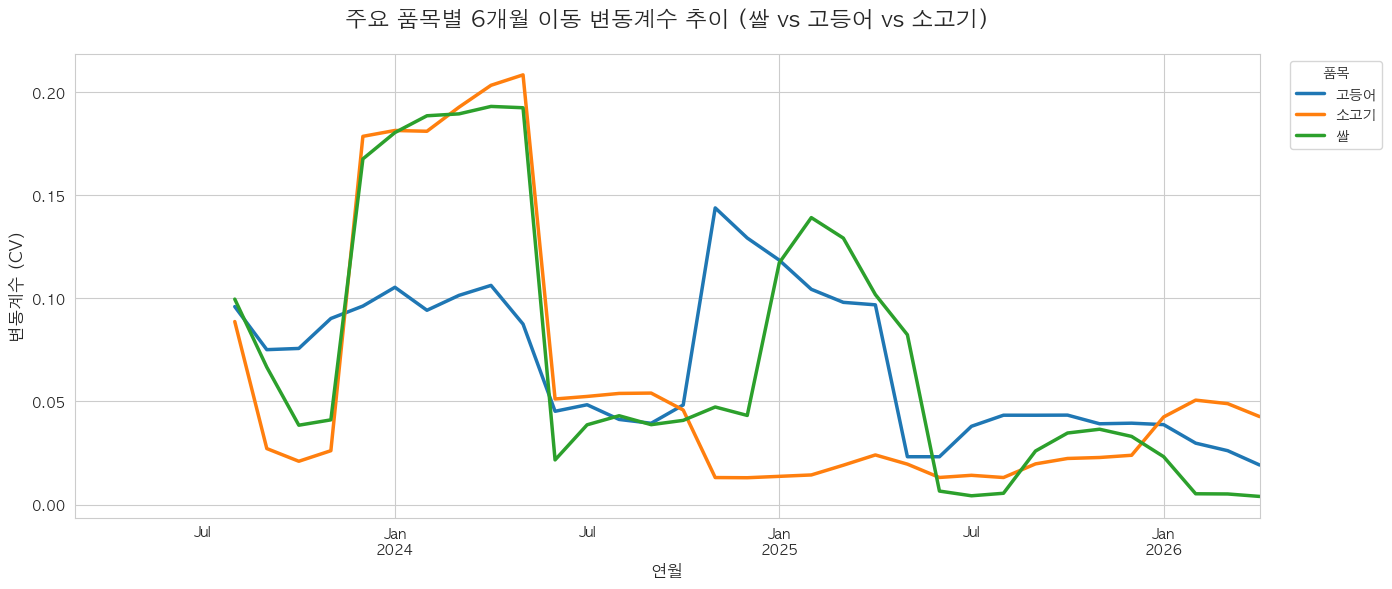

In [ ]:
# 1. 타겟 품목 선정
target_items = ['쌀', '고등어', '소고기']
vol_df = df_clean[df_clean['대표품목명'].isin(target_items)]

# 2. 연월(ym) 및 품목별 평균 가격 피벗
monthly_price = vol_df.groupby(['ym_period', '대표품목명'])['보정가격'].mean().unstack()

# 3. 6개월 이동평균(Mean) 및 이동표준편차(Std) 계산
rolling_mean = monthly_price.rolling(window=6).mean()
rolling_std = monthly_price.rolling(window=6).std()

# 4. 동적 변동계수(Rolling CV) 계산: 값이 클수록 해당 시점에 가격이 불안정함을 의미
rolling_cv = rolling_std / rolling_mean

# 5. 시각화
fig, ax = plt.subplots(figsize=(14, 6))
rolling_cv.plot(ax=ax, linewidth=2.5)

ax.set_title('주요 품목별 6개월 이동 변동계수 추이 (쌀 vs 고등어 vs 소고기)', fontsize=16, pad=20)
ax.set_xlabel('연월', fontsize=12)
ax.set_ylabel('변동계수 (CV)', fontsize=12)
ax.legend(title='품목', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

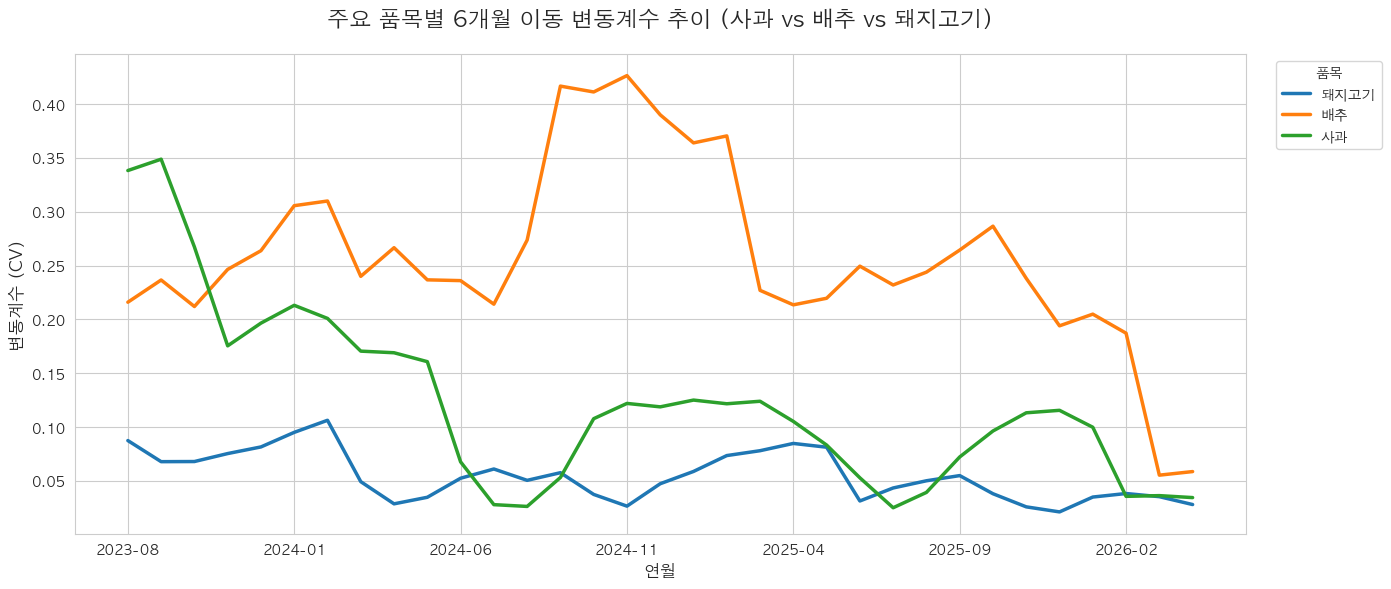

In [ ]:
# 1. 타겟 품목 선정
target_items = ['사과', '배추', '돼지고기']
vol_df = df_clean[df_clean['대표품목명'].isin(target_items)]

# 2. 연월(ym) 및 품목별 평균 가격 피벗
monthly_price = vol_df.groupby(['연월', '대표품목명'])['보정가격'].mean().unstack()

# 3. 6개월 이동평균(Mean) 및 이동표준편차(Std) 계산
rolling_mean = monthly_price.rolling(window=6).mean()
rolling_std = monthly_price.rolling(window=6).std()

# 4. 동적 변동계수(Rolling CV) 계산: 값이 클수록 해당 시점에 가격이 불안정함을 의미
rolling_cv = rolling_std / rolling_mean

# 5. 시각화
fig, ax = plt.subplots(figsize=(14, 6))
rolling_cv.plot(ax=ax, linewidth=2.5)

ax.set_title('주요 품목별 6개월 이동 변동계수 추이 (사과 vs 배추 vs 돼지고기)', fontsize=16, pad=20)
ax.set_xlabel('연월', fontsize=12)
ax.set_ylabel('변동계수 (CV)', fontsize=12)
ax.legend(title='품목', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
print("👀 품목별 결측치 개수 확인:")
print(monthly_price.isna().sum())

👀 품목별 결측치 개수 확인:
대표품목명
돼지고기    0
배추      0
사과      0
dtype: int64


#### YoY & 이동평균

YoY 유효 데이터: 26개월
대분류       농축수산물     생필품
연월                     
2024-03 22.1353 38.2929
2024-04 22.2026 18.8356
2024-05 14.9241 10.3054
2024-06  6.9567 12.3913
2024-07  9.7989  4.4686


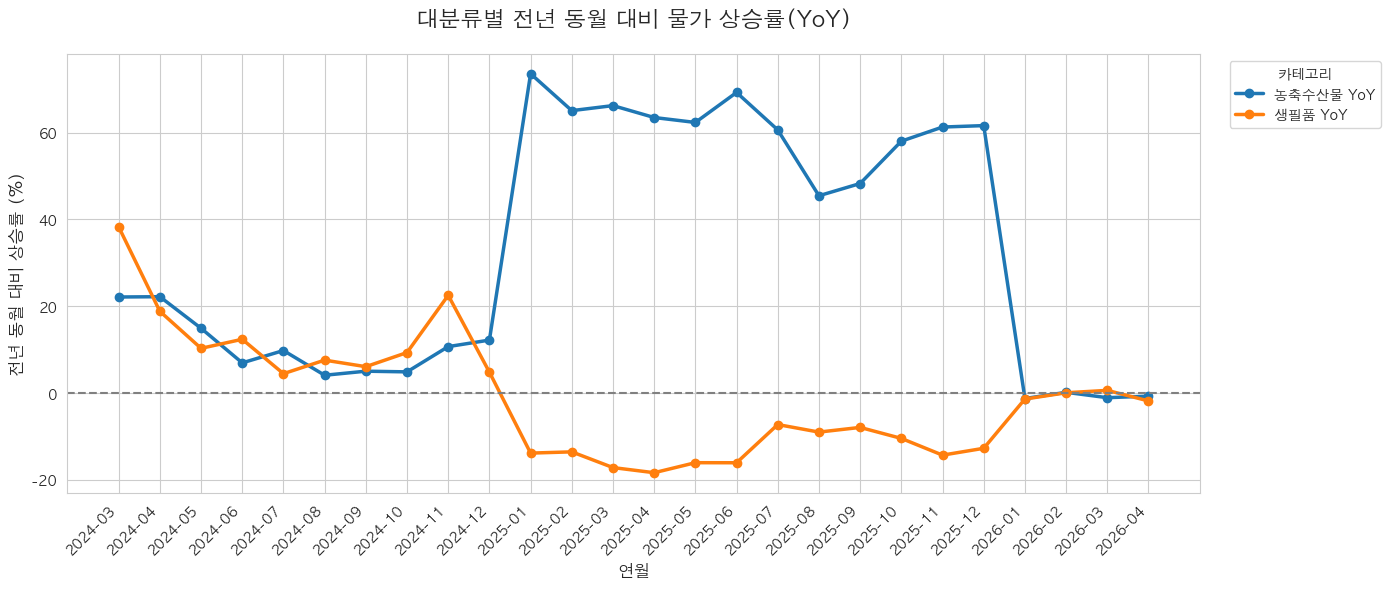

In [ ]:
# 1. 피벗 및 YoY 계산 (동일)
macro_monthly = df_clean.groupby(['연월', '대분류'])['보정가격'].mean().unstack()
monthly_yoy = macro_monthly.pct_change(periods=12) * 100

# 2. ← 핵심 수정: dropna() 전에 target 컬럼만 먼저 선택
target_cats = ['농축수산물', '생필품']
monthly_yoy_clean = monthly_yoy[target_cats].dropna()  # '기타' 등 불필요 컬럼 영향 차단

print(f"YoY 유효 데이터: {len(monthly_yoy_clean)}개월")
print(monthly_yoy_clean.head())

# 3. 시각화 (동일)
fig, ax = plt.subplots(figsize=(14, 6))
for cat in target_cats:
    ax.plot(monthly_yoy_clean.index, monthly_yoy_clean[cat], 
            label=f'{cat} YoY', linewidth=2.5, marker='o')

ax.axhline(0, color='gray', linestyle='--', linewidth=1.5)
ax.set_title('대분류별 전년 동월 대비 물가 상승률(YoY)', fontsize=16, pad=20)
ax.set_xlabel('연월', fontsize=12)
ax.set_ylabel('전년 동월 대비 상승률 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.legend(title='카테고리', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

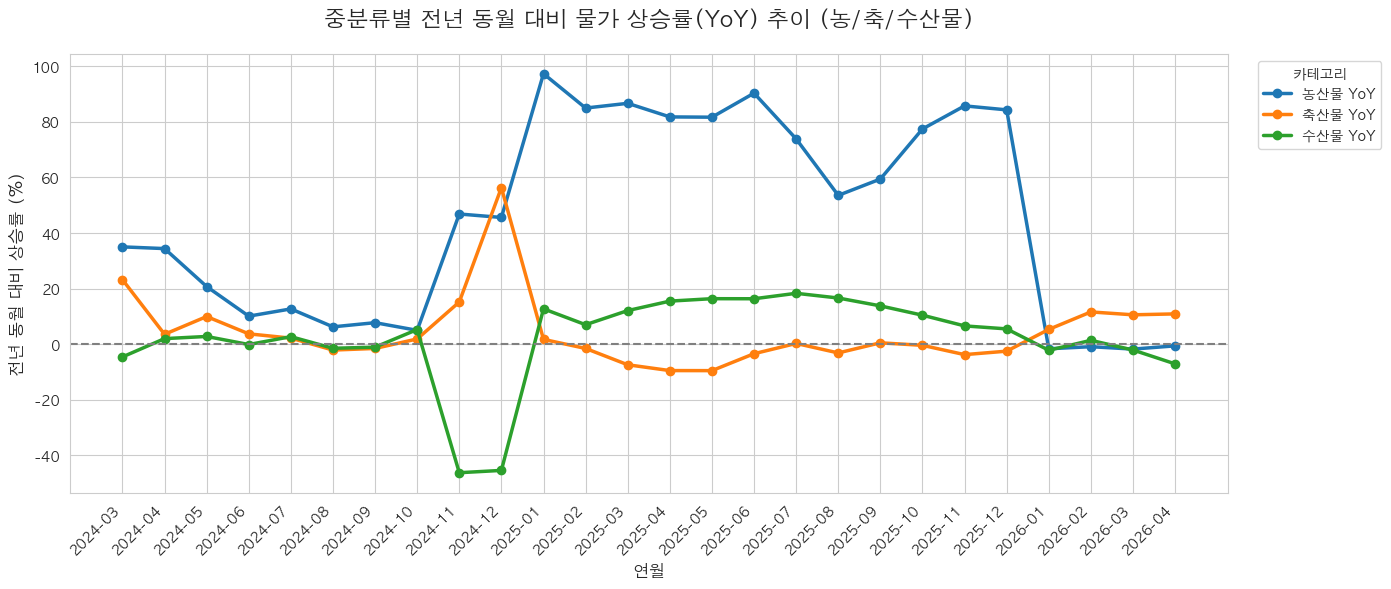

In [ ]:
# 1. 대분류별 연월 평균 가격 피벗
macro_monthly = df_clean.groupby(['연월', '중분류'])['보정가격'].mean().unstack()

# 2. 전년 동월(12개월 전) 대비 증감률(%) 계산
# pct_change(periods=12)를 사용하면 자동으로 1년 전 데이터와 비교해줍니다.
monthly_yoy = macro_monthly.pct_change(periods=12) * 100

# 3. 시각화
target_cats = ['농산물', '축산물', '수산물']
monthly_yoy_clean = monthly_yoy[target_cats].dropna()

fig, ax = plt.subplots(figsize=(14, 6))
for cat in target_cats:
    ax.plot(monthly_yoy_clean.index, monthly_yoy_clean[cat], label=f'{cat} YoY', linewidth=2.5, marker='o')

# 기준선(0%) 추가: 0보다 위에 있으면 전년 대비 물가 상승, 아래면 하락
ax.axhline(0, color='gray', linestyle='--', linewidth=1.5)

ax.set_title('중분류별 전년 동월 대비 물가 상승률(YoY) 추이 (농/축/수산물)', fontsize=16, pad=20)
ax.set_xlabel('연월', fontsize=12)
ax.set_ylabel('전년 동월 대비 상승률 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.legend(title='카테고리', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

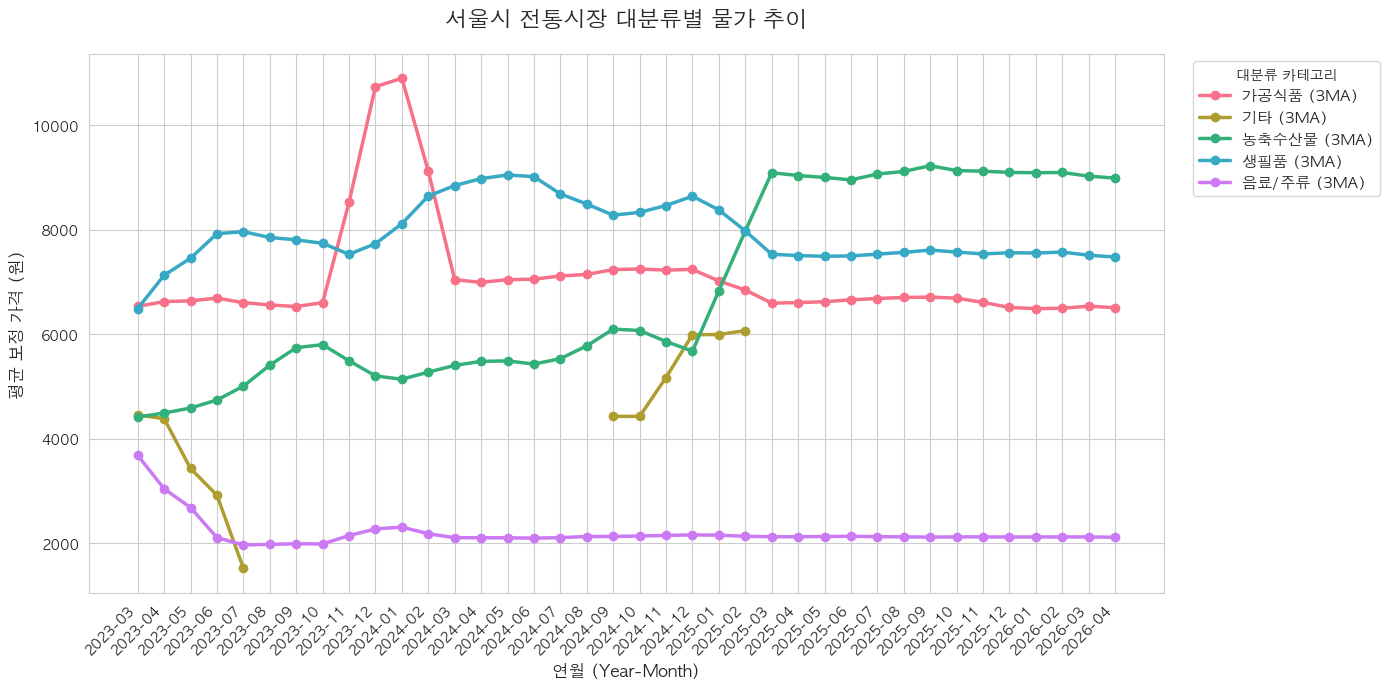

In [ ]:
# ---------------------------------------------------------
# 2. 데이터 집계 및 이동평균(MA) 계산
# ---------------------------------------------------------
# 연월(ym) 및 대분류별 평균 보정 가격 산출
macro_trend = df_clean.groupby(['연월', '대분류'])['보정가격'].mean().reset_index()

# 이동평균 계산을 위해 데이터를 피벗(Pivot) 테이블 형태로 변환
pivot_trend = macro_trend.pivot(index='연월', columns='대분류', values='보정가격')

# 3개월 이동평균선(3MA) 계산 (최소 1개월 데이터부터 계산 시작)
ma_trend = pivot_trend.rolling(window=3, min_periods=1).mean()

# ---------------------------------------------------------
# 3. 시각화: 대분류 트렌드 비교
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

# 카테고리별로 3개월 이동평균선 그리기
colors = sns.color_palette("husl", len(ma_trend.columns)) # 카테고리별 색상 지정

for idx, category in enumerate(ma_trend.columns):
    ax.plot(
        ma_trend.index, 
        ma_trend[category], 
        label=f'{category} (3MA)', 
        linewidth=2.5, 
        marker='o', 
        color=colors[idx]
    )

# 시각화 디테일 설정
ax.set_title('서울시 전통시장 대분류별 물가 추이', fontsize=16, pad=20)
ax.set_xlabel('연월 (Year-Month)', fontsize=12)
ax.set_ylabel('평균 보정 가격 (원)', fontsize=12)

# X축 눈금(연월) 45도 회전하여 겹침 방지
plt.xticks(rotation=45, ha='right')

# 범례를 그래프 바깥(우측)에 배치하여 시야 확보
ax.legend(title='대분류 카테고리', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

# 레이아웃 타이트하게 조정 후 출력
plt.tight_layout()
plt.show()

#### 지역별 양극화

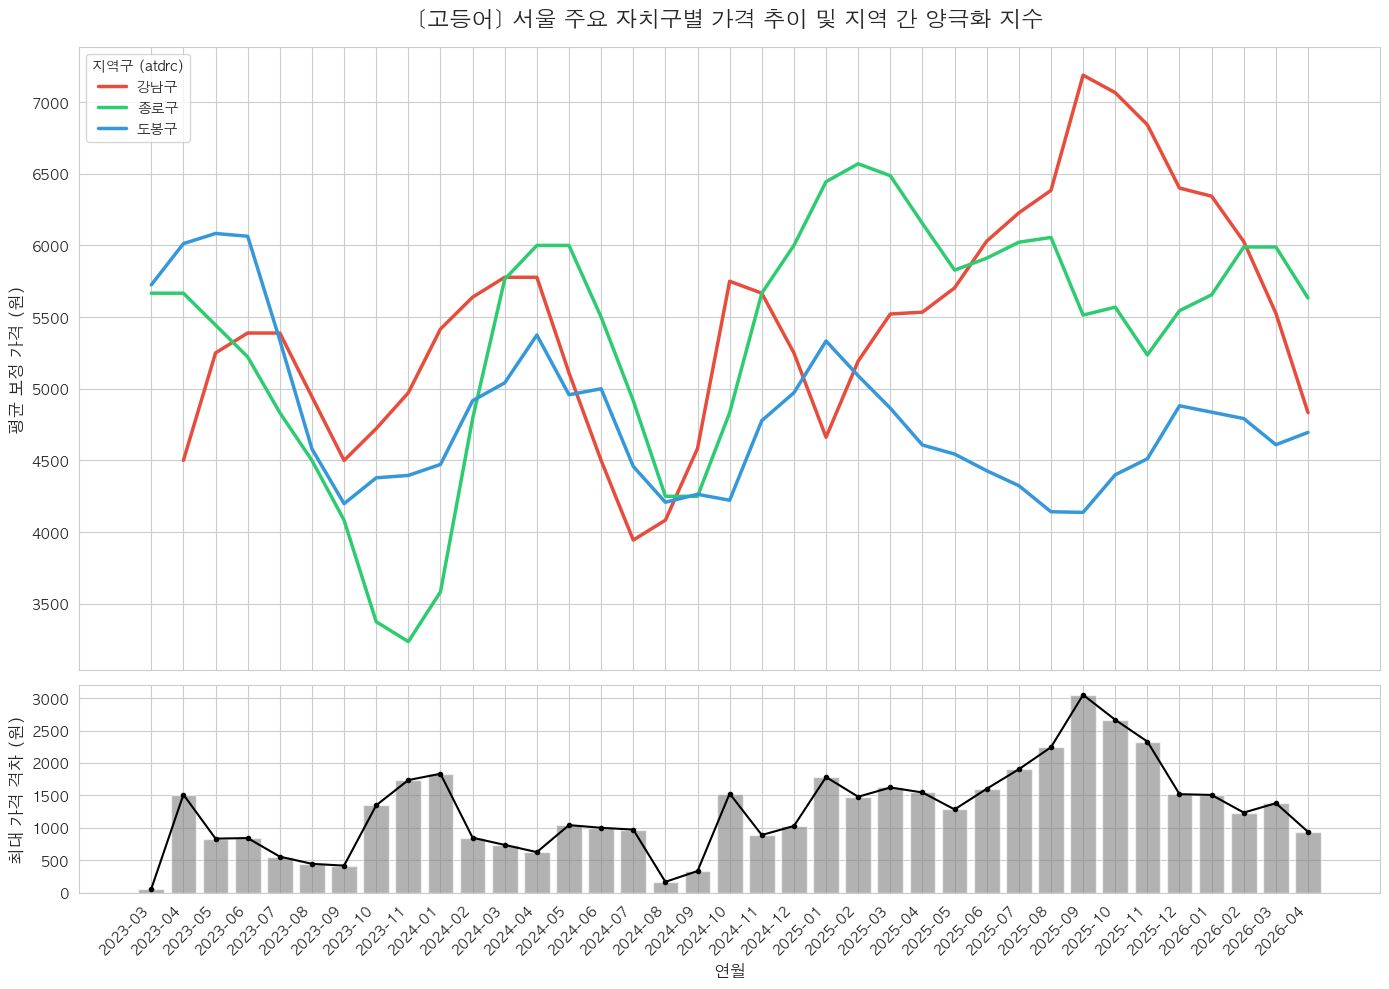

In [ ]:
# 타겟 설정
target_item = '고등어' # 분석할 품목 (예: 사과, 배추, 돼지고기 등)
target_area = ['강남구', '종로구', '도봉구'] # 분석할 지역

# ---------------------------------------------------------
# 3. 데이터 전처리 및 피벗
# ---------------------------------------------------------
# 타겟 품목과 타겟 지역구 데이터만 필터링 (atdrc 칼럼 사용)
spread_df = df_clean[(df_clean['대표품목명'] == target_item) & (df_clean['자치구'].isin(target_area))]

# 연월(ym) 및 지역구(atdrc)별 평균 가격 산출
monthly_area_price = spread_df.groupby(['연월', '자치구'])['보정가격'].mean().unstack()

# 결측치 방어를 위해 선형 보간 (특정 구에 조사 누락이 있을 경우 대비)
monthly_area_price = monthly_area_price.interpolate(method='linear')

# 이동평균(3MA) 적용 (선택 사항: 노이즈를 줄이고 싶다면 활성화)
monthly_area_price_ma = monthly_area_price.rolling(window=3, min_periods=1).mean()

# 최대 가격 격차(Spread) 계산: (가장 비싼 구 - 가장 싼 구)
monthly_spread = monthly_area_price_ma.max(axis=1) - monthly_area_price_ma.min(axis=1)

# ---------------------------------------------------------
# 4. 시각화 (위: 지역별 추이, 아래: 격차 Spread)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# [상단 그래프] 지역구별 가격 추이 선 그래프
colors = ['#e74c3c', '#2ecc71', '#3498db'] # 강남(빨), 종로(초), 도봉(파) 대비
for idx, area in enumerate(target_area):
    if area in monthly_area_price_ma.columns:
        ax1.plot(monthly_area_price_ma.index, monthly_area_price_ma[area], label=area, linewidth=2.5, color=colors[idx])

ax1.set_title(f'[{target_item}] 서울 주요 자치구별 가격 추이 및 지역 간 양극화 지수', fontsize=16, pad=15)
ax1.set_ylabel('평균 보정 가격 (원)', fontsize=12)
ax1.legend(title='지역구 (atdrc)', loc='upper left')

# [하단 그래프] 최대 가격 격차(Spread) 막대 그래프
ax2.bar(monthly_spread.index, monthly_spread.values, color='gray', alpha=0.6)
ax2.plot(monthly_spread.index, monthly_spread.values, color='black', linewidth=1.5, marker='.') # 추세선 추가

ax2.set_ylabel('최대 가격 격차 (원)', fontsize=12)
ax2.set_xlabel('연월', fontsize=12)

# X축 눈금 설정 (하단 그래프 기준)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

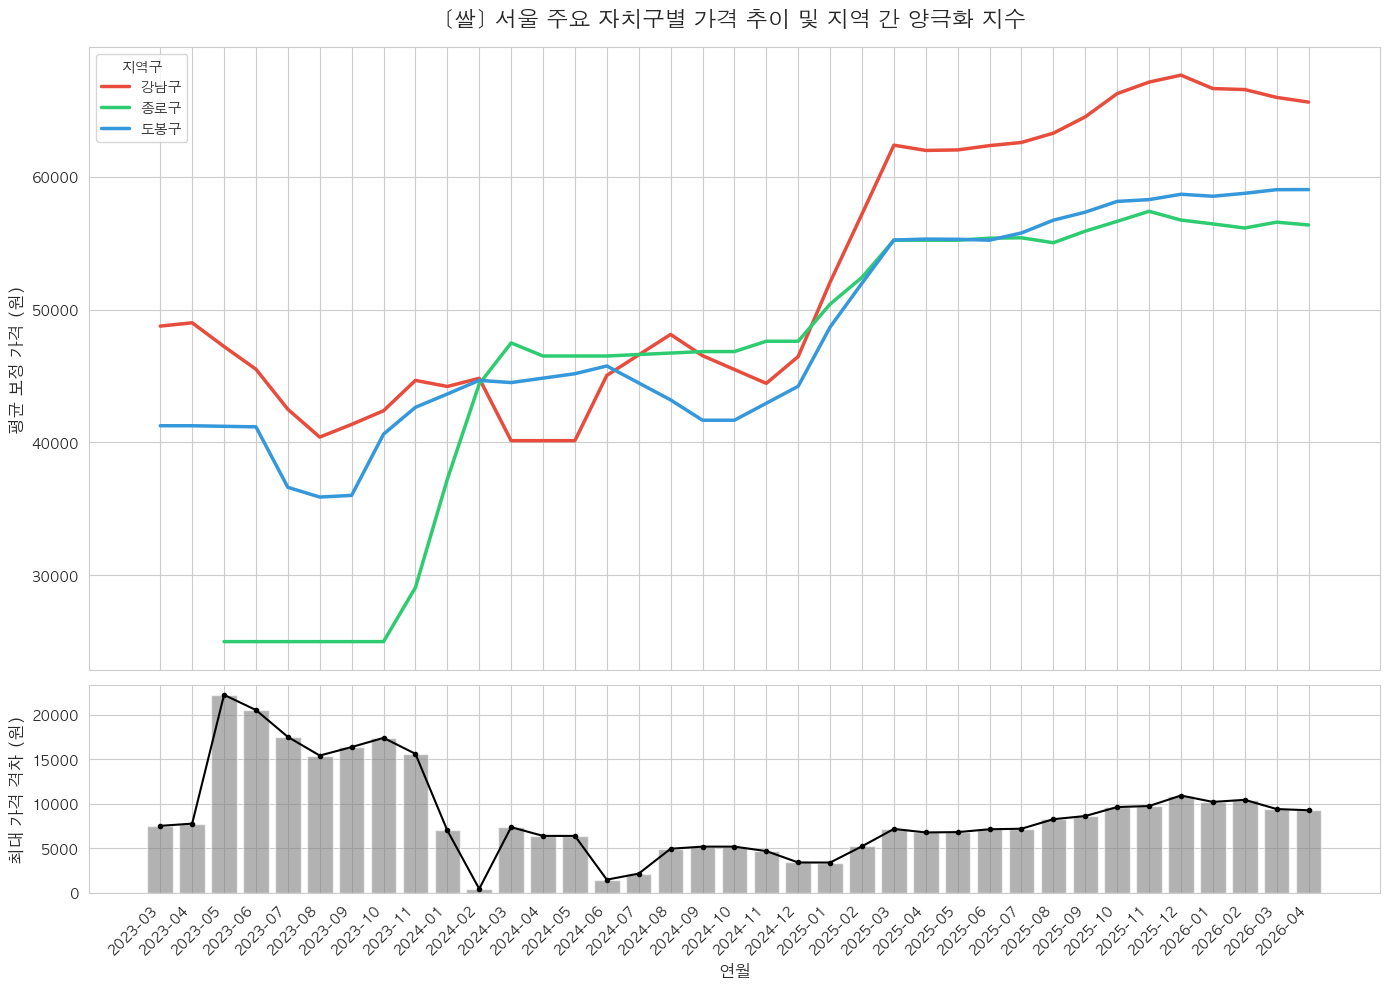

In [ ]:
# 타겟 설정
target_item = '쌀'
target_area = ['강남구', '종로구', '도봉구']

# ---------------------------------------------------------
# 3. 데이터 전처리 및 피벗
# ---------------------------------------------------------
# 타겟 품목과 타겟 지역구 데이터만 필터링 (atdrc 칼럼 사용)
spread_df = df_clean[(df_clean['대표품목명'] == target_item) & (df_clean['자치구'].isin(target_area))]

# 연월(ym) 및 지역구(atdrc)별 평균 가격 산출
monthly_area_price = spread_df.groupby(['연월', '자치구'])['보정가격'].mean().unstack()

# 결측치 방어를 위해 선형 보간 (특정 구에 조사 누락이 있을 경우 대비)
monthly_area_price = monthly_area_price.interpolate(method='linear')

# 이동평균(3MA) 적용 (선택 사항: 노이즈를 줄이고 싶다면 활성화)
monthly_area_price_ma = monthly_area_price.rolling(window=3, min_periods=1).mean()

# 최대 가격 격차(Spread) 계산: (가장 비싼 구 - 가장 싼 구)
monthly_spread = monthly_area_price_ma.max(axis=1) - monthly_area_price_ma.min(axis=1)

# ---------------------------------------------------------
# 4. 시각화 (위: 지역별 추이, 아래: 격차 Spread)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# [상단 그래프] 지역구별 가격 추이 선 그래프
colors = ['#e74c3c', '#2ecc71', '#3498db'] # 강남(빨), 종로(초), 도봉(파) 대비
for idx, area in enumerate(target_area):
    if area in monthly_area_price_ma.columns:
        ax1.plot(monthly_area_price_ma.index, monthly_area_price_ma[area], label=area, linewidth=2.5, color=colors[idx])

ax1.set_title(f'[{target_item}] 서울 주요 자치구별 가격 추이 및 지역 간 양극화 지수', fontsize=16, pad=15)
ax1.set_ylabel('평균 보정 가격 (원)', fontsize=12)
ax1.legend(title='지역구', loc='upper left')

# [하단 그래프] 최대 가격 격차(Spread) 막대 그래프
ax2.bar(monthly_spread.index, monthly_spread.values, color='gray', alpha=0.6)
ax2.plot(monthly_spread.index, monthly_spread.values, color='black', linewidth=1.5, marker='.') # 추세선 추가

ax2.set_ylabel('최대 가격 격차 (원)', fontsize=12)
ax2.set_xlabel('연월', fontsize=12)

# X축 눈금 설정 (하단 그래프 기준)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### XXXXXXXXXXXXXXXX

In [ ]:
# 1. 전체 품목에 대해 월별 평균 가격 피벗테이블 생성
monthly_all = df_clean.groupby(['연월', '대표품목명'])['보정가격'].mean().unstack()

# 2. 품목별로 결측치(NaN) 개수 계산 후 오름차순 정렬
missing_counts = monthly_all.isna().sum().sort_values()

# 3. 결측치 0개 품목만 추출
perfect_items = missing_counts[missing_counts == 0].index.tolist()

print(f"✅ 전체 기간동안 결측치가 없는 완벽한 품목 (총 {len(perfect_items)}개):")
print(perfect_items)

# 결측치 1~2개 품목 확인
good_items = missing_counts[(missing_counts <= 2)&(missing_counts > 0)].index.tolist()
print(f"\n☑️ 결측치가 2개 이하인 우량 품목 (총 {len(good_items)}개):")
print(good_items)

# 결측치 8개 이내 품목
moderate_items = missing_counts[(missing_counts <= 11)&(missing_counts > 2)].index.tolist()
print(f"\n⚠️ 결측치가 11개 이하인 품목 (총 {len(moderate_items)}개):")
print(moderate_items)

✅ 전체 기간동안 결측치가 없는 완벽한 품목 (총 73개):
['빵', '상추', '사이다', '사과', '칫솔', '비누', '컵라면', '부침가루', '버섯', '배추', '배', '케찹', '조기', '바나나', '밀가루', '콜라', '무', '명태', '새우', '콩', '생수', '설탕', '조개', '참기름', '우유', '오징어', '오이', '오렌지', '어묵', '양파', '애호박', '쌀', '식초', '식용유', '시금치', '소주', '치약', '소고기', '치즈', '샴푸', '맥주', '바디워시', '즉석밥', '파프리카', '통조림', '맛김', '깐마늘', '국수', '깻잎', '고춧가루', '고추장', '포도', '단감', '닭고기', '고등어', '고구마', '귤', '당근', '갈치', '마요네즈', '마른멸치', '콩나물', '간장', '라면', '토마토', '굵은소금', '된장', '햄', '돼지고기', '감자', '대파', '계란', '두부']

☑️ 결측치가 2개 이하인 우량 품목 (총 5개):
['수박', '소시지', '참외', '만두', '딸기']

⚠️ 결측치가 11개 이하인 품목 (총 4개):
['복숭아', '세제', '양배추', '브로콜리']


In [ ]:
# 결측치 개수별 품목 수 요약
summary = missing_counts.value_counts().sort_index()
print("--- 결측치 개수별 품목 분포 ---")
print(summary)

--- 결측치 개수별 품목 분포 ---
0     73
1      4
2      1
7      1
10     1
11     2
16     1
22     7
26     1
27     9
28     2
29     1
30     1
32     1
33     1
36     5
37    14
Name: count, dtype: int64


In [ ]:
# 1. 결측치 2개 이하인 51개 우량 품목 리스트 다시 생성
good_items = missing_counts[missing_counts <= 2].index.tolist()

# 2. 원본(df_clean)에서 우량 품목만 필터링한 새로운 데이터프레임 생성
df_ts_master = df_clean[df_clean['대표품목명'].isin(good_items)].copy()

print(f"✅ 시계열/지역별 분석을 위한 마스터 데이터 생성 완료 (품목 수: {df_ts_master['대표품목명'].nunique()}개)")

# 💡 이후 지역별 분석을 할 때, 이 df_ts_master를 사용하여 
# 1~2개의 빈칸만 .interpolate(method='linear') 로 보간

✅ 시계열/지역별 분석을 위한 마스터 데이터 생성 완료 (품목 수: 78개)


In [ ]:
# # 분석 타겟을 '돼지고기'로 잡고, 지역구별로 피벗테이블을 만듭니다.
# target_item = '참외'

# # 1. 타겟 품목만 필터링
# df_target = df_ts_master[df_ts_master['new_std_nm'] == target_item]

# # 2. 연월(ym) 인덱스, 지역구(atdrc) 컬럼으로 피벗 테이블 생성
# # 이렇게 하면 각 지역구별로 시간 순서대로 가격이 쭉 나열됩니다.
# regional_price = df_target.groupby(['ym', 'atdrc'])['adj_price'].mean().unstack()

# # --- 이 시점의 regional_price 형태 (예시) ---
# # atdrc       강남구   도봉구   종로구
# # ym                           
# # 2024-01   20000   15000   18000
# # 2024-02     NaN   15200   18100  <-- 강남구 2월 조사원이 휴가를 가서 누락됨 (결측치)
# # 2024-03   20400   15100   18300
# # ----------------------------------------

# # 3. 선형 보간 (Interpolate) 적용
# # method='linear'는 빈칸의 위(과거)와 아래(미래) 값의 딱 중간값으로 자연스럽게 채워줍니다.
# regional_price_filled = regional_price.interpolate(method='linear')

# # --- 보간 후의 형태 ---
# # 강남구의 2024-02 가격 NaN이 -> (20000 + 20400) / 2 = 20200원으로 채워짐!

##### 결측치 2개 품목

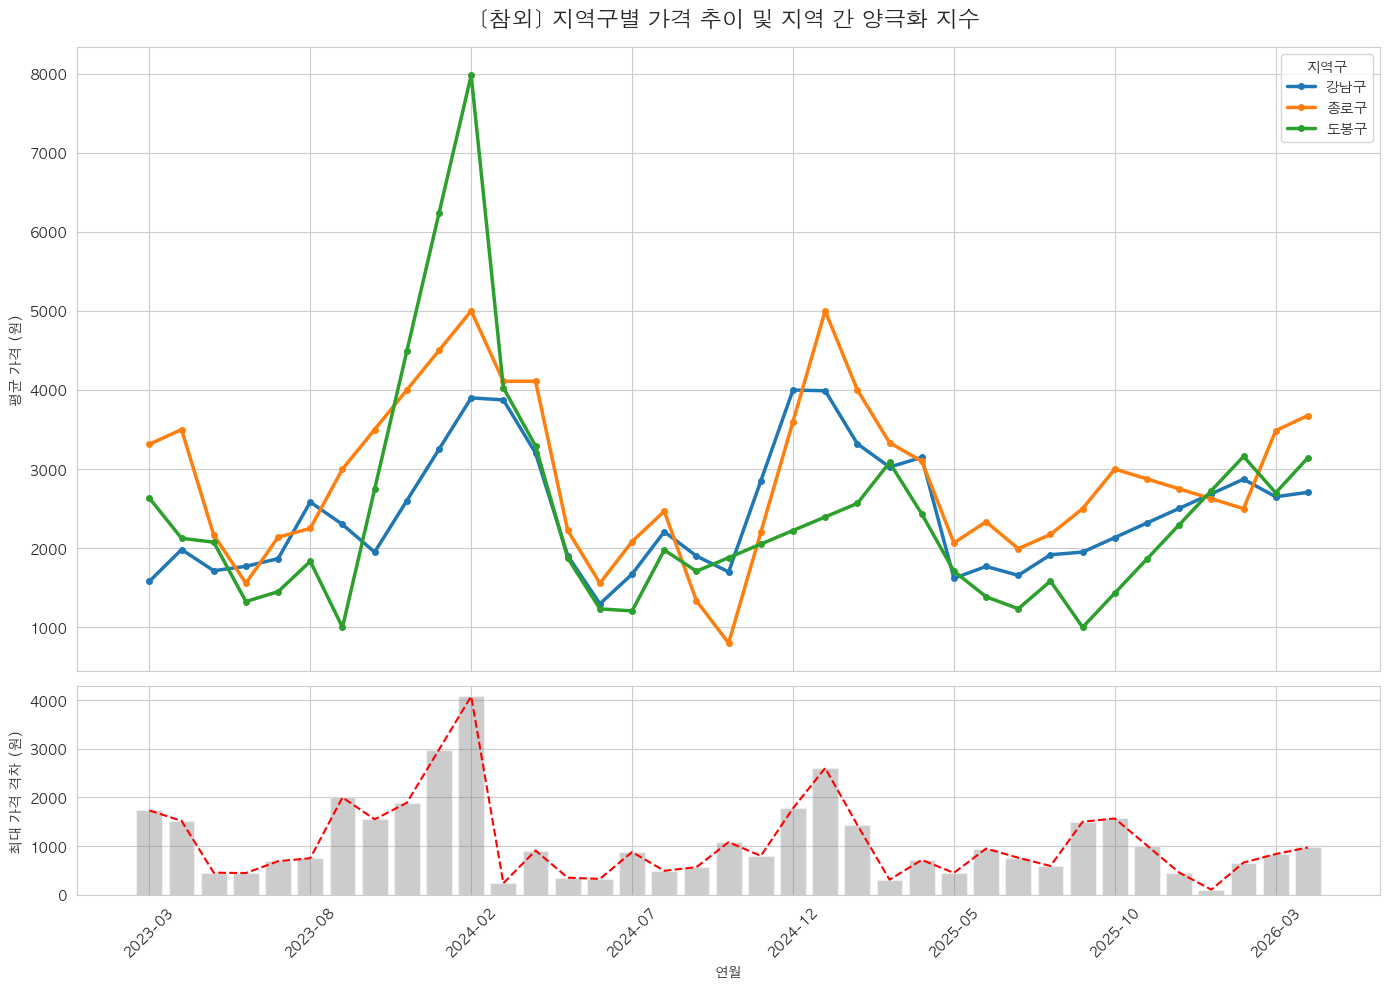

In [ ]:
# 분석 타겟 설정
target_item = '참외' 
target_area = ['강남구', '종로구', '도봉구'] # 비교군 설정

# 데이터 필터링 및 피벗
df_target = df_ts_master[df_ts_master['대표품목명'] == target_item]
regional_price = df_target.groupby(['연월', '자치구'])['보정가격'].mean().unstack()[target_area]

# 지역별 선형 보간 적용
# 지역별로 데이터가 시계열로 정렬된 상태에서 앞뒤 값을 통해 중간을 채웁니다.
regional_price_filled = regional_price.interpolate(method='linear')

# 최대 격차 계산 (가장 비싼 구 - 가장 싼 구)
price_spread = regional_price_filled.max(axis=1) - regional_price_filled.min(axis=1)

# 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# (상단) 지역별 가격 추이
regional_price_filled.plot(ax=ax1, linewidth=2.5, marker='o', markersize=4)
ax1.set_title(f'[{target_item}] 지역구별 가격 추이 및 지역 간 양극화 지수', fontsize=16, pad=15)
ax1.set_ylabel('평균 가격 (원)')
ax1.legend(title='지역구')

# (하단) 가격 격차(Spread)
ax2.bar(price_spread.index, price_spread.values, color='gray', alpha=0.4)
ax2.plot(price_spread.index, price_spread.values, color='red', linewidth=1.5, linestyle='--')
ax2.set_ylabel('최대 가격 격차 (원)')
ax2.set_xlabel('연월')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 결측치 많았던 품목 별도 분석

> 그룹 A: 계절성/기후 분석 품목 (농수산물)
- 과일/채소류: 귤, 단감, 오렌지, 사과, 고구마, 감자, 대파
- 수산물: 오징어, 조기, 갈치

> 그룹 B: 시계열 분석 제외 품목 (가공/공산품)
- 가공식품/생필품: 어묵, 소시지, 치즈, 햄, 즉석밥, 만두, 세제, 칫솔, 샴푸, 바디워시

In [ ]:
# # 그룹 A 품목만 추출
# group_a = ['귤', '단감', '오렌지', '사과', '고구마', '감자', '대파', '오징어', '조기','갈치']
# df_group_a = df_clean[df_clean['new_std_nm'].isin(group_a)]

# # 품목별/월별 결측 여부 시각화 (데이터가 있으면 1, 없으면 0)
# pivot_presence = df_group_a.groupby(['ym', 'new_std_nm'])['adj_price'].mean().unstack().notna().astype(int)

# plt.figure(figsize=(15, 8))
# sns.heatmap(pivot_presence.T, cmap='YlGnBu', cbar=False, linewidths=0.1)
# plt.title('그룹 A 품목별 데이터 존재 여부 (공급 주기 분석)', fontsize=15)
# plt.xlabel('연월')
# plt.ylabel('품목명')
# plt.show()

In [ ]:
# # 1. 전체 데이터에는 23년 5월이 있는지 확인
# print("23년 5월 전체 행 개수:", len(df_clean[df_clean['ym'] == '2023-05']))

# # 2. 그런데 그룹 A 품목 중 23년 5월에 조사된 게 있는지 확인
# check_group_a = df_clean[(df_clean['ym'] == '2023-05') & (df_clean['new_std_nm'].isin(group_a))]
# print("23년 5월 그룹 A 품목 행 개수:", len(check_group_a))

- 그룹 A 품목들은 사실상 2024년 1월부터 데이터 존재한다고 봐야 함

#### 지수화

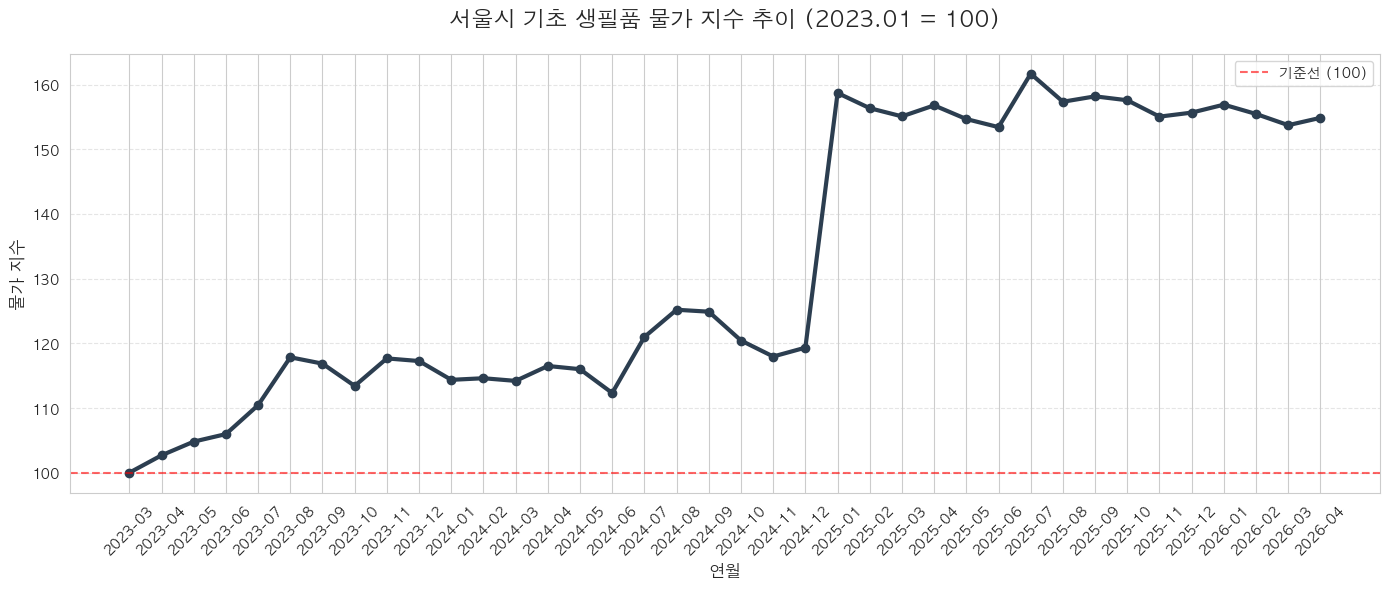

In [ ]:
# 1. 월별 평균 가격 산출
monthly_good_items = df_clean.groupby('연월')['보정가격'].mean()

# 2. 지수화 (2023년 1월 = 100 기준)
base_value = monthly_good_items.iloc[0]
price_index = (monthly_good_items / base_value) * 100

# 3. 시각화
plt.figure(figsize=(14, 6), facecolor='white') # 배경을 흰색으로 설정
ax = plt.gca()
ax.set_facecolor('white')

# 지수 추이 선 그래프 그리기
plt.plot(price_index.index, price_index.values, color='#2c3e50', linewidth=3, marker='o', markersize=6)

# 기준선(100) 추가
plt.axhline(y=100, color='red', linestyle='--', alpha=0.6, label='기준선 (100)')

# 차트 꾸미기
plt.title('서울시 기초 생필품 물가 지수 추이 (2023.01 = 100)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('연월', fontsize=12)
plt.ylabel('물가 지수', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### 특정 품목별 X, Y, Z 지역간 가격 추이

✅ 분석 대상 품목 (총 23개): ['햄', '즉석밥', '기타', '쌀', '상추', '라면', '컵라면', '세제', '위생백', '고등어', '갈치', '비누', '샴푸', '우유', '치즈', '생수', '사이다', '케찹', '설탕', '소주', '맥주', '소고기', '돼지고기']


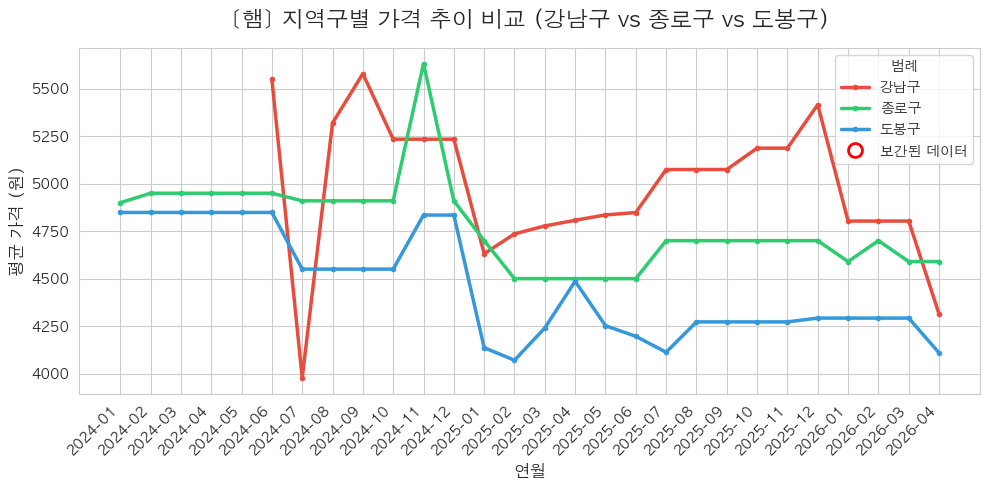

--------------------------------------------------------------------------------


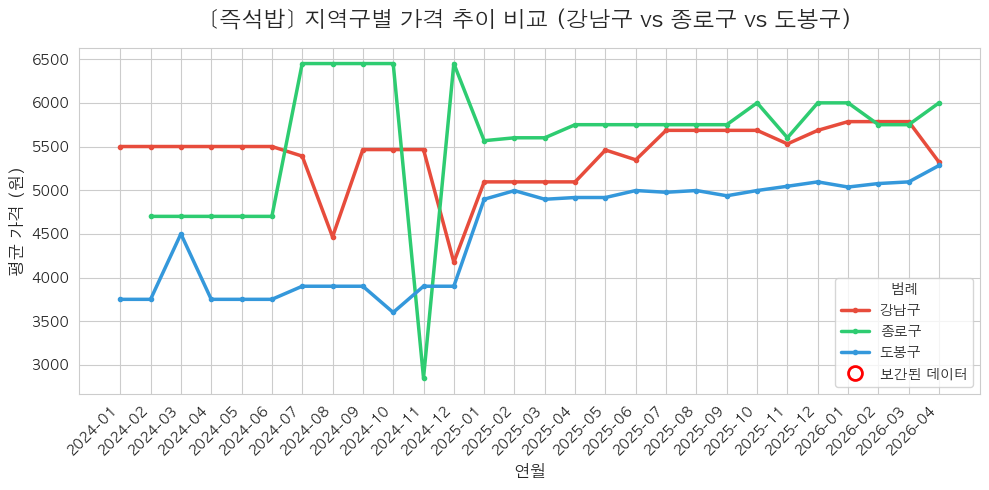

--------------------------------------------------------------------------------


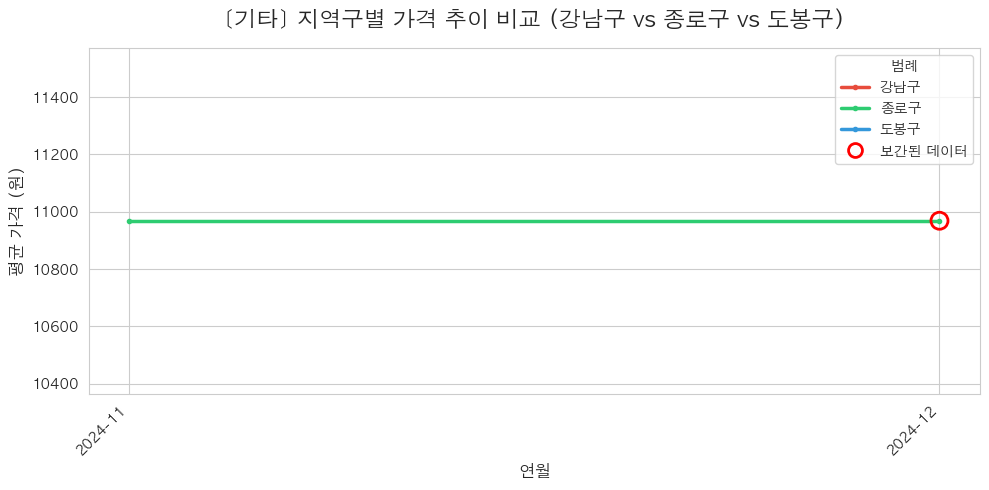

--------------------------------------------------------------------------------


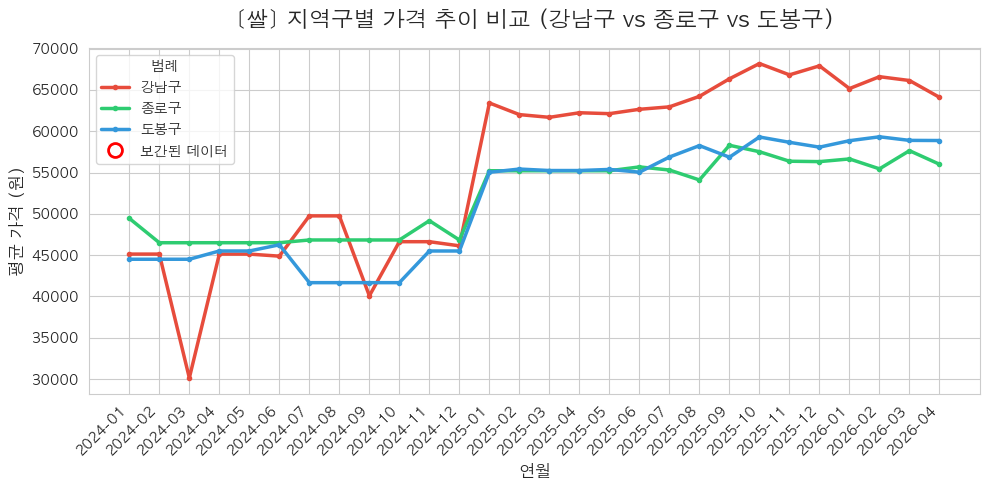

--------------------------------------------------------------------------------


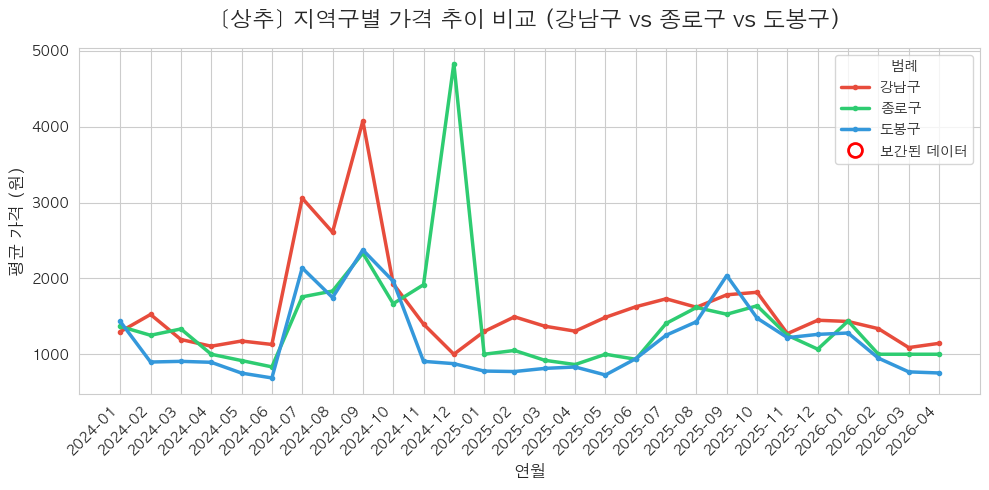

--------------------------------------------------------------------------------


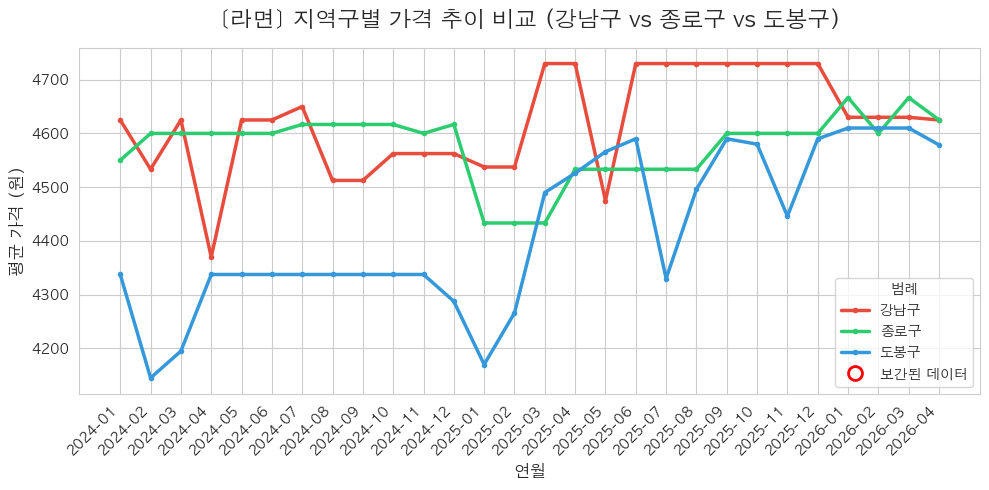

--------------------------------------------------------------------------------


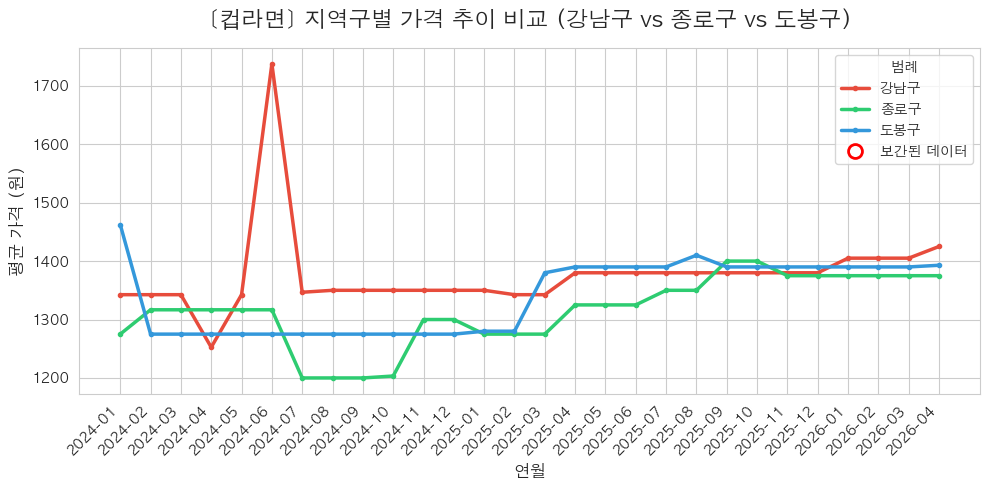

--------------------------------------------------------------------------------


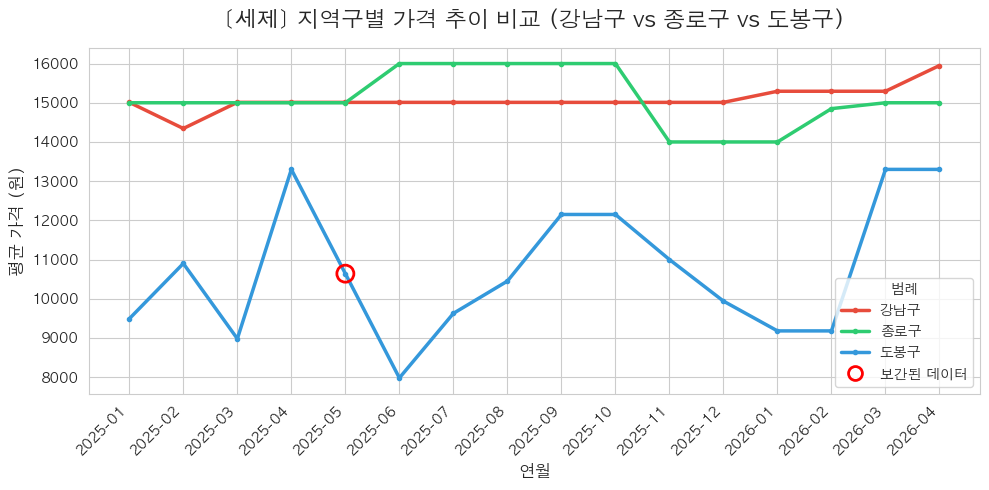

--------------------------------------------------------------------------------


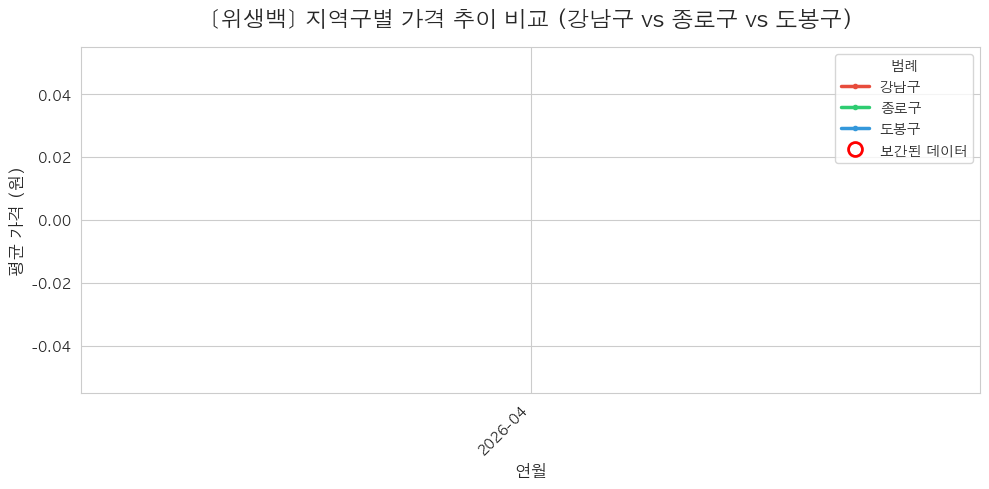

--------------------------------------------------------------------------------


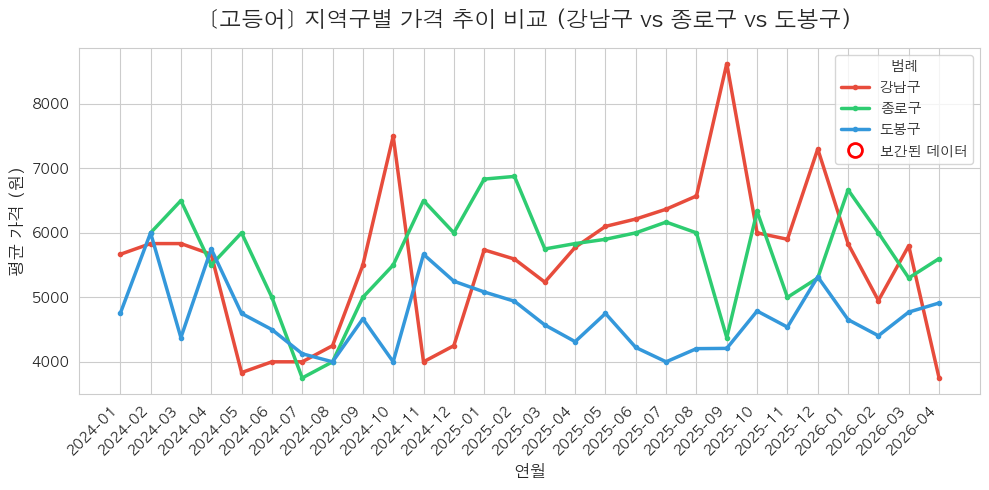

--------------------------------------------------------------------------------


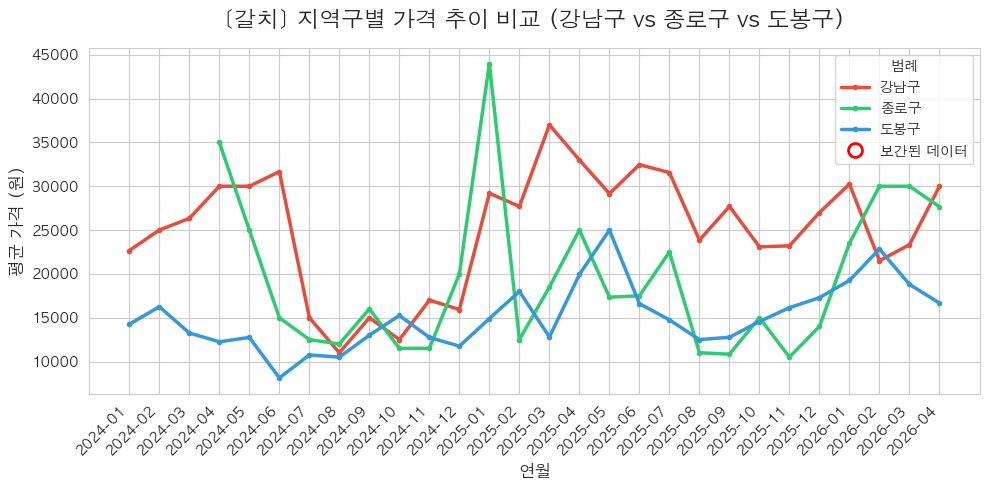

--------------------------------------------------------------------------------


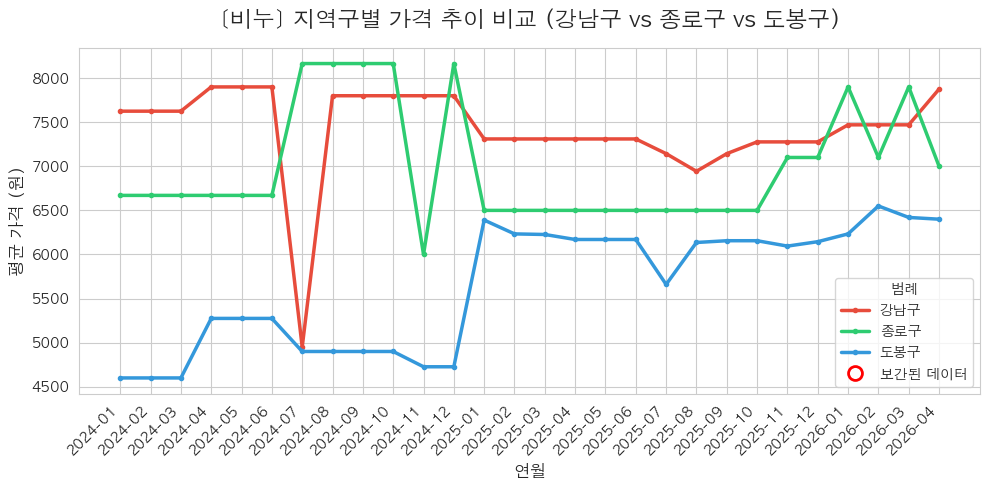

--------------------------------------------------------------------------------


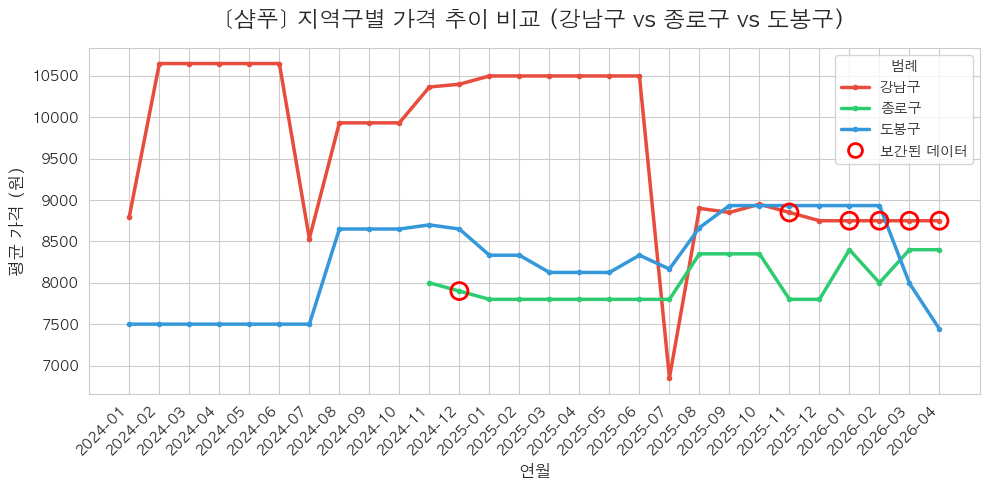

--------------------------------------------------------------------------------


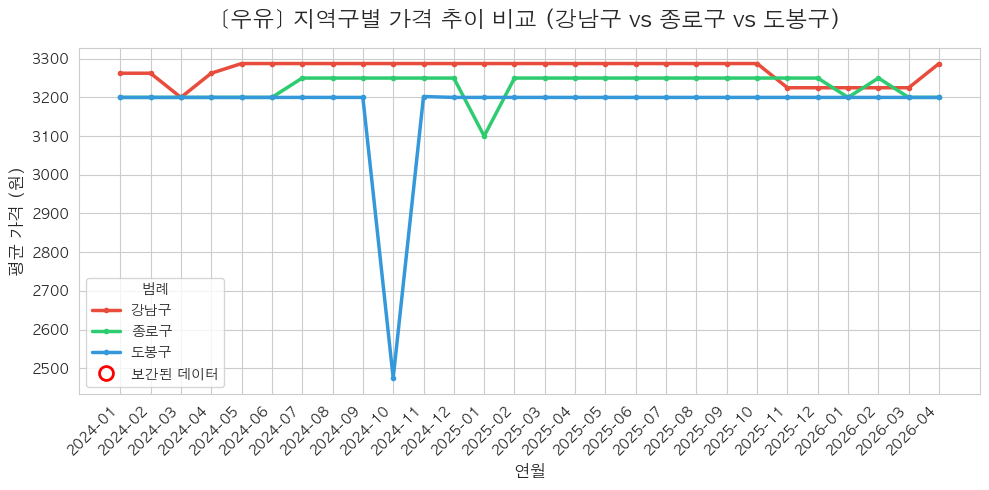

--------------------------------------------------------------------------------


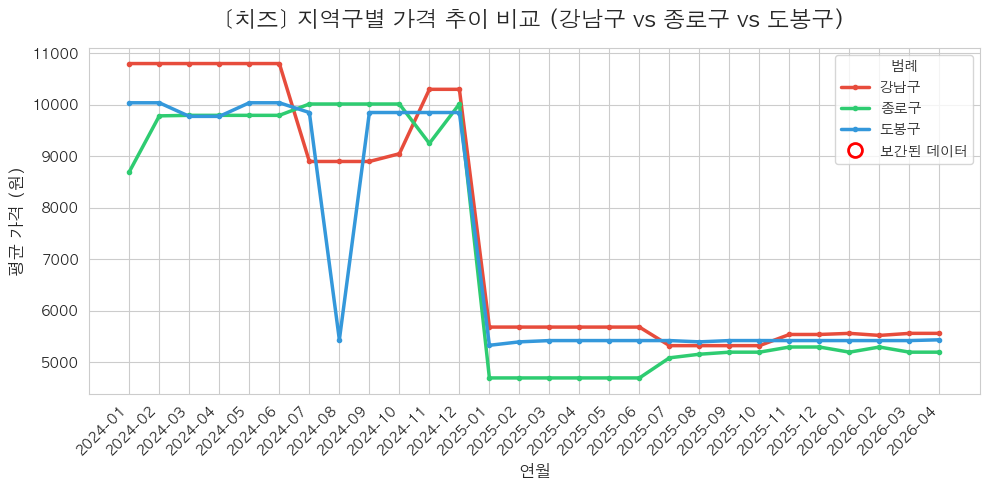

--------------------------------------------------------------------------------


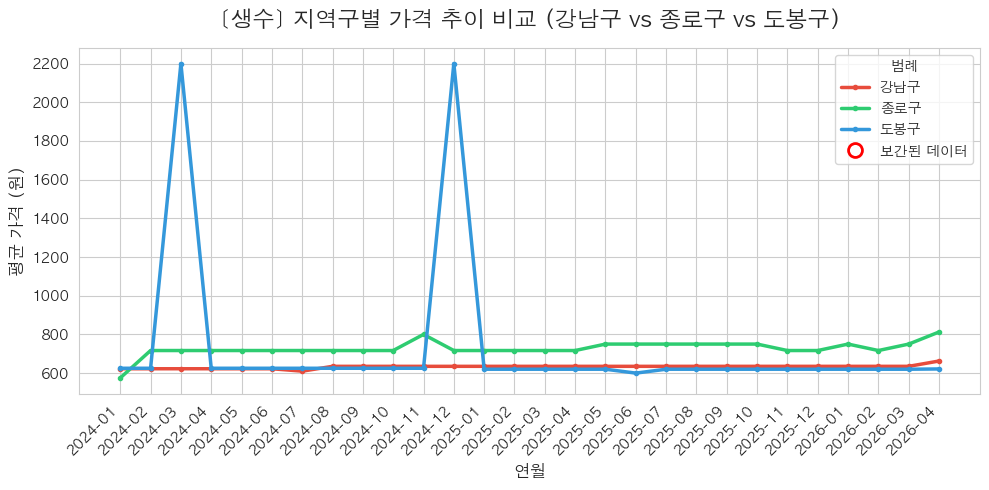

--------------------------------------------------------------------------------


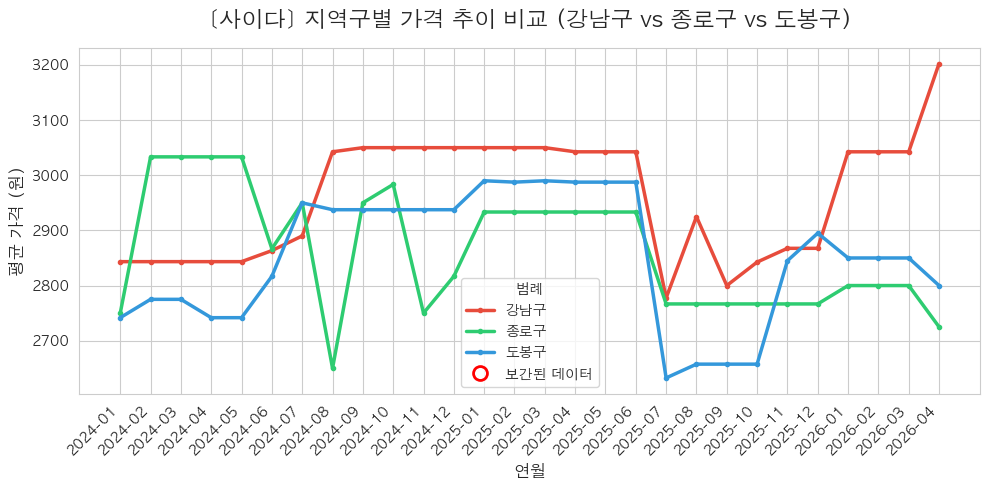

--------------------------------------------------------------------------------


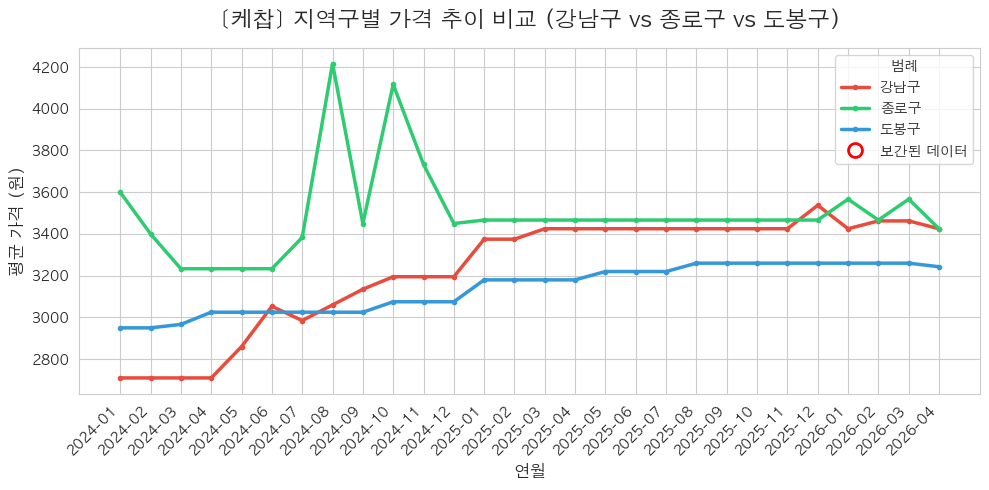

--------------------------------------------------------------------------------


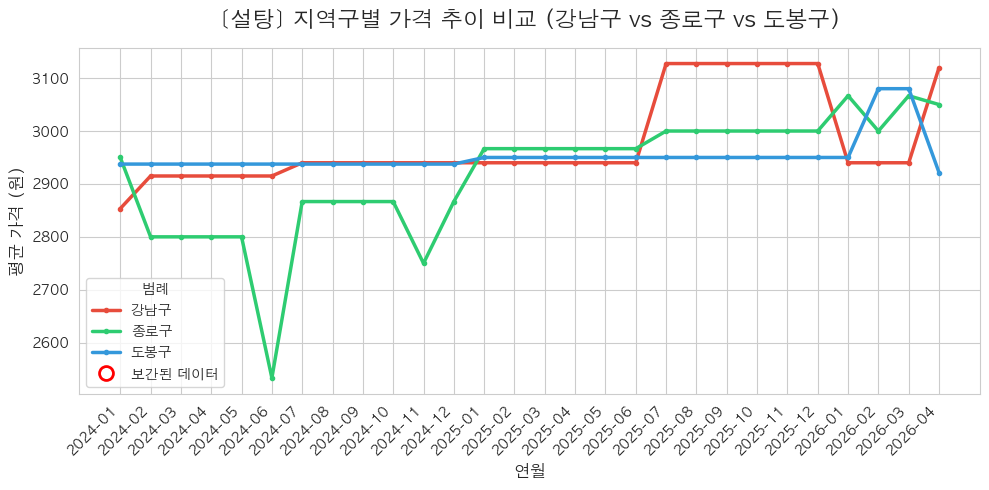

--------------------------------------------------------------------------------


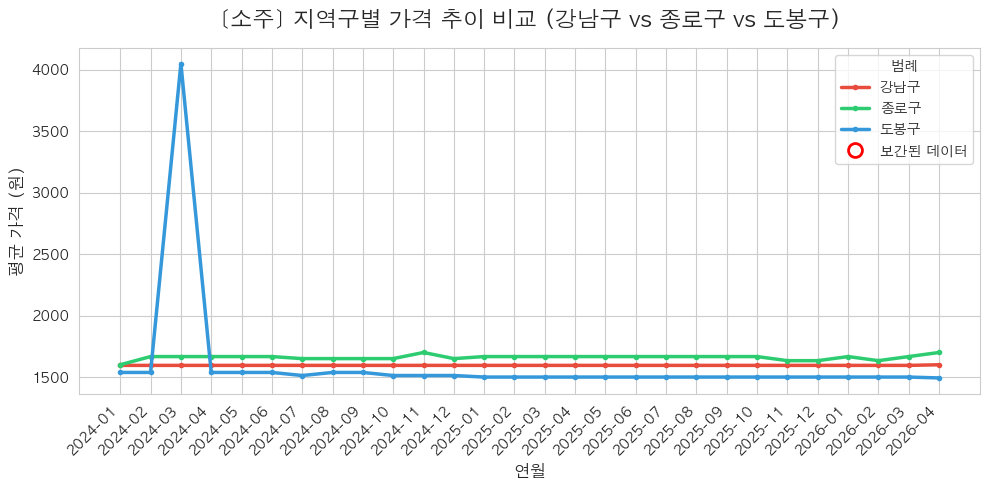

--------------------------------------------------------------------------------


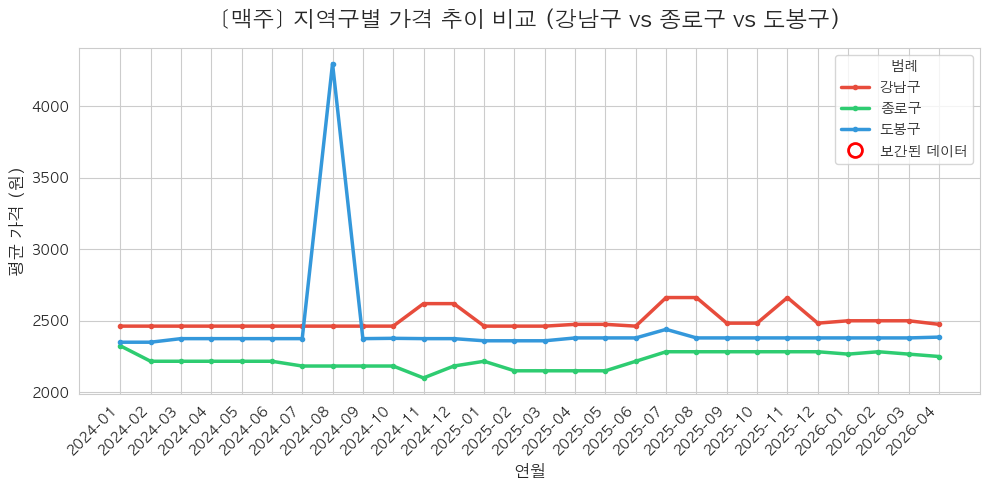

--------------------------------------------------------------------------------


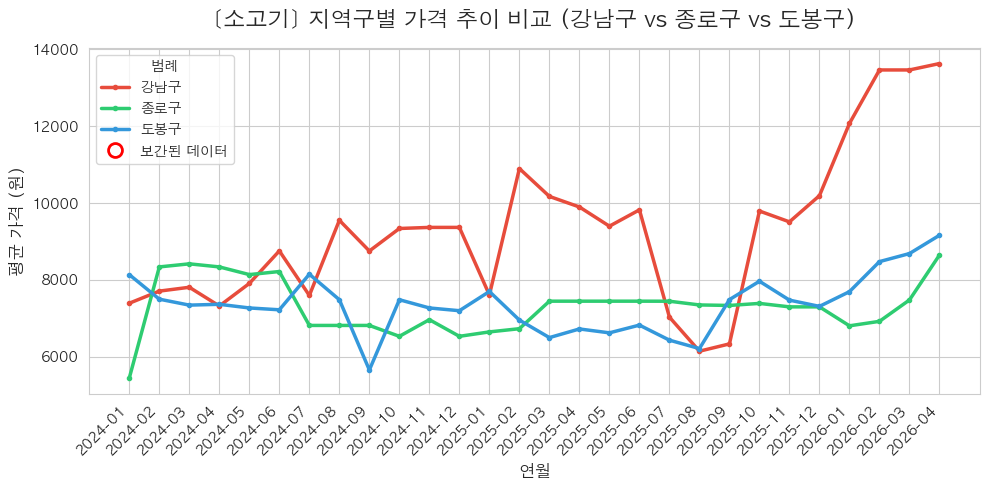

--------------------------------------------------------------------------------


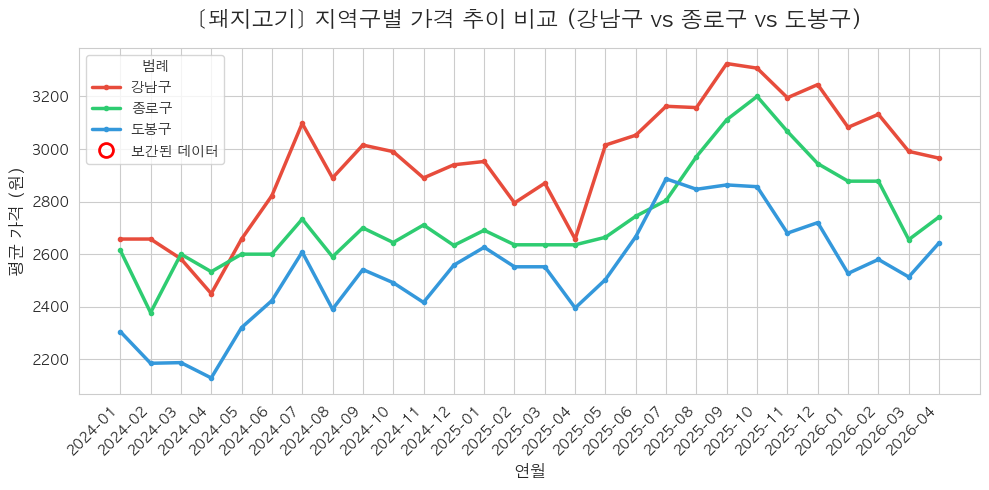

--------------------------------------------------------------------------------


In [ ]:
import matplotlib.lines as mlines # 사용자 정의 범례를 위해 추가

# ---------------------------------------------------------
# 2. 데이터 필터링 및 타겟 설정
# ---------------------------------------------------------
df_recent = df_clean[df_clean['연월'] >= '2024-01'].copy()
category_col = '중분류'
item_col = '대표품목명'
target_area = ['강남구', '종로구', '도봉구']

# ---------------------------------------------------------
# 3. 중분류별 상위 2개 품목 선정
# ---------------------------------------------------------
top_items_df = (
    df_recent.groupby([category_col, item_col])
    .size()
    .reset_index(name='count')
    .sort_values([category_col, 'count'], ascending=[True, False])
    .groupby(category_col)
    .head(2)
)
selected_items = top_items_df[item_col].tolist()
print(f"✅ 분석 대상 품목 (총 {len(selected_items)}개):", selected_items)

# ---------------------------------------------------------
# 4. 개별 Figure 시각화 (보간 지점 하이라이트 추가)
# ---------------------------------------------------------
for item in selected_items:
    item_data = df_recent[df_recent[item_col] == item]
    
    # [그래프 1] 서울시 전체 평균 (생략 - 이전과 동일하게 작성하시면 됩니다)
    
    # -----------------------------------------------------
    # [그래프 2] 타겟 지역구별 가격 추이 (보간 표시 포함)
    # -----------------------------------------------------
    plt.figure(figsize=(10, 5))
    
    # 1) 원본 피벗 테이블 (보간 전)
    regional_mean_raw = item_data.groupby(['연월', '자치구'])['보정가격'].mean().unstack()
    regional_target_raw = regional_mean_raw.reindex(columns=target_area)
    
    # 2) 보간이 적용된 테이블
    regional_target_filled = regional_target_raw.interpolate(method='linear')
    
    # 3) 보간이 일어난 정확한 위치(Mask) 찾기
    # 원본은 NaN인데, 채워진 후에는 NaN이 아닌 곳 == 보간된 곳
    interp_mask = regional_target_raw.isna() & regional_target_filled.notna()
    
    colors = ['#e74c3c', '#2ecc71', '#3498db']
    
    for idx, gu in enumerate(target_area):
        if gu in regional_target_filled.columns:
            # 기본 선 그래프 그리기
            plt.plot(regional_target_filled.index, regional_target_filled[gu], marker='.', 
                     label=gu, linewidth=2.5, color=colors[idx])
            
            # [핵심] 보간된 위치에 하이라이트 마커(빨간 원) 덧그리기
            gu_interp = interp_mask[gu]
            if gu_interp.any(): # 보간된 지점이 하나라도 있다면
                x_interp = regional_target_filled.index[gu_interp]
                y_interp = regional_target_filled.loc[gu_interp, gu]
                
                # s=150(크기), facecolors='none'(속 비우기), edgecolors='red'(빨간 테두리)
                plt.scatter(x_interp, y_interp, s=150, facecolors='none', 
                            edgecolors='red', linewidths=2, zorder=5)

    # 타이틀 (A vs B vs C)
    title_str = " vs ".join(target_area)
    plt.title(f'[{item}] 지역구별 가격 추이 비교 ({title_str})', fontsize=16, pad=15)
    plt.xlabel('연월', fontsize=12)
    plt.ylabel('평균 가격 (원)', fontsize=12)
    
    # 범례 커스터마이징 (지역구 범례 + 보간 표시 범례 합치기)
    handles, labels = plt.gca().get_legend_handles_labels()
    red_circle = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                               markersize=10, markerfacecolor='none', markeredgewidth=2, 
                               label='보간된 데이터')
    handles.append(red_circle)
    
    plt.legend(handles=handles, title='범례', loc='best')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show() 
    
    print("-" * 80)

#### 4/26

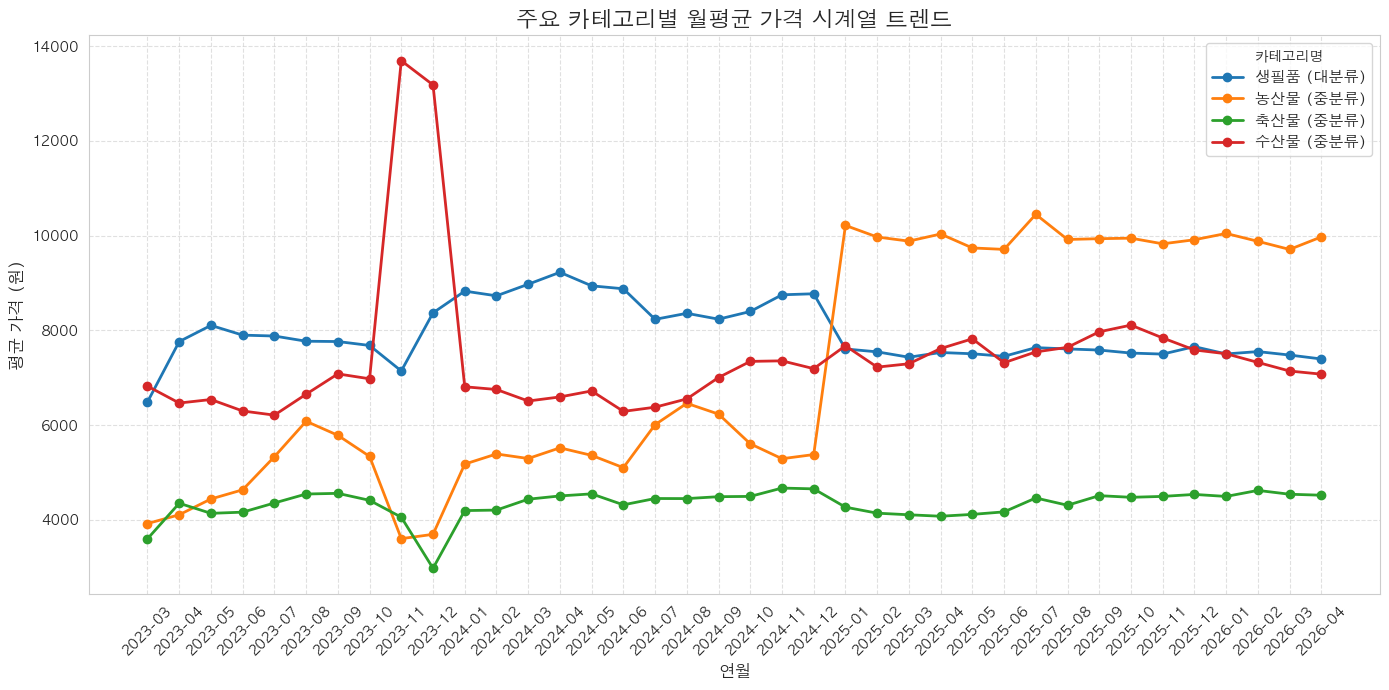

In [ ]:
plt.figure(figsize=(14, 7))

# 1. 반복문을 위한 타겟 그룹 딕셔너리 정의 
# 형식 -> '그래프 라벨명': ('검색할 컬럼명', '찾을 카테고리명')
target_groups = {
    '생필품 (대분류)': ('대분류', '생필품'),
    '농산물 (중분류)': ('중분류', '농산물'),
    '축산물 (중분류)': ('중분류', '축산물'),
    '수산물 (중분류)': ('중분류', '수산물')
}

# 2. 반복문을 돌며 데이터 필터링 및 선형 보간 후 시각화
for label, (col_name, category_name) in target_groups.items():
    # 조건에 맞는 데이터 필터링
    temp_df = df_clean[df_clean[col_name] == category_name]
    
    # 연월 단위로 평균 가격 집계 (detailed_nm 품목들이 모두 모여 평균이 계산됨)
    # (년도-월 컬럼명이 다를 경우 수정해주세요)
    ts_mean = temp_df.groupby('연월')['보정가격'].mean()
    
    # 이전에 처리한 NaN(입력 오류) 등을 선형 보간으로 자연스럽게 연결
    ts_mean_interpolated = ts_mean.interpolate(method='linear')
    
    # 그래프에 라인 추가
    plt.plot(ts_mean_interpolated.index.astype(str), ts_mean_interpolated.values, 
             marker='o', linewidth=2, label=label)

# 3. 그래프 꾸미기
plt.title("주요 카테고리별 월평균 가격 시계열 트렌드", fontsize=16, fontweight='bold')
plt.xlabel("연월", fontsize=12)
plt.ylabel("평균 가격 (원)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='카테고리명', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

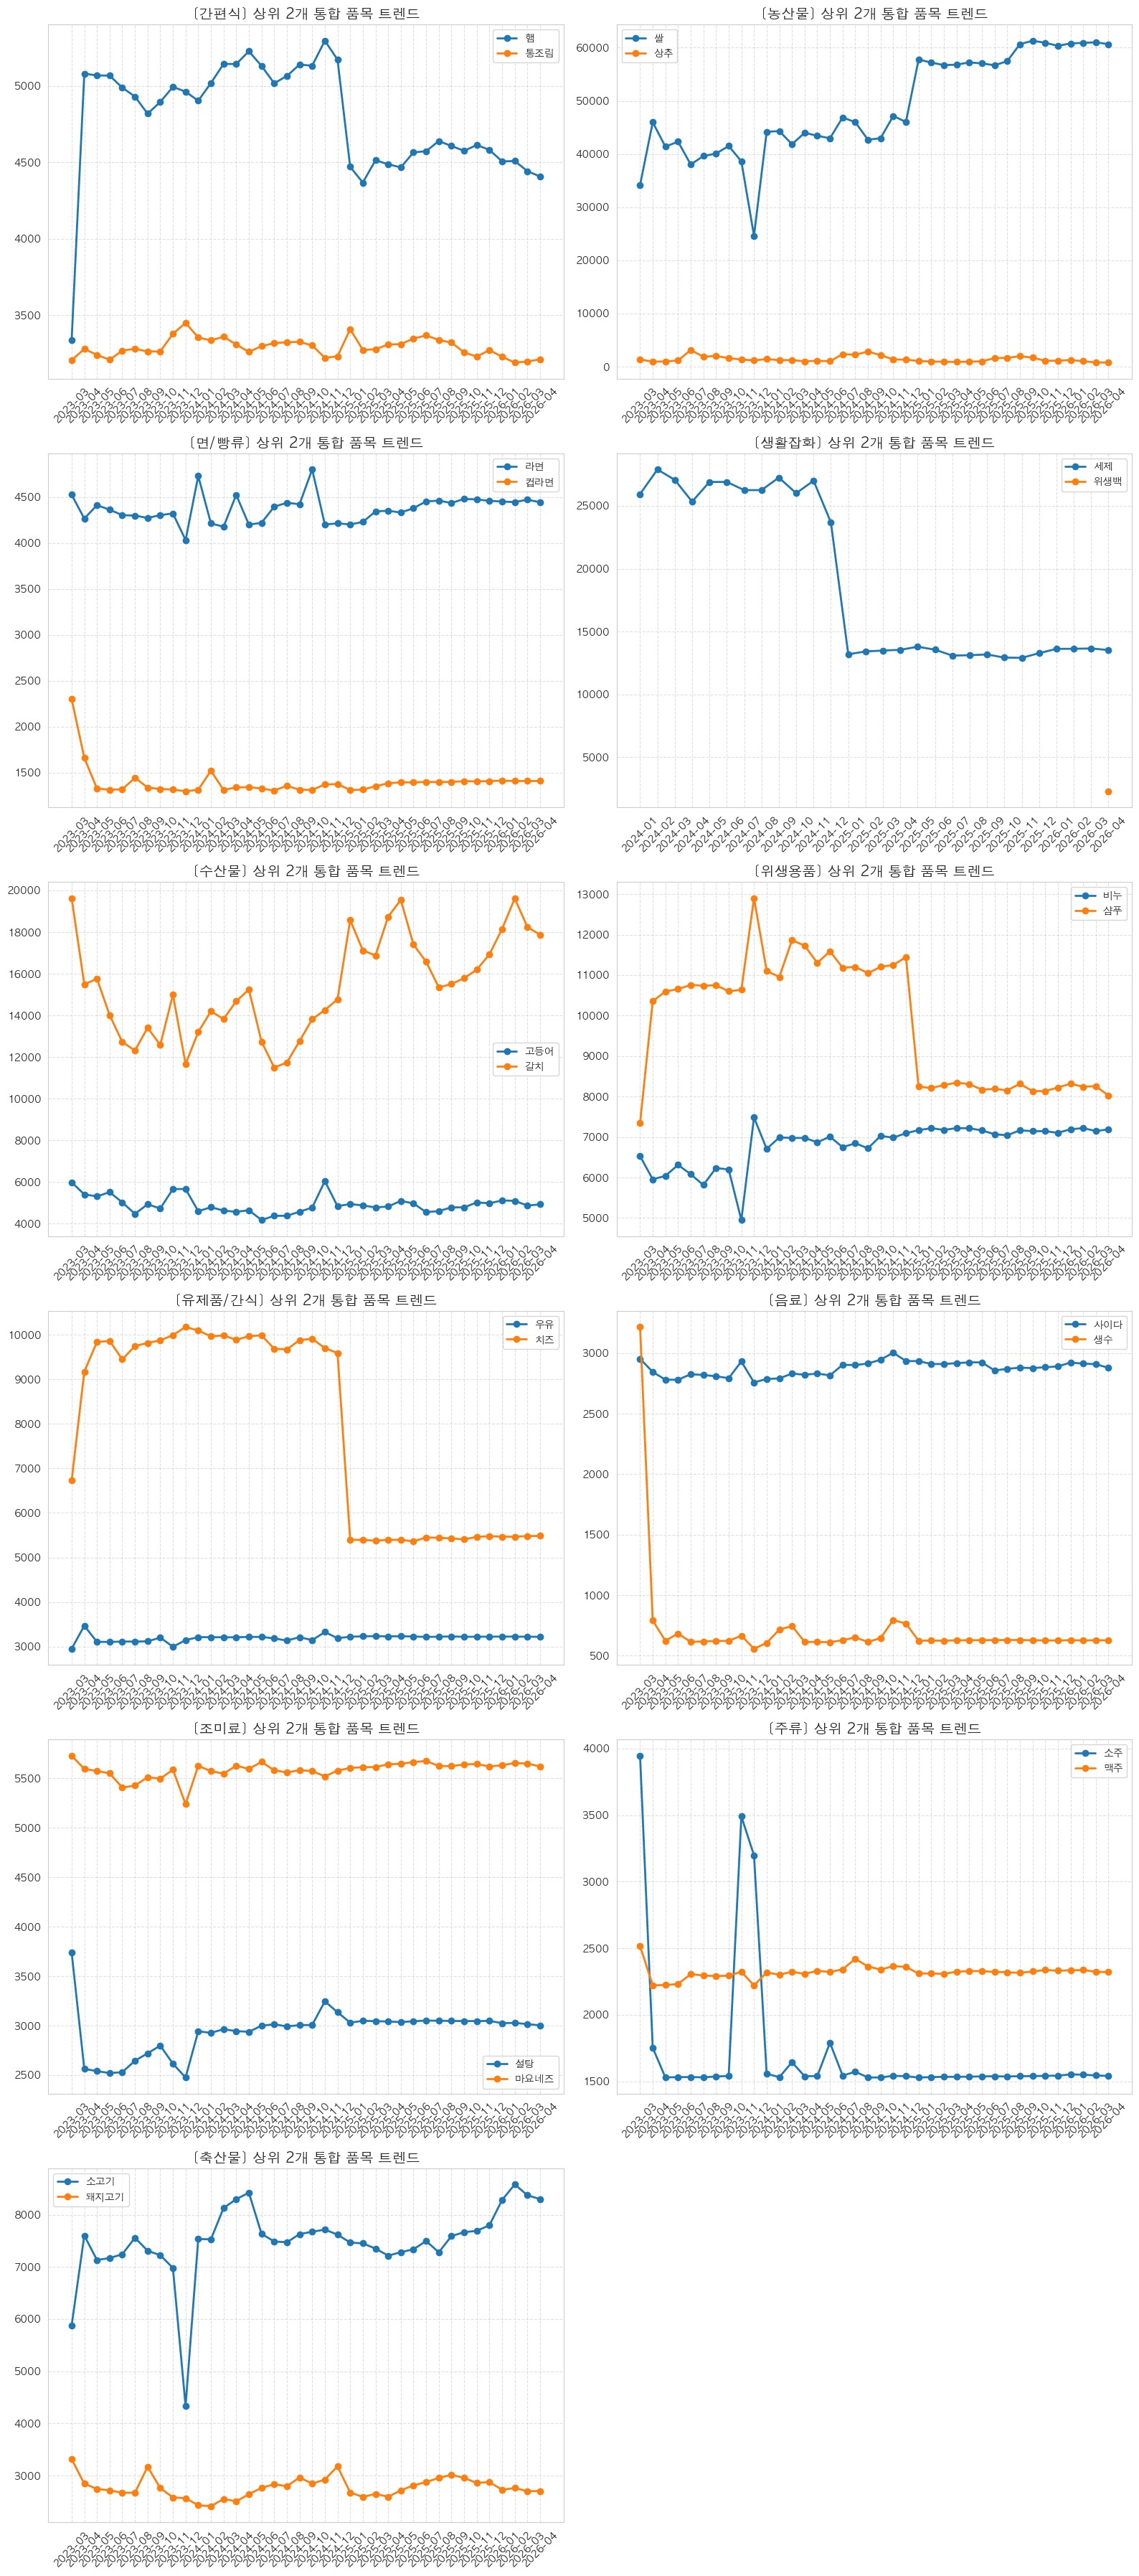

In [ ]:
import math

# 1. detailed_nm에서 '_' 기준 앞부분(기본 품목명)만 추출하여 새로운 임시 컬럼 생성
df_clean['base_item_nm'] = df_clean['상세품목명'].apply(lambda x: str(x).split('_')[0])

# 2. 중분류별 기본 품목명(base_item_nm) 데이터 개수 카운트 및 상위 2개 추출
item_counts = df_clean.groupby(['중분류', 'base_item_nm']).size().reset_index(name='count')
item_counts_sorted = item_counts.sort_values(by=['중분류', 'count'], ascending=[True, False])
top2_per_medium = item_counts_sorted.groupby('중분류').head(2)

# 3. '기타' 분류를 제외한 분석 대상 중분류 리스트 추출
medium_categories = [cat for cat in top2_per_medium['중분류'].unique() if cat != '기타']

# 4. 동적 서브플롯 생성 (가로 2열, 세로는 카테고리 수에 맞게 자동 계산)
cols = 2
rows = math.ceil(len(medium_categories) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten() # 2차원 배열을 1차원으로 펴서 인덱싱하기 쉽게 만듦

# 5. 중분류 단위로 반복문 실행하며 그래프 그리기
for i, category in enumerate(medium_categories):
    ax = axes[i]
    
    # 해당 중분류에서 추출된 상위 2개 품목 리스트 가져오기
    top_items = top2_per_medium[top2_per_medium['중분류'] == category]['base_item_nm'].tolist()
    
    for item in top_items:
        # 해당 중분류 & 해당 품목명 필터링
        temp_df = df_clean[(df_clean['중분류'] == category) & (df_clean['base_item_nm'] == item)]
        
        # 연월 평균 가격 산출 및 보간
        ts_data = temp_df.groupby('연월')['보정가격'].mean().interpolate(method='linear')
        
        # 각 서브플롯에 그리기
        ax.plot(ts_data.index.astype(str), ts_data.values, marker='o', linewidth=2, label=item)
    
    # 서브플롯 개별 꾸미기
    ax.set_title(f"[{category}] 상위 2개 통합 품목 트렌드", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# 6. 만약 빈 서브플롯 공간이 남는다면 숨김 처리
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# 목적을 다한 임시 컬럼 삭제
df_clean = df_clean.drop(columns=['base_item_nm'])

plt.tight_layout()
plt.show()

- 25개 지역구 각각의 특정 품목 시계열 차트

KeyboardInterrupt: 

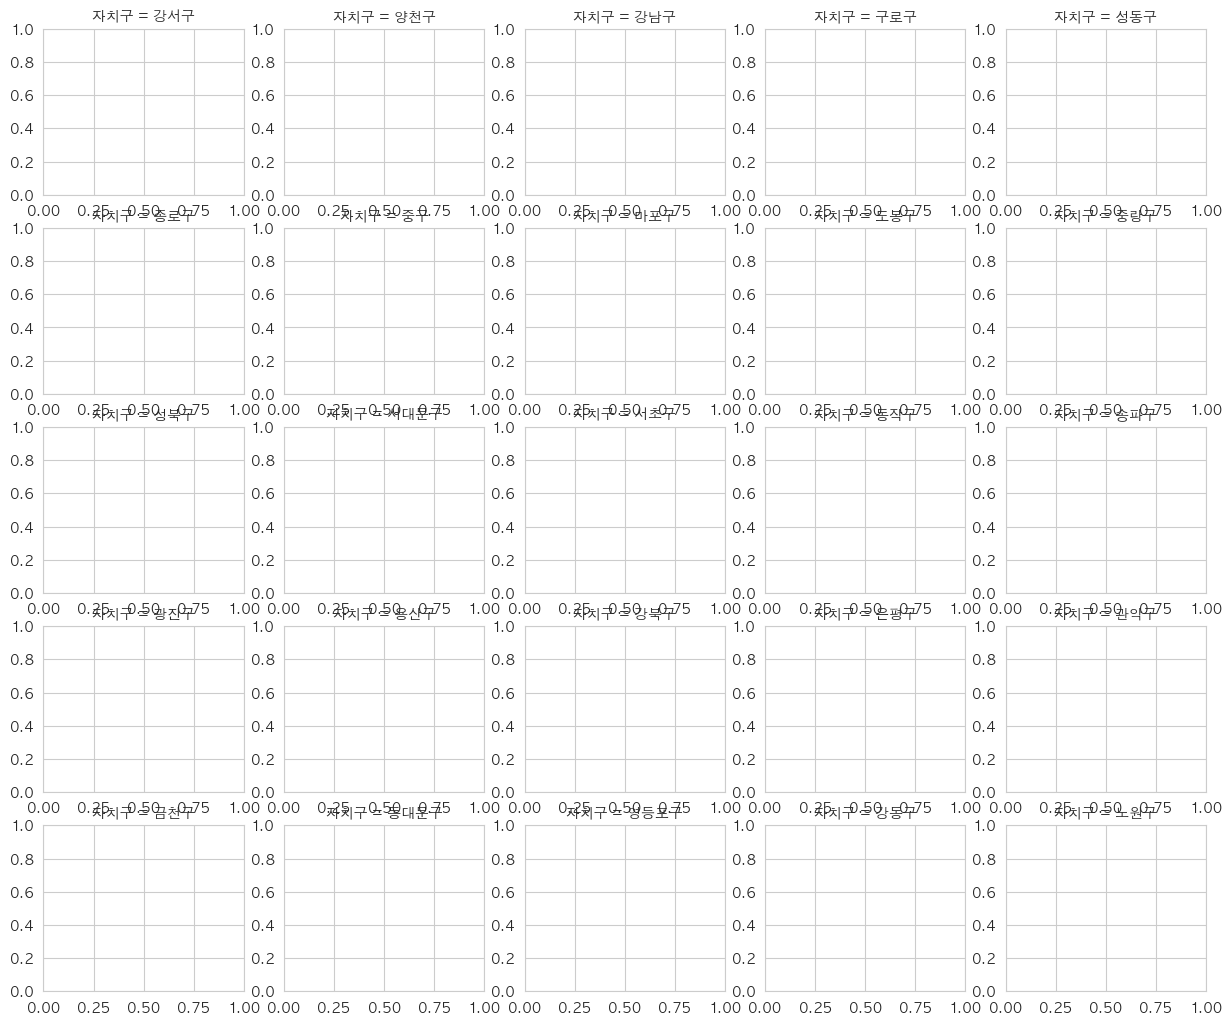

In [ ]:
# 2. 타겟 품목 필터링
target_item = '돼지고기'
df_target = df_clean[df_clean['상세품목명'] == target_item]

# 3. FacetGrid를 이용한 5x5 스몰 멀티플 차트 생성
# col_wrap=5를 주어 한 줄에 5개씩 5줄(25개 지역구)로 자동 줄바꿈
g = sns.FacetGrid(df_target, col="자치구", col_wrap=5, height=2.5, aspect=1.2)

# 4. 각 그리드에 라인 차트 매핑
g.map(sns.lineplot, "연월", "보정가격", marker="o", color="coral")

# 5. 축 레이블 및 제목 정리
g.set_axis_labels("", "가격(원)")
g.set_titles(col_template="{col_name}") # 지역구 이름만 깔끔하게 표시
g.fig.suptitle(f"[{target_item}] 25개 지역구별 가격 시계열 비교", y=1.02, fontsize=16, fontweight='bold')

# 6. x축 날짜 글씨가 겹치지 않게 회전
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()

- 지역 * 품목 * 시계열 가격변동 히트맵

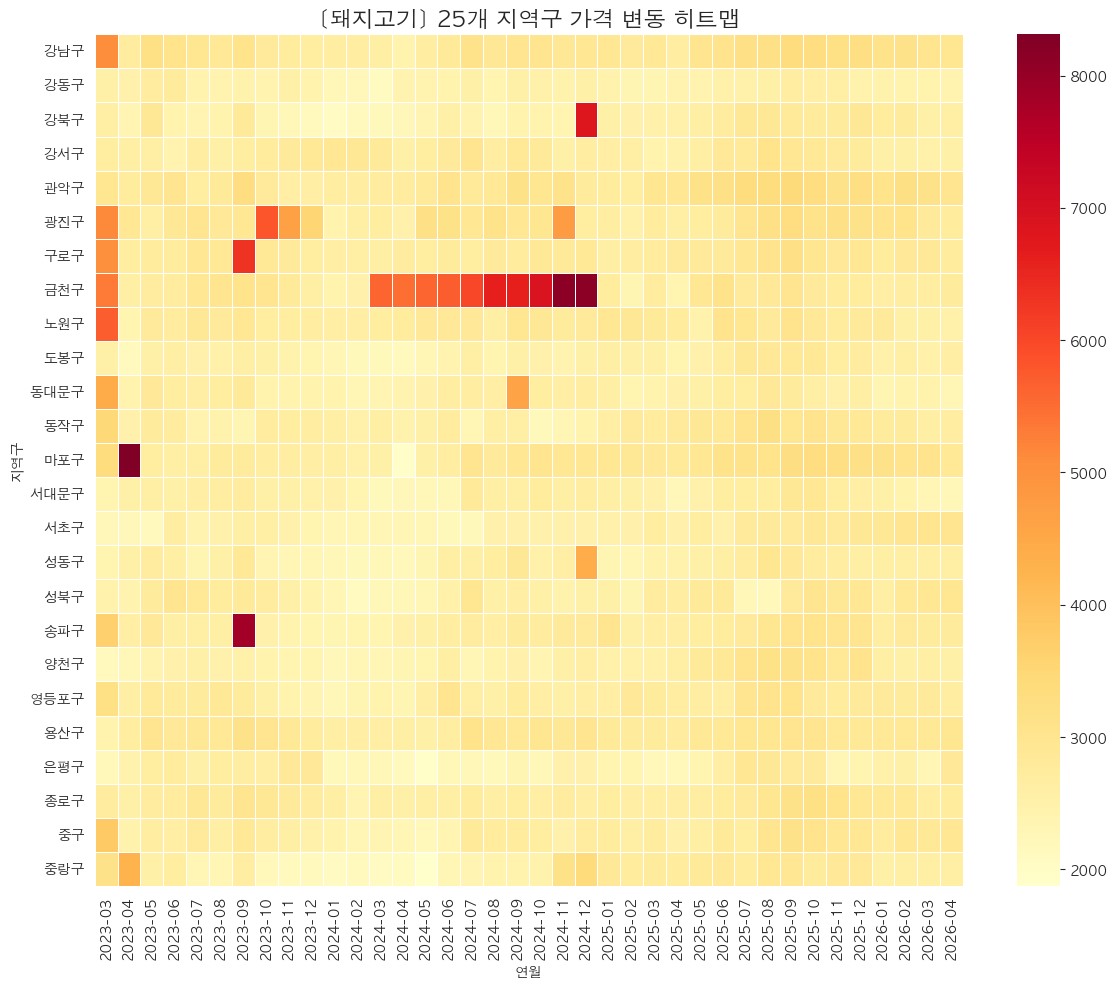

In [ ]:
# 1. 히트맵을 위한 피벗 테이블 생성 (행: 지역구, 열: 년도-월, 값: 가격)
heatmap_data = df_target.pivot_table(index='자치구', columns='연월', values='보정가격', aggfunc='mean')

# 빈 값은 선형 보간으로 채우기 (행/열 방향 고려)
heatmap_data = heatmap_data.interpolate(axis=1).bfill(axis=1)

# 2. 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, linewidths=.5) # YlOrRd: 노랑-주황-빨강 (비쌀수록 붉은색)

plt.title(f"[{target_item}] 25개 지역구 가격 변동 히트맵", fontsize=16, fontweight='bold')
plt.ylabel("지역구")
plt.xlabel("연월")
plt.tight_layout()
plt.show()

- 인터랙티브 차트

In [ ]:
import plotly.express as px

# 1. 분석할 특정 품목 하나를 먼저 고정 (예: 감자)
# 전체 품목을 한 번에 다 넣으면 너무 무거워지므로, 드롭다운으로 전환하거나 품목별로 차트를 만듭니다.
target_item = '돼지고기'
df_target = df_clean[df_clean['상세품목명'] == target_item]

# 2. Plotly 시계열 라인 차트 생성
# color='지역구'를 설정하면 우측에 범례가 생기며, 범례를 클릭하여 특정 지역구를 켜고 끌 수 있습니다.
fig = px.line(df_target, 
              x='연월', 
              y='보정가격', 
              color='자치구', 
              title=f"서울시 25개 지역구 [{target_item}] 월평균 가격 변동 (클릭하여 필터링)",
              markers=True)

# 3. 레이아웃 다듬기
fig.update_layout(
    xaxis_title="연월",
    yaxis_title="평균 가격 (원)",
    legend_title="지역구 (클릭)",
    hovermode="x unified" # 마우스를 올렸을 때 25개 지역구 가격을 한 번에 툴팁으로 비교
)

# 브라우저에 인터랙티브 차트 띄우기
fig.show()

In [ ]:
import plotly.graph_objects as go

# 1. 드롭다운에 넣을 주요 품목 리스트 선정
target_items = ['쌀', '상추', '고등어', '갈치', '돼지고기', '소고기', '라면', '우유'] 

# 2. Plotly Figure 객체 생성
fig = go.Figure()

# 지역구 리스트 추출 (25개)
districts = df_clean['자치구'].unique()
traces_per_item = len(districts)

# 3. 모든 품목 * 모든 지역구의 데이터(Trace)를 Figure에 추가
for i, item in enumerate(target_items):
    df_item = df_clean[df_clean['대표품목명'] == item]
    
    for district in districts:
        df_plot = df_item[df_item['자치구'] == district]
    
        df_plot = df_plot.groupby('연월')['보정가격'].mean().reset_index()

        # 첫 번째 품목(감자)만 처음에 화면에 보이도록 설정 (나머지는 숨김)
        is_visible = (i == 0)
        
        fig.add_trace(
            go.Scatter(
                x=df_plot['연월'].astype(str),
                y=df_plot['보정가격'],
                mode='lines+markers',
                name=district,
                visible=is_visible,
                legendgroup=district, # 같은 지역구는 범례에서 같이 제어되도록 그룹화
                hovertemplate=f"지역구: {district}<br>가격: %{{y:,.0f}}원<extra></extra>"
            )
        )

# 4. 드롭다운(Update Menus) 버튼 로직 생성
buttons = []
for i, item in enumerate(target_items):
    # 선택된 품목의 인덱스에 해당하는 Trace들만 True, 나머지는 False로 만드는 리스트
    visible_array = [False] * (len(target_items) * traces_per_item)
    for j in range(traces_per_item):
        visible_array[i * traces_per_item + j] = True
        
    button = dict(
        label=item,       # 드롭다운에 표시될 텍스트
        method="update",  # 업데이트 방식
        args=[
            {"visible": visible_array}, # Trace 숨김/표시 전환
            {"title": f"서울시 25개 지역구 <b>[{item}]</b> 월평균 가격 변동 트렌드"} # 타이틀도 동적으로 변경
        ]
    )
    buttons.append(button)

# 5. 레이아웃 및 드롭다운 UI 배치
fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            x=0.01,         # 드롭다운 위치 (X축)
            y=1.15,         # 드롭다운 위치 (Y축, 그래프 위쪽)
            xanchor="left",
            yanchor="top",
            direction="down",
            showactive=True,
            bgcolor="#ffffff",
            bordercolor="#e2e8f0"
        )
    ],
    title=f"서울시 25개 지역구 <b>[{target_items[0]}]</b> 월평균 가격 변동 트렌드",
    xaxis_title="연월",
    yaxis_title="평균 가격 (원)",
    hovermode="x unified", # 특정 연월에 마우스를 올리면 25개 구의 가격이 한 번에 표시됨
    margin=dict(t=120),    # 상단 드롭다운 공간 확보
    template="plotly_white" # 깔끔한 흰색 배경 테마 적용
)

# 6. 브라우저에서 확인 및 HTML 파일로 저장
fig.show()

# (선택) 포트폴리오용으로 로컬에 HTML 파일 저장
# fig.write_html("price_trend_dashboard.html")

In [ ]:
districts = ['강남구', '종로구', '마포구', '서초구', '송파구']
items = ['감자', '사과', '돼지고기']

# -------------------------------------------------------------------
# 2. Plotly 인터랙티브 시계열 차트 구현
# -------------------------------------------------------------------
fig = go.Figure()
traces_per_item = len(districts)

# 2-1. 모든 품목 * 모든 지역구의 데이터(Trace)를 Figure에 추가
for i, item in enumerate(target_items):
    # df_item = df_clean[df_clean['세부품목명'] == item]
    df_item = df_clean[df_clean['대표품목명'] == item]
    for district in districts:
        # 1) 지역구별로 데이터 필터링
        df_plot = df_item[df_item['자치구'] == district]
        
        # ★ 추가된 부분: 연월 단위로 그룹화하여 평균 가격 계산 후 인덱스 초기화
        df_plot = df_plot.groupby('연월')['보정가격'].mean().reset_index()
        
        # 첫 번째 품목만 처음에 보이도록 설정
        is_visible = (i == 0)
        
        fig.add_trace(
            go.Scatter(
                x=df_plot['연월'],  # .astype(str),
                y=df_plot['보정가격'],
                mode='lines+markers',
                name=district,
                visible=is_visible,
                legendgroup=district, 
                hovertemplate=f"지역구: {district}<br>평균 가격: %{{y:,.0f}}원<extra></extra>"
            )
        )
    
# 2-2. 드롭다운(Dropdown) 메뉴 로직 구성
buttons = []
for i, item in enumerate(items):
    # 선택한 품목의 인덱스에 해당하는 선(Trace)들만 True로 켜고, 나머지는 False로 끄는 배열 생성
    visible_array = [False] * (len(items) * traces_per_item)
    for j in range(traces_per_item):
        visible_array[i * traces_per_item + j] = True
        
    button = dict(
        label=item,       # 드롭다운 리스트에 보여질 텍스트
        method="update",  # 클릭 시 업데이트 수행
        args=[
            {"visible": visible_array}, # 선 숨김/표시 상태 업데이트
            {"title": f"서울시 5개 주요 지역구 <b>[{item}]</b> 월평균 가격 변동"} # 제목 업데이트
        ]
    )
    buttons.append(button)

# 2-3. 전체 레이아웃 다듬기 (여백, 툴팁, 축 설정)
fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            x=0.01,         # 드롭다운 X 좌표
            y=1.15,         # 드롭다운 Y 좌표 (그래프 상단)
            xanchor="left",
            yanchor="top",
            direction="down",
            showactive=True,
            bgcolor="#ffffff",
            bordercolor="#e2e8f0"
        )
    ],
    title=f"서울시 5개 주요 지역구 <b>[{items[0]}]</b> 월평균 가격 변동",
    xaxis_title="연월",
    yaxis_title="평균 가격 (원)",
    hovermode="x unified", # 마우스 오버 시 같은 달의 모든 지역구 가격을 수직선 상에 함께 표시
    margin=dict(t=120),    # 위쪽 여백을 넉넉히 주어 드롭다운 공간 확보
    template="plotly_white" # 배경을 깔끔한 흰색으로 변경
)

# 3. 차트 출력
fig.show()